# IMC Prosperity — Universal Log File Analysis Dashboard
### Comprehensive strategy analysis, bot-behaviour reverse-engineering, visualisation & improvement hints

---
**How to use this notebook**
1. Set `LOG_PATH` and `JSON_PATH` below to your submission files.
2. Run all cells top-to-bottom (`Kernel → Restart & Run All`).
3. Every section produces standalone charts + an interpretation block.
4. Read the 🔍 **INSIGHT** callouts — they tell you exactly what to fix.

---
**What is jmerle's backtester / visualiser?**
> https://github.com/jmerle/imc-prosperity-3-backtester  
> https://jmerle.github.io/imc-prosperity-3-visualizer/
>
> The *visualiser* is a **browser-based dashboard** that reads the same `.log` files the Prosperity website produces and shows: interactive price charts with bid/ask quotes plotted as scatter dots, trade markers (maker / taker / yours), PnL panel, position panel, and a hoverable tooltip showing who traded at each timestamp.
>
> The *backtester* replays your algorithm locally against historical market data without submitting to the website. It is very accurate for strategies that mainly take liquidity or post passive quotes. It cannot replicate bot-specific behaviours (e.g. conversion-bot for Macarons, or the special fill-probability model of Rainforest Resin).
>
> **This notebook replicates and extends both tools in Python**, adding statistical analysis, bot-behaviour fingerprinting, alpha mining, and strategy-specific diagnostics that neither tool provides natively.

---

## 0 — Configuration & Imports

In [77]:
# ─── USER SETTINGS ────────────────────────────────────────────────────────────
LOG_PATH  = "round 1\\algorithm\\log output\\v12.log"    # path to .log file from Prosperity website 
JSON_PATH = "round 1\\algorithm\\log output\\v12.json"   # path to the corresponding .json result file
# ──────────────────────────────────────────────────────────────────────────────

import json, re, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.ticker    as ticker
import matplotlib.gridspec  as gridspec
import matplotlib.patches   as mpatches
from   matplotlib.colors    import Normalize
from   matplotlib.cm        import ScalarMappable
from   io                   import StringIO
from   collections          import defaultdict

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor'  : '#161b22',
    'axes.edgecolor'  : '#30363d',
    'axes.labelcolor' : '#c9d1d9',
    'xtick.color'     : '#8b949e',
    'ytick.color'     : '#8b949e',
    'text.color'      : '#c9d1d9',
    'grid.color'      : '#21262d',
    'grid.linestyle'  : '--',
    'grid.alpha'      : 0.6,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.size'       : 10,
})

# Colour palette
C = dict(bid='#388bfd', ask='#f85149', mid='#f0f6fc',
         pnl='#3fb950', pos='#d29922', trade_buy='#56d364',
         trade_sell='#f85149', trade_other='#a5d6ff',
         ema='#ffa657', spread='#8957e5', vol='#6e40c9')
print('Imports OK')

Imports OK


## 1 — Parse Log Files

In [78]:
# ─── 1a: Load raw files ───────────────────────────────────────────────────────
with open(LOG_PATH)  as f: log_raw  = json.load(f)
with open(JSON_PATH) as f: json_raw = json.load(f)

total_profit = json_raw.get('profit', 0)
print(f'Total profit reported: {total_profit:,.4f} XIRECs')

# ─── 1b: Parse activitiesLog (market data) ────────────────────────────────────
def parse_activities(text: str) -> pd.DataFrame:
    lines = text.strip().split('\n')
    rows  = [l.split(';') for l in lines[1:] if l.strip()]
    cols  = lines[0].split(';')
    df    = pd.DataFrame(rows, columns=cols)
    for c in df.columns:
        try:
            df[c] = pd.to_numeric(df[c])
        except:
            pass
    df.replace('', np.nan, inplace=True)
    return df

act_text = log_raw.get('activitiesLog', json_raw.get('activitiesLog', ''))
market   = parse_activities(act_text)
products = market['product'].unique().tolist()
print(f'Products: {products}')
print(f'Timestamps: {market["timestamp"].min()} → {market["timestamp"].max()}')
print(f'Market rows: {len(market)}')
market.head(3)

Total profit reported: 10,206.7500 XIRECs
Products: ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']
Timestamps: 0 → 99900
Market rows: 2000


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,ASH_COATED_OSMIUM,9992.0,23.0,NaN,NaN,NaN,NaN,10011.0,13.0,NaN,NaN,NaN,NaN,10001.5,0.00000
1,0,0,INTARIAN_PEPPER_ROOT,11991.0,20.0,NaN,NaN,NaN,NaN,12006.0,11.0,12009.0,20.0,NaN,NaN,11998.5,0.00000
2,0,100,INTARIAN_PEPPER_ROOT,11994.0,12.0,11991.0,20.0,NaN,NaN,12010.0,20.0,NaN,NaN,NaN,NaN,12002.0,-64.90625


In [79]:
# ─── 1c: Parse trade history ──────────────────────────────────────────────────
raw_trades = log_raw.get('tradeHistory', json_raw.get('tradeHistory', []))
trades     = pd.DataFrame(raw_trades)
if not trades.empty:
    trades['is_buy_sub']  = trades['buyer']  == 'SUBMISSION'
    trades['is_sell_sub'] = trades['seller'] == 'SUBMISSION'
    trades['is_our_trade']= trades['is_buy_sub'] | trades['is_sell_sub']
    trades['side']        = np.where(trades['is_buy_sub'], 'BUY',
                             np.where(trades['is_sell_sub'], 'SELL', 'OTHER'))
    our_trades = trades[trades['is_our_trade']].copy()
    print(f'Total trades in history : {len(trades)}')
    print(f'Our own trades          : {len(our_trades)}')
    print(f'Our trade breakdown:'); print(our_trades['side'].value_counts())
else:
    print('No trade history found')
    our_trades = pd.DataFrame()

# ─── 1d: Parse trader logs (lambdaLog) ────────────────────────────────────────
raw_logs = log_raw.get('logs', [])
log_df   = pd.DataFrame(raw_logs)  # columns: timestamp, sandboxLog, lambdaLog
print(f'\nTrader log entries: {len(log_df)}')

# Extract structured info from lambdaLog using regex
def extract_log_fields(row):
    ll = row.get('lambdaLog', '')
    result = {'ts': row.get('timestamp', np.nan)}
    for prod in products:
        m_ema  = re.search(rf'{prod}.*?EMA=(\S+)', ll)
        m_fv   = re.search(rf'{prod}.*?FV=(\d+)', ll)
        m_pos  = re.search(rf'{prod}.*?pos=(-?\d+)', ll)
        m_bid  = re.search(rf'{prod}.*?bid=(\d+)', ll)
        m_ask  = re.search(rf'{prod}.*?ask=(\d+)', ll)
        m_size = re.search(rf'{prod}.*?size=(\d+)', ll)
        m_skew = re.search(rf'{prod}.*?skew=(-?\d+)', ll)
        result[f'{prod}_fv']   = float(m_ema.group(1)) if m_ema else (float(m_fv.group(1)) if m_fv else np.nan)
        result[f'{prod}_pos']  = int(m_pos.group(1))   if m_pos  else np.nan
        result[f'{prod}_bid']  = int(m_bid.group(1))   if m_bid  else np.nan
        result[f'{prod}_ask']  = int(m_ask.group(1))   if m_ask  else np.nan
        result[f'{prod}_size'] = int(m_size.group(1))  if m_size else np.nan
        result[f'{prod}_skew'] = int(m_skew.group(1))  if m_skew else np.nan
    return result

if not log_df.empty:
    parsed_logs = pd.DataFrame([extract_log_fields(r) for _, r in log_df.iterrows()])
    print('Parsed trader logs OK')
else:
    parsed_logs = pd.DataFrame()
    print('No trader logs')

Total trades in history : 117
Our own trades          : 84
Our trade breakdown:
side
BUY     46
SELL    38
Name: count, dtype: int64

Trader log entries: 1000
Parsed trader logs OK


In [80]:
# ─── 1e: Build per-product market dataframes ──────────────────────────────────
mkt = {}
for p in products:
    df = market[market['product'] == p].copy().reset_index(drop=True)
    # Compute derived fields
    df['spread']    = df['ask_price_1'] - df['bid_price_1']
    df['wall_mid']  = (df['ask_price_1'] * df['bid_volume_1'].fillna(0) +
                       df['bid_price_1'] * df['ask_volume_1'].fillna(0)) / \
                      (df['bid_volume_1'].fillna(0) + df['ask_volume_1'].fillna(0) + 1e-9)
    df['arith_mid'] = (df['bid_price_1'] + df['ask_price_1']) / 2
    df['bid_depth'] = df['bid_volume_1'].fillna(0) + df['bid_volume_2'].fillna(0) + df['bid_volume_3'].fillna(0)
    df['ask_depth'] = df['ask_volume_1'].fillna(0) + df['ask_volume_2'].fillna(0) + df['ask_volume_3'].fillna(0)
    df['imbalance'] = (df['bid_depth'] - df['ask_depth']) / (df['bid_depth'] + df['ask_depth'] + 1e-9)
    df['mid_ret']   = df['mid_price'].pct_change()
    df['mid_chg']   = df['mid_price'].diff()
    df['pnl_chg']   = df['profit_and_loss'].diff().fillna(df['profit_and_loss'])
    # Merge parsed logs if available
    if not parsed_logs.empty and f'{p}_fv' in parsed_logs.columns:
        df = df.merge(parsed_logs[['ts', f'{p}_fv', f'{p}_pos', f'{p}_bid',
                                    f'{p}_ask', f'{p}_size', f'{p}_skew']]
                      .rename(columns={'ts': 'timestamp'}),
                      on='timestamp', how='left')
    mkt[p] = df
    print(f'{p}: {len(df)} rows, PnL={df["profit_and_loss"].iloc[-1]:.2f}')

ASH_COATED_OSMIUM: 1000 rows, PnL=2775.75
INTARIAN_PEPPER_ROOT: 1000 rows, PnL=7431.00


---
## 2 — 📊 Full Dashboard (jmerle-style interactive view)

This replicates the key panels of jmerle's visualiser:
- **Main price chart** — bid/ask quotes (blue/red scatter), trades (markers), our FV/EMA overlay
- **PnL panel** — cumulative PnL per product over time
- **Position panel** — inventory over time
- **Spread panel** — bot spread width (signals fill probability)
- **Trade frequency** — histogram of fills per time window

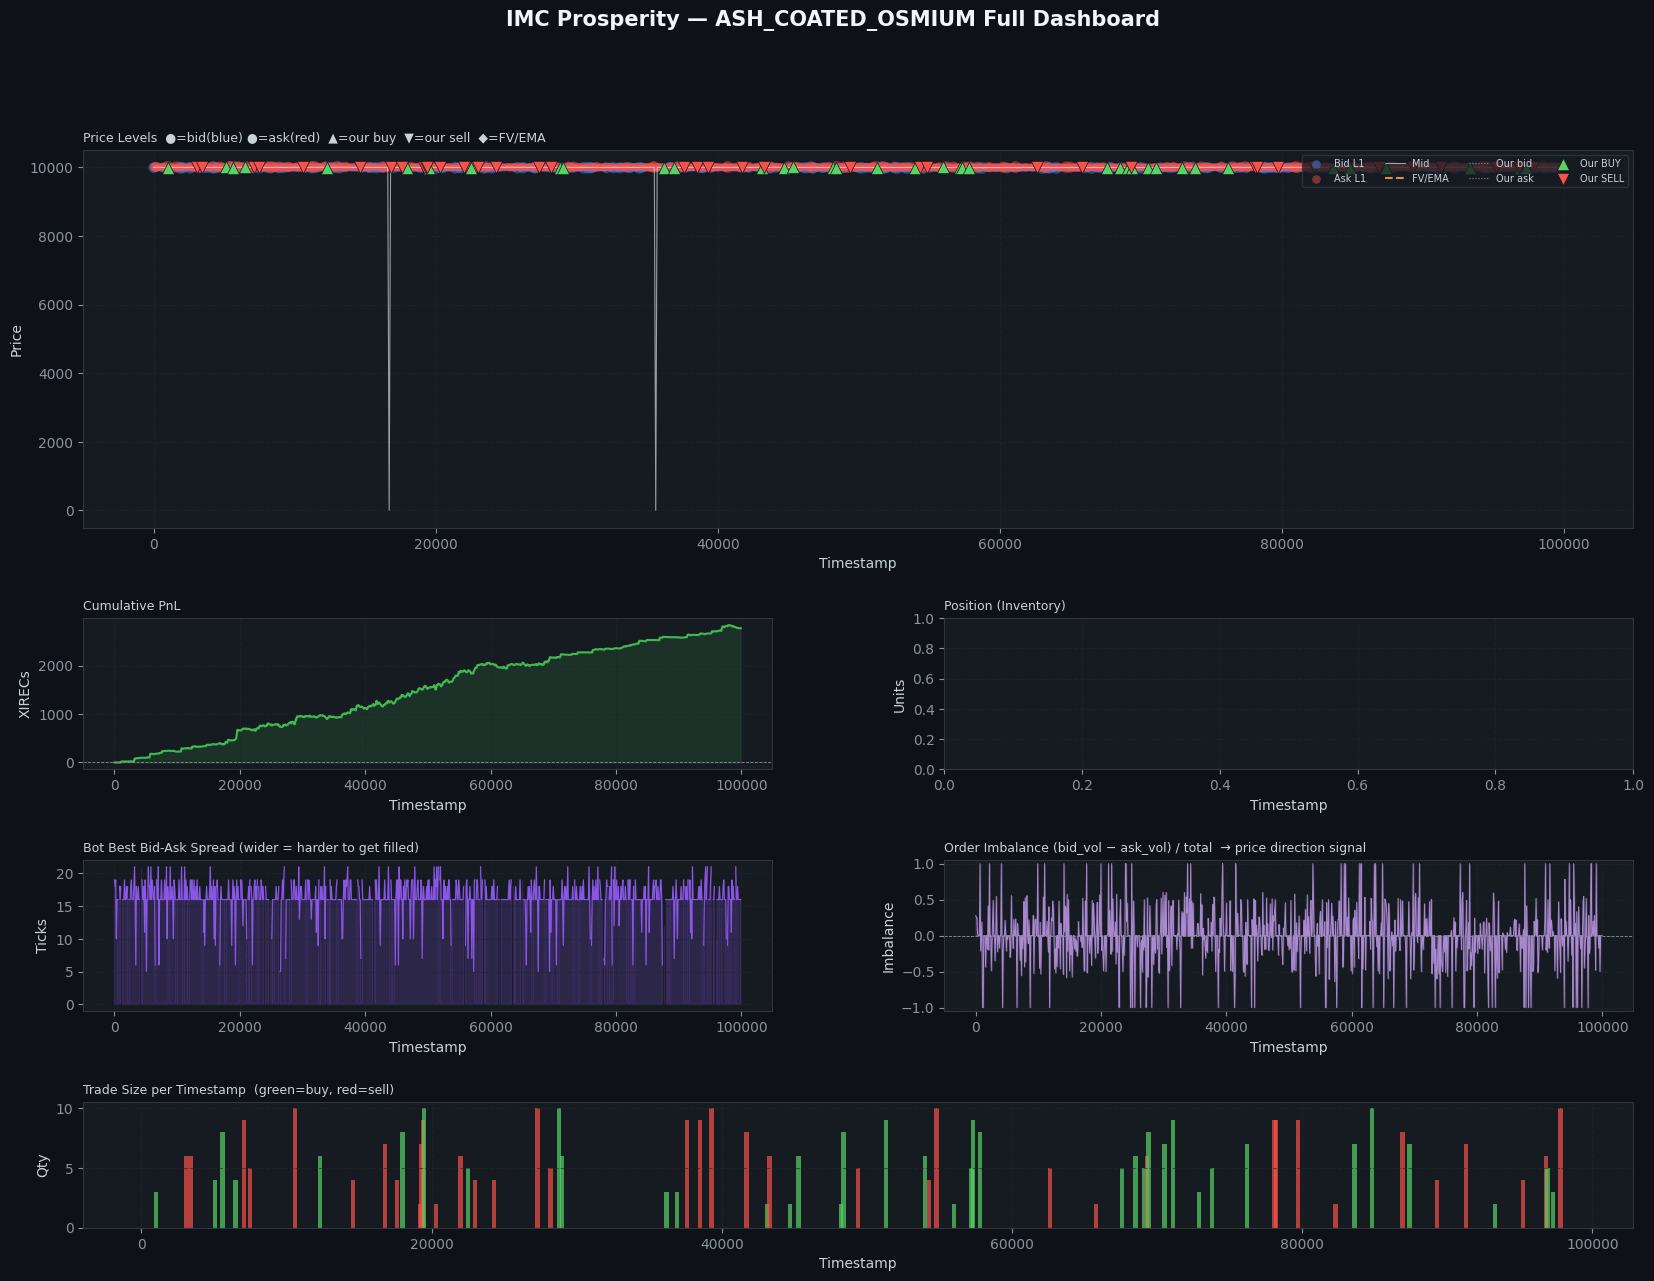

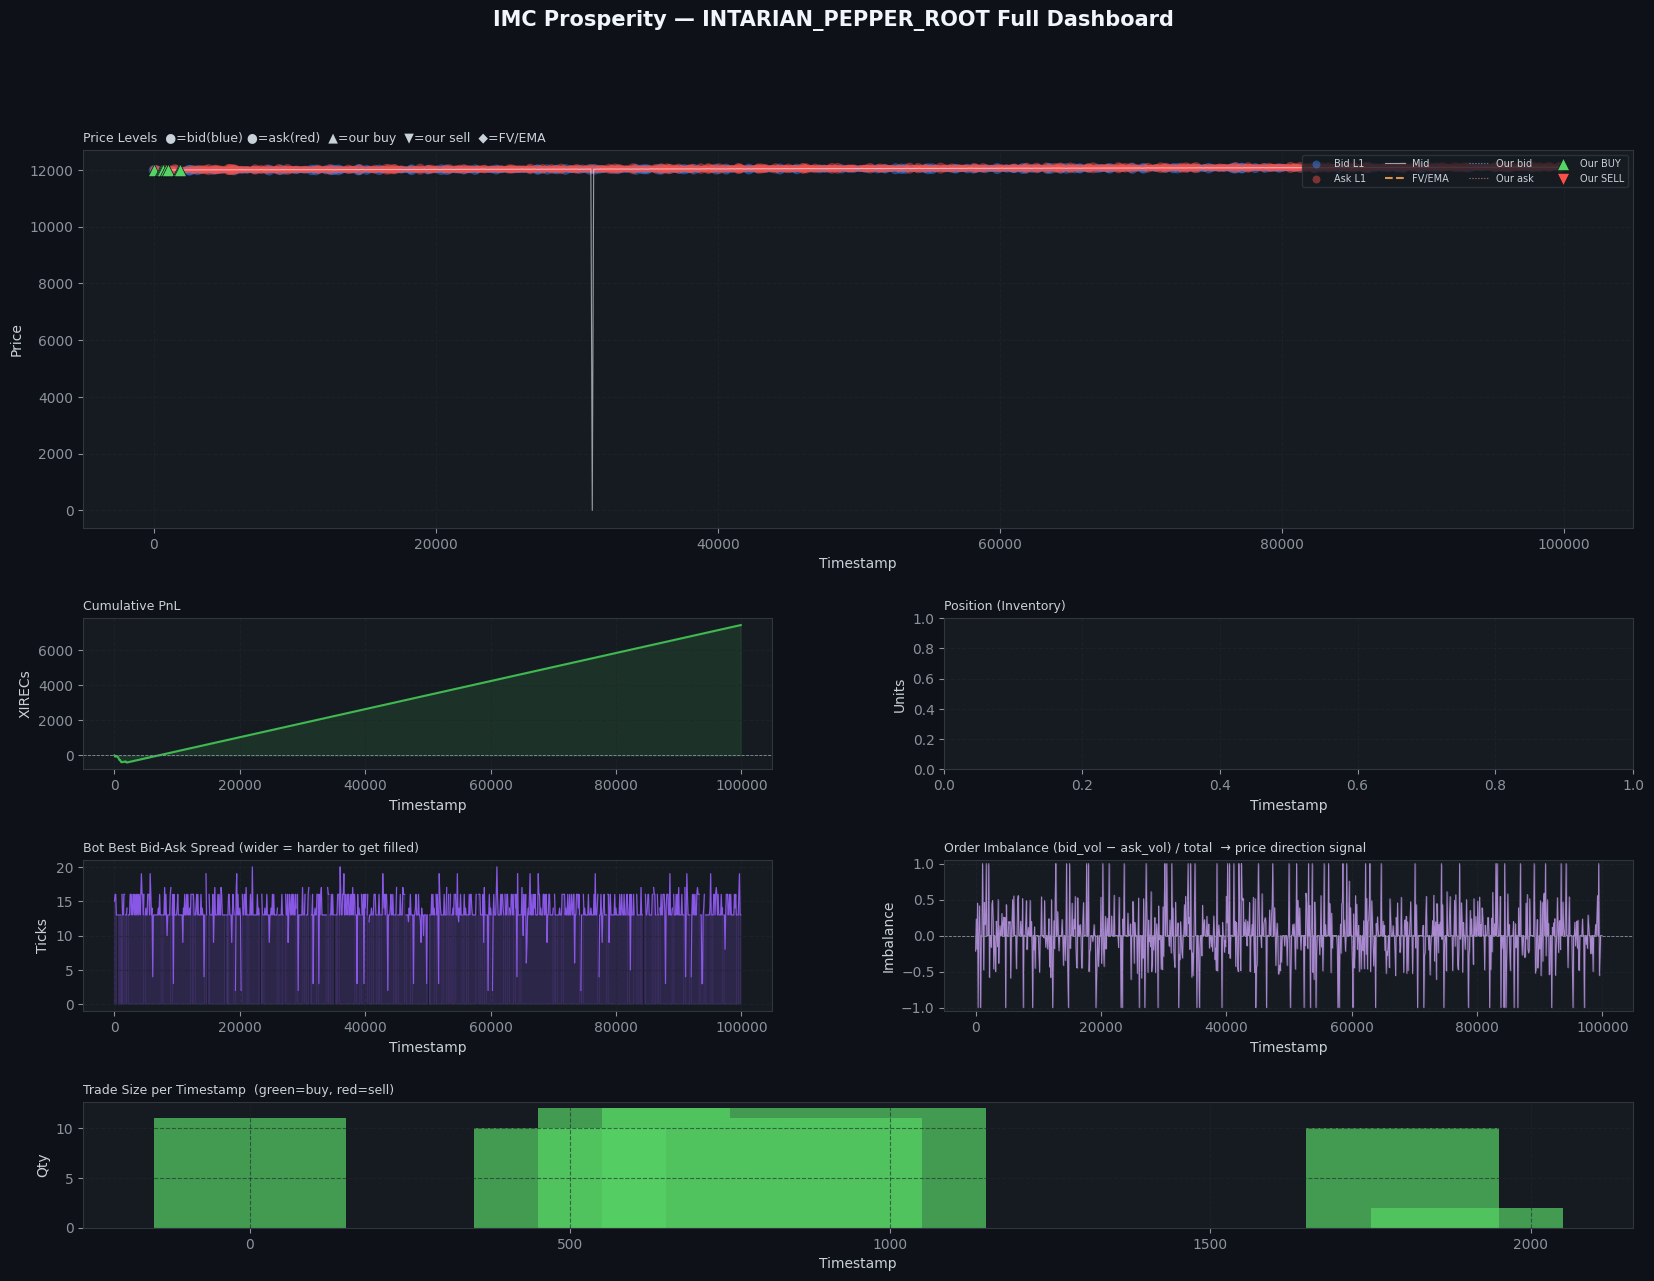

In [81]:
def full_dashboard(product: str):
    df  = mkt[product]
    pts = our_trades[our_trades['symbol'] == product] if not our_trades.empty else pd.DataFrame()

    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(f'IMC Prosperity — {product} Full Dashboard', color='#f0f6fc',
                 fontsize=15, fontweight='bold', y=0.98)
    gs  = gridspec.GridSpec(4, 2, figure=fig, height_ratios=[3, 1.2, 1.2, 1],
                            hspace=0.45, wspace=0.25)

    # ── Panel 1: Price + Order Book ──────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    ax1.set_title('Price Levels  ●=bid(blue) ●=ask(red)  ▲=our buy  ▼=our sell  ◆=FV/EMA',
                  fontsize=9, loc='left')

    # Bid scatter (size = volume)
    bv1 = df['bid_volume_1'].fillna(1).clip(1, 50)
    av1 = df['ask_volume_1'].fillna(1).clip(1, 50)
    ax1.scatter(df['timestamp'], df['bid_price_1'], s=bv1*2.5, c=C['bid'],
                alpha=0.45, label='Bid L1', zorder=2, linewidths=0)
    ax1.scatter(df['timestamp'], df['ask_price_1'], s=av1*2.5, c=C['ask'],
                alpha=0.45, label='Ask L1', zorder=2, linewidths=0)

    # Level 2 (lighter)
    for col, price_col in [('bid_price_2', C['bid']), ('ask_price_2', C['ask'])]:
        mask = df[col].notna()
        ax1.scatter(df.loc[mask, 'timestamp'], df.loc[mask, col], s=8,
                    c=price_col, alpha=0.2, zorder=1, linewidths=0)

    # Mid price line
    ax1.plot(df['timestamp'], df['mid_price'], color=C['mid'],
             lw=0.8, alpha=0.6, label='Mid')

    # FV / EMA overlay from parsed logs
    fv_col = f'{product}_fv'
    if fv_col in df.columns:
        ax1.plot(df['timestamp'], df[fv_col], color=C['ema'],
                 lw=1.5, alpha=0.85, label='FV/EMA', linestyle='--')
        # Our quoted bid/ask from logs
        bid_col = f'{product}_bid'
        ask_col = f'{product}_ask'
        if bid_col in df.columns:
            ax1.plot(df['timestamp'], df[bid_col], color='#79c0ff', lw=0.8,
                     linestyle=':', alpha=0.7, label='Our bid')
            ax1.plot(df['timestamp'], df[ask_col], color='#ffa198', lw=0.8,
                     linestyle=':', alpha=0.7, label='Our ask')

    # Our trades
    if not pts.empty:
        buys  = pts[pts['side'] == 'BUY']
        sells = pts[pts['side'] == 'SELL']
        ax1.scatter(buys['timestamp'],  buys['price'],  marker='^', s=80,
                    c=C['trade_buy'],  zorder=5, label='Our BUY',  edgecolors='#0d1117', lw=0.5)
        ax1.scatter(sells['timestamp'], sells['price'], marker='v', s=80,
                    c=C['trade_sell'], zorder=5, label='Our SELL', edgecolors='#0d1117', lw=0.5)

    ax1.legend(loc='upper right', fontsize=7, ncol=4)
    ax1.set_ylabel('Price')
    ax1.grid(True)

    # ── Panel 2: PnL ─────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(df['timestamp'], df['profit_and_loss'], color=C['pnl'], lw=1.5)
    ax2.fill_between(df['timestamp'], df['profit_and_loss'], alpha=0.15, color=C['pnl'])
    ax2.axhline(0, color='#8b949e', lw=0.6, linestyle='--')
    ax2.set_title('Cumulative PnL', fontsize=9, loc='left')
    ax2.set_ylabel('XIRECs')
    ax2.grid(True)

    # ── Panel 3: Position ─────────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    pos_col = f'{product}_pos'
    if pos_col in df.columns and df[pos_col].notna().sum() > 0:
        pos_series = df[pos_col].ffill().fillna(0)
        ax3.fill_between(df['timestamp'], pos_series, alpha=0.4,
                         color=C['pos'], step='post')
        ax3.step(df['timestamp'], pos_series, color=C['pos'], lw=1.2)
        ax3.axhline(0, color='#8b949e', lw=0.6, linestyle='--')
    ax3.set_title('Position (Inventory)', fontsize=9, loc='left')
    ax3.set_ylabel('Units')
    ax3.grid(True)

    # ── Panel 4: Spread width ─────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 0])
    ax4.plot(df['timestamp'], df['spread'], color=C['spread'], lw=0.8)
    ax4.fill_between(df['timestamp'], df['spread'], alpha=0.2, color=C['spread'])
    ax4.set_title('Bot Best Bid-Ask Spread (wider = harder to get filled)', fontsize=9, loc='left')
    ax4.set_ylabel('Ticks')
    ax4.grid(True)

    # ── Panel 5: Order imbalance ──────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.plot(df['timestamp'], df['imbalance'], color='#d2a8ff', lw=0.7, alpha=0.7)
    ax5.fill_between(df['timestamp'], df['imbalance'], alpha=0.2, color='#d2a8ff')
    ax5.axhline(0, color='#8b949e', lw=0.6, linestyle='--')
    ax5.set_title('Order Imbalance (bid_vol − ask_vol) / total  → price direction signal',
                  fontsize=9, loc='left')
    ax5.set_ylabel('Imbalance')
    ax5.set_ylim(-1.05, 1.05)
    ax5.grid(True)

    # ── Panel 6: Per-trade PnL bars ───────────────────────────────────────────
    ax6 = fig.add_subplot(gs[3, :])
    if not pts.empty:
        colors_bar = [C['trade_buy'] if s == 'BUY' else C['trade_sell'] for s in pts['side']]
        ax6.bar(pts['timestamp'], pts['quantity'], width=300, color=colors_bar, alpha=0.7)
        ax6.set_title('Trade Size per Timestamp  (green=buy, red=sell)', fontsize=9, loc='left')
        ax6.set_ylabel('Qty')
        ax6.grid(True)
    else:
        ax6.text(0.5, 0.5, 'No own trades found', ha='center', va='center',
                 transform=ax6.transAxes, fontsize=12)

    for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
        ax.set_xlabel('Timestamp')
    plt.show()

for p in products:
    full_dashboard(p)

---
## 3 — 🤖 Bot Behaviour Fingerprinting

**Goal:** Identify *which bots are quoting*, how predictable their patterns are, and whether you can exploit them.

**Key idea from top participants:**  
> "Teams could study and optimize their algorithms by analyzing bot behaviors and interactions (e.g., predictable quoting or trading patterns)"

What to look for:
- **Fixed-price bots**: A bot that *always* quotes at the same price (e.g., 9992/10008 for EMERALDS). You can always trade against them when their quote has edge.
- **Momentum bots**: Quote prices that move in the same direction as recent price change. Fade them.
- **Mean-reversion bots**: Widen spread when price deviates far from a reference. Your signal.
- **Volume-reactive bots**: Change their quote size after you fill them (adaptive market-maker). Dangerous to aggress repeatedly.
- **Scheduled refresh bots**: Bots that re-quote at specific timestamp intervals (100, 500, etc.).

In [82]:
# ─── 3a: Quote stability analysis ────────────────────────────────────────────
for p in products:
    df = mkt[p]
    print(f'\n═══ {p} — Bot Quote Stability ═══')

    # How often does the best bid/ask change?
    bid_changes = (df['bid_price_1'].diff() != 0).sum()
    ask_changes = (df['ask_price_1'].diff() != 0).sum()
    total       = len(df)
    print(f'  Best bid changes : {bid_changes}/{total} ({100*bid_changes/total:.1f}%)')
    print(f'  Best ask changes : {ask_changes}/{total} ({100*ask_changes/total:.1f}%)')

    # Most common bid/ask prices
    top_bids = df['bid_price_1'].value_counts().head(5)
    top_asks = df['ask_price_1'].value_counts().head(5)
    print(f'  Top bid prices   : {top_bids.to_dict()}')
    print(f'  Top ask prices   : {top_asks.to_dict()}')

    # Spread distribution
    print(f'  Spread stats     : mean={df["spread"].mean():.2f}  '
          f'std={df["spread"].std():.2f}  '
          f'min={df["spread"].min()}  max={df["spread"].max()}')

    # FV deviation from fixed reference (if EMERALDS)
    if p == 'EMERALDS':
        fv_dev = (df['mid_price'] - 10000).abs()
        print(f'  |mid - 10000|    : mean={fv_dev.mean():.2f}  max={fv_dev.max():.2f}')
        print(f'  → FV is ROCK SOLID at 10000. Pure market-making opportunity.')


═══ ASH_COATED_OSMIUM — Bot Quote Stability ═══
  Best bid changes : 566/1000 (56.6%)
  Best ask changes : 524/1000 (52.4%)
  Top bid prices   : {9993.0: 220, 9994.0: 130, 9992.0: 124, 9989.0: 104, 9990.0: 98}
  Top ask prices   : {10009.0: 261, 10010.0: 143, 10008.0: 113, 10005.0: 96, 10011.0: 77}
  Spread stats     : mean=16.25  std=2.70  min=5.0  max=21.0

═══ INTARIAN_PEPPER_ROOT — Bot Quote Stability ═══
  Best bid changes : 424/1000 (42.4%)
  Best ask changes : 469/1000 (46.9%)
  Top bid prices   : {12010.0: 12, 11995.0: 12, 12069.0: 12, 12011.0: 12, 12049.0: 12}
  Top ask prices   : {12056.0: 15, 12013.0: 14, 12015.0: 14, 12083.0: 13, 12051.0: 13}
  Spread stats     : mean=13.71  std=2.48  min=2.0  max=20.0


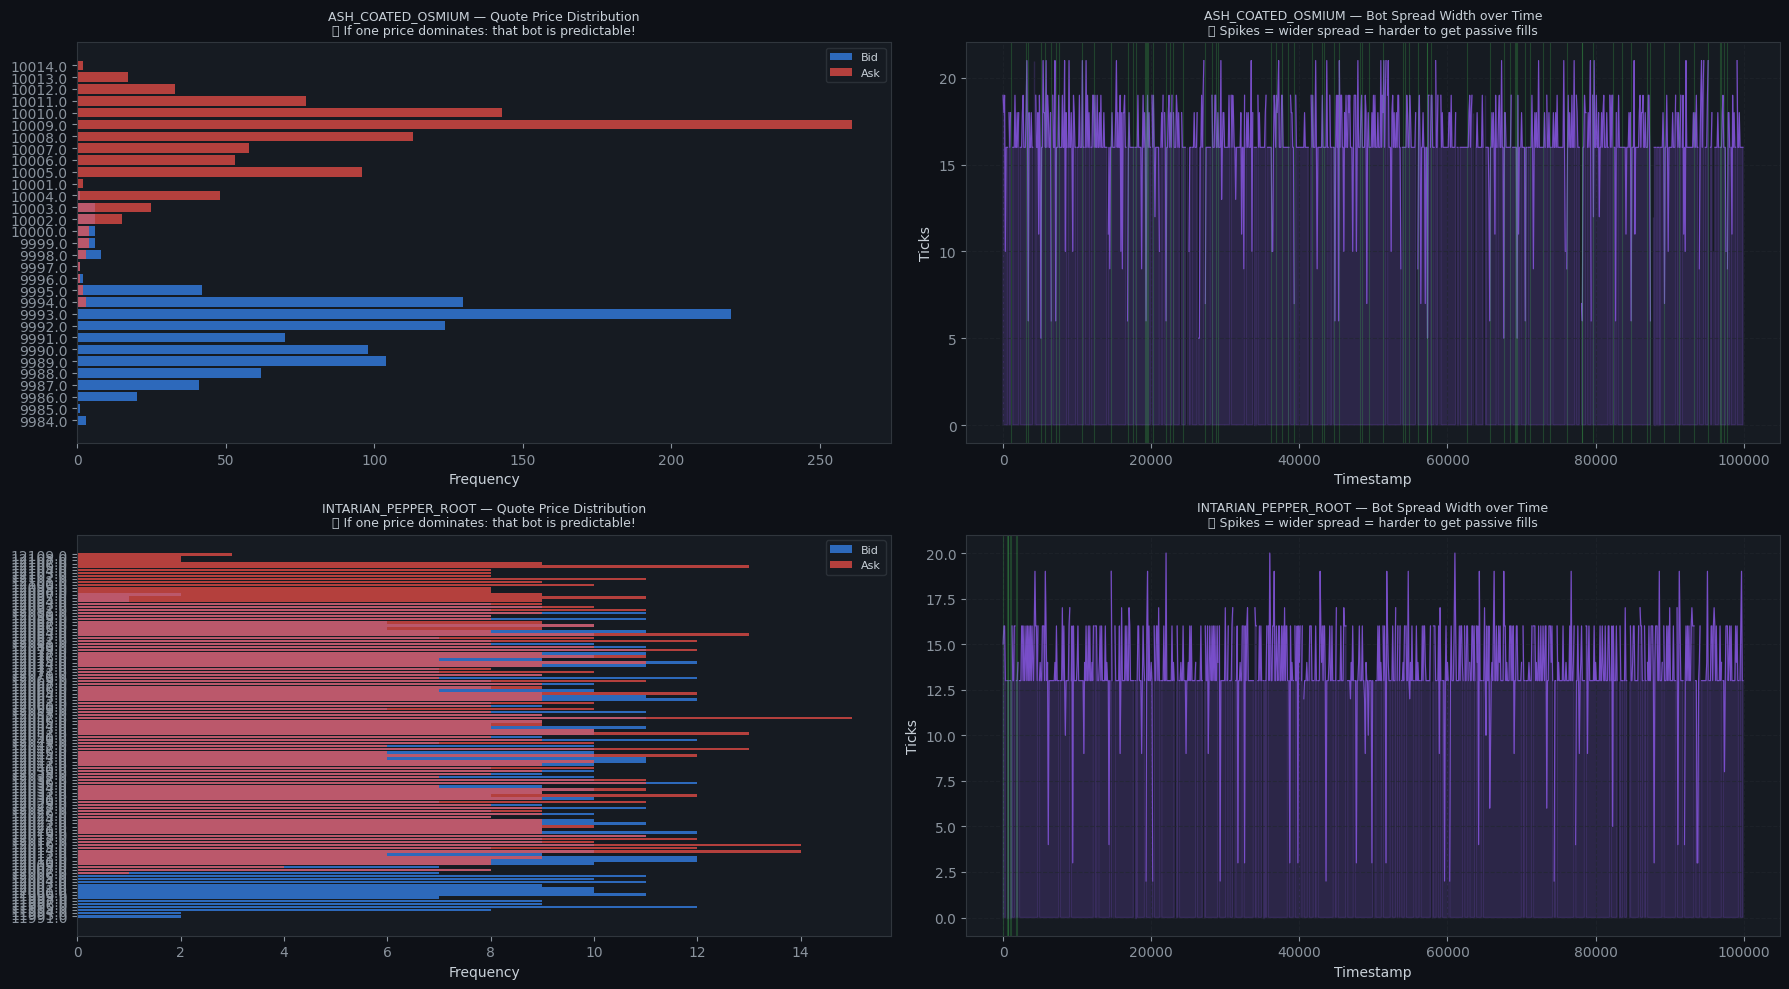

In [83]:
# ─── 3b: Bot quote pattern visualisation ─────────────────────────────────────
fig, axes = plt.subplots(len(products), 2, figsize=(18, 5*len(products)))
if len(products) == 1:
    axes = [axes]

for i, p in enumerate(products):
    df  = mkt[p]
    ax_l, ax_r = axes[i]

    # Left: bid price 1 distribution
    bid_counts = df['bid_price_1'].dropna().value_counts().sort_index()
    ask_counts = df['ask_price_1'].dropna().value_counts().sort_index()
    ax_l.barh(bid_counts.index.astype(str), bid_counts.values, color=C['bid'], alpha=0.7, label='Bid')
    ax_l.barh(ask_counts.index.astype(str), ask_counts.values, color=C['ask'], alpha=0.7, label='Ask')
    ax_l.set_title(f'{p} — Quote Price Distribution\n🔍 If one price dominates: that bot is predictable!',
                   fontsize=9)
    ax_l.legend(fontsize=8)
    ax_l.set_xlabel('Frequency')

    # Right: spread over time with fill markers
    ax_r.plot(df['timestamp'], df['spread'], color=C['spread'], lw=0.8, alpha=0.8)
    ax_r.fill_between(df['timestamp'], df['spread'], alpha=0.2, color=C['spread'])
    if not our_trades.empty:
        pts = our_trades[our_trades['symbol'] == p]
        if not pts.empty:
            ax_r.axvline(x=0, color='white', lw=0, label='dummy')
            for _, t in pts.iterrows():
                ax_r.axvline(t['timestamp'], color=C['pnl'], alpha=0.25, lw=0.8)
    ax_r.set_title(f'{p} — Bot Spread Width over Time\n🔍 Spikes = wider spread = harder to get passive fills',
                   fontsize=9)
    ax_r.set_xlabel('Timestamp')
    ax_r.set_ylabel('Ticks')
    ax_r.grid(True)

plt.tight_layout()
plt.show()

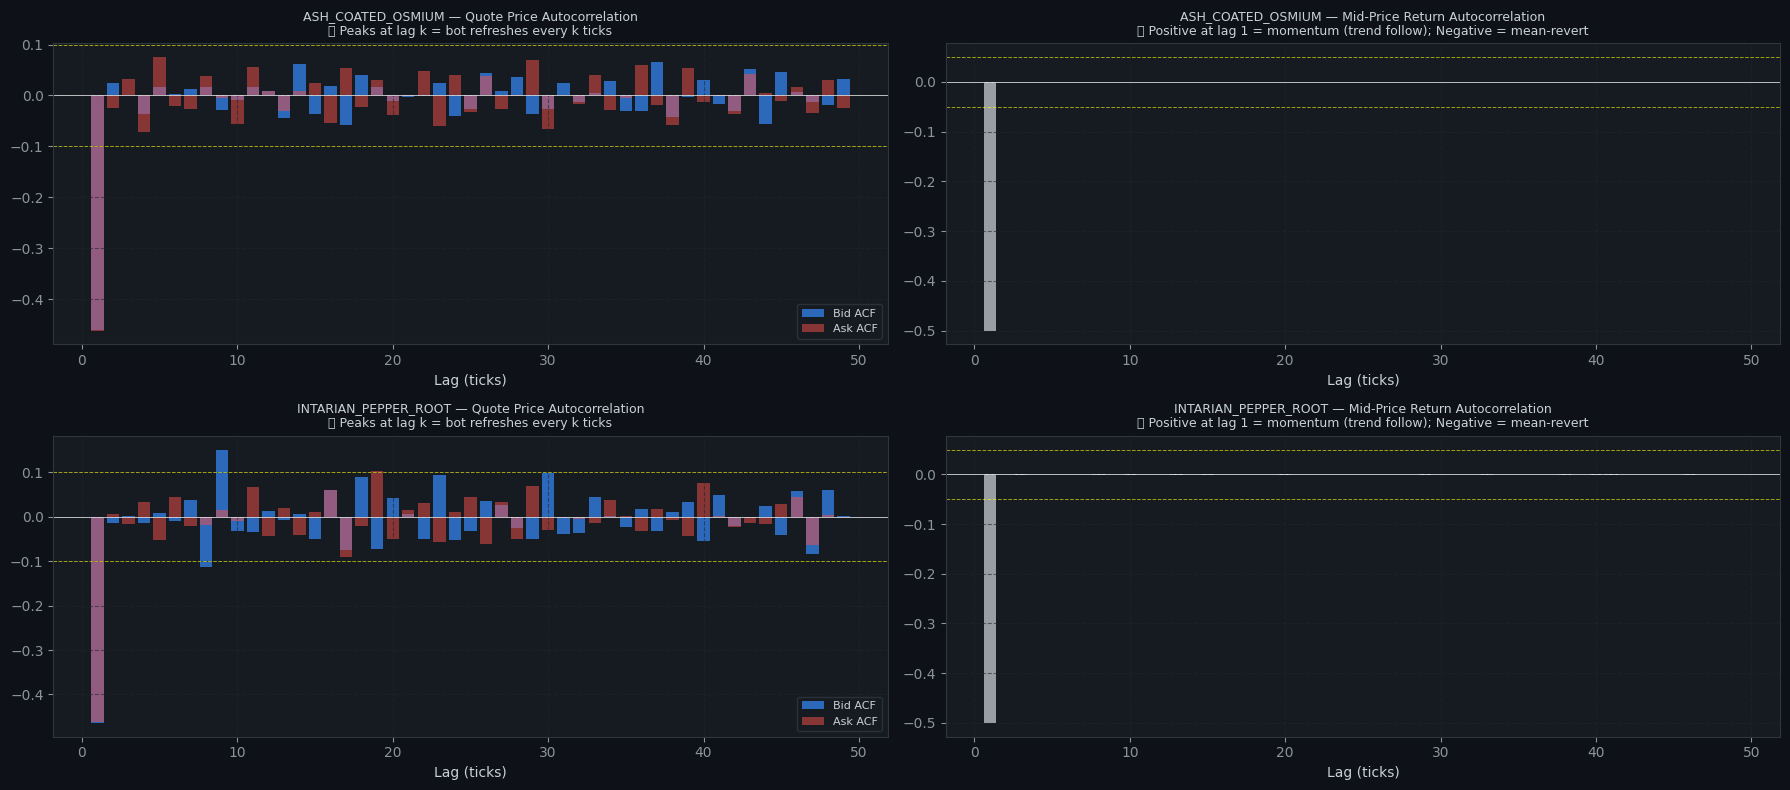

In [84]:
# ─── 3c: Lag-autocorrelation of bid/ask (detect periodic bot refresh) ─────────
fig, axes = plt.subplots(len(products), 2, figsize=(18, 4*len(products)))
if len(products) == 1:
    axes = [axes]

for i, p in enumerate(products):
    df = mkt[p]
    ax_l, ax_r = axes[i]

    bid_diff = df['bid_price_1'].diff().fillna(0)
    ask_diff = df['ask_price_1'].diff().fillna(0)
    lags = range(1, min(50, len(df)))

    bid_acf = [bid_diff.autocorr(lag=l) for l in lags]
    ask_acf = [ask_diff.autocorr(lag=l) for l in lags]
    mid_acf = [df['mid_chg'].autocorr(lag=l) for l in lags]

    ax_l.bar(lags, bid_acf, color=C['bid'], alpha=0.7, label='Bid ACF')
    ax_l.bar(lags, ask_acf, color=C['ask'], alpha=0.5, label='Ask ACF')
    ax_l.axhline(0, color='white', lw=0.5)
    ax_l.axhline( 0.1, color='yellow', lw=0.7, linestyle='--', alpha=0.6)
    ax_l.axhline(-0.1, color='yellow', lw=0.7, linestyle='--', alpha=0.6)
    ax_l.set_title(f'{p} — Quote Price Autocorrelation\n🔍 Peaks at lag k = bot refreshes every k ticks',
                   fontsize=9)
    ax_l.legend(fontsize=8)
    ax_l.set_xlabel('Lag (ticks)')

    ax_r.bar(lags, mid_acf, color=C['mid'], alpha=0.6)
    ax_r.axhline(0, color='white', lw=0.5)
    ax_r.axhline( 0.05, color='yellow', lw=0.7, linestyle='--', alpha=0.6)
    ax_r.axhline(-0.05, color='yellow', lw=0.7, linestyle='--', alpha=0.6)
    ax_r.set_title(f'{p} — Mid-Price Return Autocorrelation\n🔍 Positive at lag 1 = momentum (trend follow); Negative = mean-revert',
                   fontsize=9)
    ax_r.set_xlabel('Lag (ticks)')
    ax_r.grid(True)
    ax_l.grid(True)

plt.tight_layout()
plt.show()

---
## 4 — 📈 Price & FV Analysis

**Key questions:**
1. Is the product *stationary* (fixed FV like EMERALDS) or *trending* (drifting like TOMATOES)?
2. How well does our EMA track the true price?
3. Is there mean-reversion we can exploit?
4. Are there predictable intraday patterns?

**🔍 INSIGHT:** If the EMA lags price by many ticks, you are buying into downtrends and selling into uptrends → adverse selection → negative alpha from market-making on that side.

In [85]:
# ─── 4a: Price statistics & stationarity test ─────────────────────────────────
for p in products:
    df = mkt[p]
    print(f'\n═══ {p} — Price Statistics ═══')
    mp = df['mid_price']
    print(f'  Mean            : {mp.mean():.4f}')
    print(f'  Std             : {mp.std():.4f}')
    print(f'  Min / Max       : {mp.min()} / {mp.max()}')
    print(f'  Total range     : {mp.max() - mp.min():.2f} ticks')
    print(f'  Drift (last-first): {mp.iloc[-1] - mp.iloc[0]:+.2f}')

    # Simple mean-reversion speed (Ornstein-Uhlenbeck style)
    chg = df['mid_chg'].dropna()
    from numpy.polynomial import polynomial as P
    if len(chg) > 10:
        coeff = np.polyfit(mp.iloc[:-1].values, chg.values, 1)
        half_life = -np.log(2) / coeff[0] if coeff[0] < 0 else np.inf
        print(f'  Mean-reversion half-life: {half_life:.1f} ticks  (∞ = random walk / trend)')
        if np.isfinite(half_life) and half_life < 500:
            print(f'  → STRONG mean-reversion: consider a mean-reversion / stat-arb strategy!')
        elif np.isfinite(half_life) and half_life < 2000:
            print(f'  → MODERATE mean-reversion: current MM approach may work with wider skew')
        else:
            print(f'  → TRENDING / RANDOM WALK: EMA-based FV tracking is correct approach')

    # Rolling volatility
    df['rolv'] = df['mid_chg'].rolling(50).std()
    print(f'  Rolling vol mean: {df["rolv"].mean():.4f}  max: {df["rolv"].max():.4f}')


═══ ASH_COATED_OSMIUM — Price Statistics ═══
  Mean            : 9979.9110
  Std             : 446.9991
  Min / Max       : 0.0 / 10011.0
  Total range     : 10011.00 ticks
  Drift (last-first): +1.50
  Mean-reversion half-life: 0.7 ticks  (∞ = random walk / trend)
  → STRONG mean-reversion: consider a mean-reversion / stat-arb strategy!
  Rolling vol mean: 217.9508  max: 2020.8133

═══ INTARIAN_PEPPER_ROOT — Price Statistics ═══
  Mean            : 12037.8640
  Std             : 382.1524
  Min / Max       : 0.0 / 12105.0
  Total range     : 12105.00 ticks
  Drift (last-first): +101.00
  Mean-reversion half-life: 0.7 ticks  (∞ = random walk / trend)
  → STRONG mean-reversion: consider a mean-reversion / stat-arb strategy!
  Rolling vol mean: 132.2301  max: 2430.9874


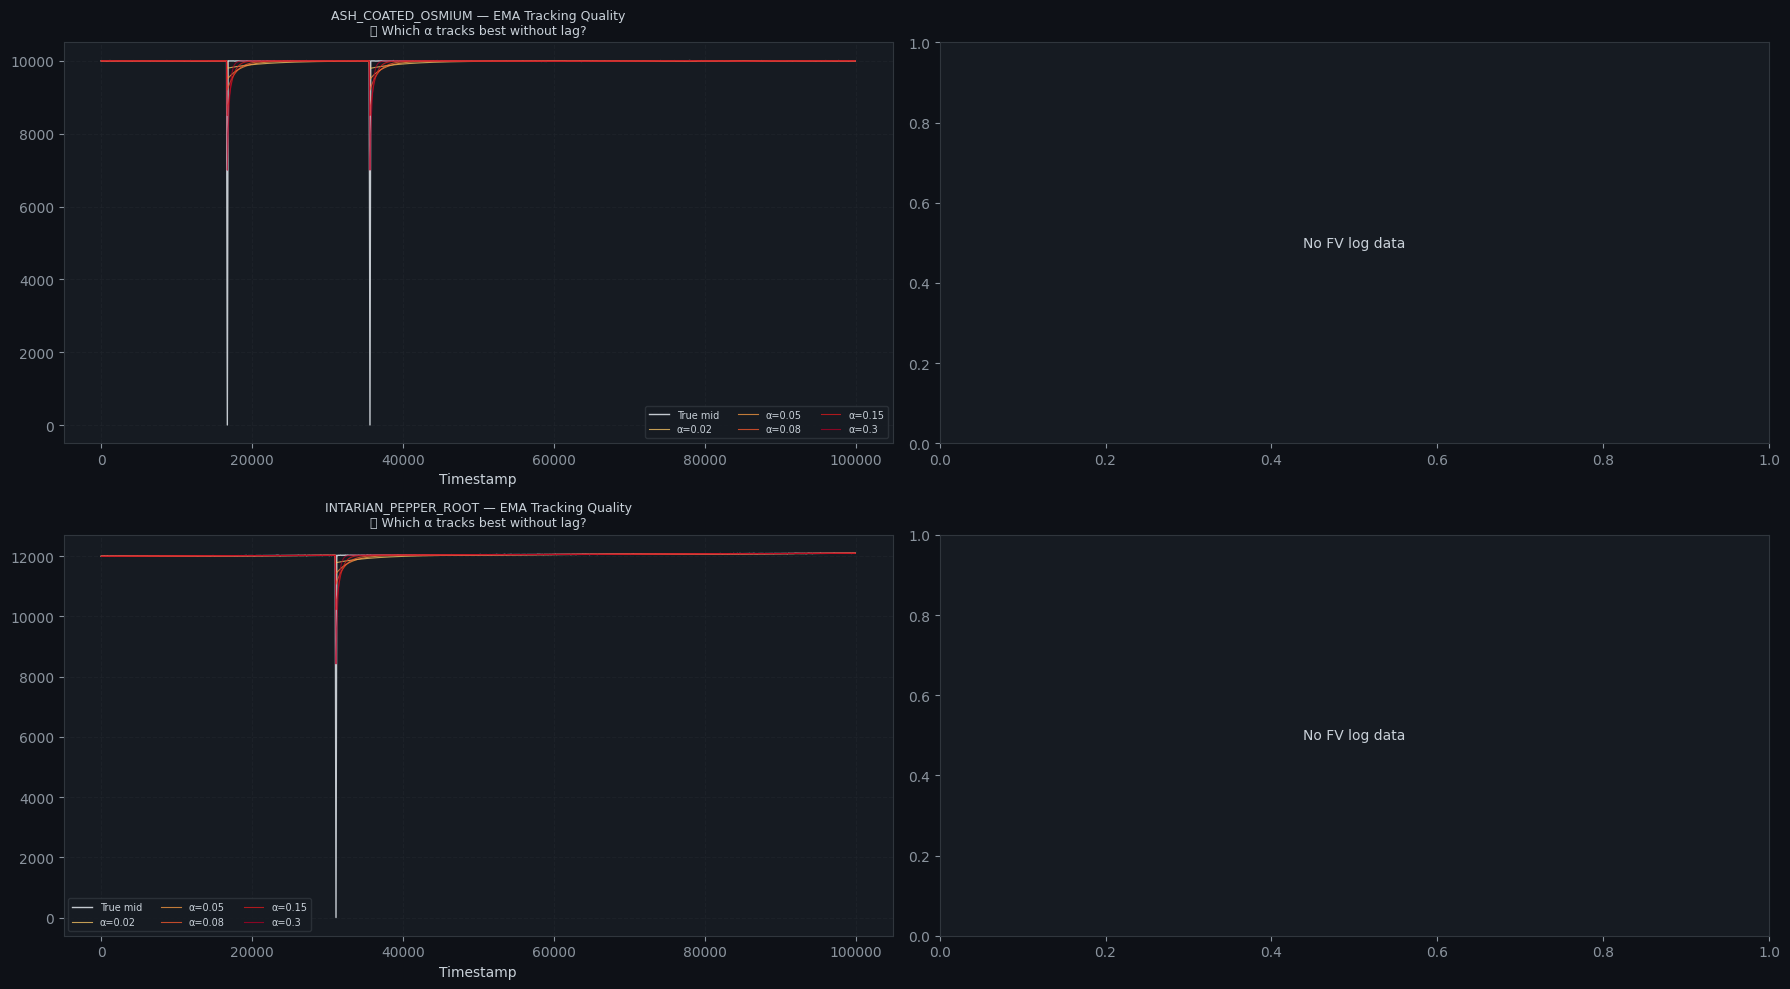

In [86]:
# ─── 4b: EMA tracking quality ─────────────────────────────────────────────────
fig, axes = plt.subplots(len(products), 2, figsize=(18, 5*len(products)))
if len(products) == 1:
    axes = [axes]

for i, p in enumerate(products):
    df   = mkt[p]
    ax_l, ax_r = axes[i]

    # Compute EMAs at various alphas
    alphas = [0.02, 0.05, 0.08, 0.15, 0.30]
    colors_alpha = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(alphas)))

    ax_l.plot(df['timestamp'], df['mid_price'], color=C['mid'], lw=1.0,
              alpha=0.8, label='True mid')

    for a, col in zip(alphas, colors_alpha):
        ema = df['mid_price'].ewm(alpha=a, adjust=False).mean()
        ax_l.plot(df['timestamp'], ema, lw=0.8, color=col, alpha=0.75,
                  label=f'α={a}')

    # Our actual EMA from logs
    fv_col = f'{p}_fv'
    if fv_col in df.columns and df[fv_col].notna().sum() > 0:
        ax_l.plot(df['timestamp'], df[fv_col], color=C['ema'], lw=1.5,
                  linestyle='--', label='Our FV/EMA', alpha=0.9)

    ax_l.set_title(f'{p} — EMA Tracking Quality\n🔍 Which α tracks best without lag?', fontsize=9)
    ax_l.legend(fontsize=7, ncol=3)
    ax_l.set_xlabel('Timestamp')
    ax_l.grid(True)

    # Right: EMA lag = FV - mid (should be close to 0)
    if fv_col in df.columns and df[fv_col].notna().sum() > 0:
        lag_err = df[fv_col] - df['mid_price']
        ax_r.plot(df['timestamp'], lag_err, color=C['ema'], lw=0.8)
        ax_r.fill_between(df['timestamp'], lag_err, alpha=0.2, color=C['ema'])
        ax_r.axhline(0, color='white', lw=0.6, linestyle='--')
        ax_r.set_title(f'{p} — Our FV Error (FV − true mid)\n'
                       f'🔍 Persistent positive error = buying high; negative = selling low (adverse selection!)',
                       fontsize=9)
        ax_r.set_xlabel('Timestamp')
        ax_r.set_ylabel('Error (ticks)')
        ax_r.grid(True)
        # Compute RMSE per alpha
        print(f'\n{p} — FV Error Stats:')
        print(f'  Mean error (bias): {lag_err.mean():+.3f}  RMSE: {np.sqrt((lag_err**2).mean()):.3f}')
        if lag_err.mean() > 2:
            print(f'  ⚠  FV is ABOVE true mid → you are over-paying to buy!')
        elif lag_err.mean() < -2:
            print(f'  ⚠  FV is BELOW true mid → you are under-selling!')
    else:
        ax_r.text(0.5, 0.5, 'No FV log data', ha='center', va='center',
                  transform=ax_r.transAxes)

plt.tight_layout()
plt.show()

---
## 5 — 💰 PnL Deep-Dive & Attribution

**What to look for:**
- **Flat PnL** → Not getting filled at all → quotes too far from market
- **PnL rises then crashes** → Position got stuck on wrong side → adverse selection, increase skew
- **PnL spiky** → Taking too much risk, too large position
- **PnL steadily rises** → Strategy is working!
- **PnL large drop at specific timestamp** → Investigate that timestamp — did price jump? Were we heavily short/long?

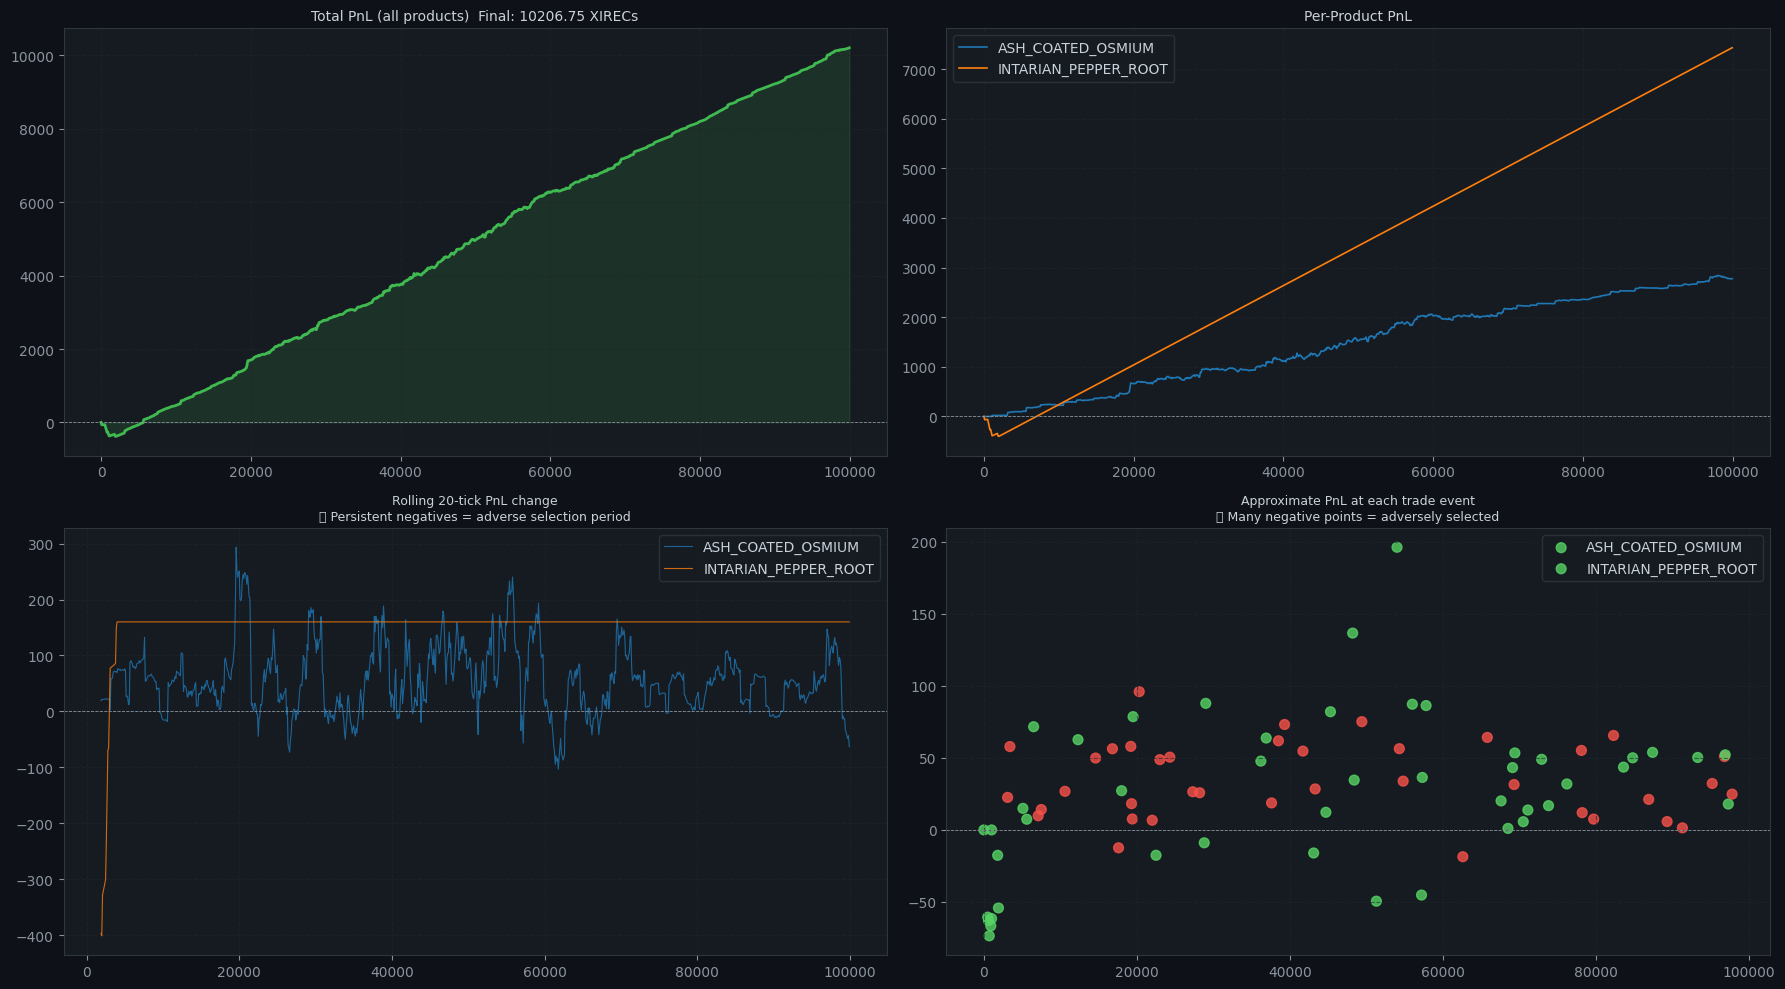

In [87]:
# ─── 5a: PnL timeline + attribution ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Total PnL
ax_total = axes[0, 0]
total_pnl_series = None
for p in products:
    df = mkt[p]
    if total_pnl_series is None:
        total_pnl_series = df.set_index('timestamp')['profit_and_loss'].reindex(
            market['timestamp'].unique()).fillna(method='ffill').fillna(0)
    else:
        series = df.set_index('timestamp')['profit_and_loss'].reindex(
            market['timestamp'].unique()).fillna(method='ffill').fillna(0)
        total_pnl_series = total_pnl_series.add(series, fill_value=0)

if total_pnl_series is not None:
    ax_total.plot(total_pnl_series.index, total_pnl_series.values,
                  color=C['pnl'], lw=2)
    ax_total.fill_between(total_pnl_series.index, total_pnl_series.values,
                          alpha=0.15, color=C['pnl'])
    ax_total.axhline(0, color='#8b949e', lw=0.6, linestyle='--')
    ax_total.set_title(f'Total PnL (all products)  Final: {total_profit:.2f} XIRECs', fontsize=10)
    ax_total.grid(True)

# Per-product PnL
ax_pp = axes[0, 1]
for p in products:
    df = mkt[p]
    ax_pp.plot(df['timestamp'], df['profit_and_loss'], lw=1.2, label=p)
ax_pp.axhline(0, color='#8b949e', lw=0.6, linestyle='--')
ax_pp.legend()
ax_pp.set_title('Per-Product PnL', fontsize=10)
ax_pp.grid(True)

# Marginal PnL per tick
ax_marg = axes[1, 0]
for p in products:
    df = mkt[p]
    ax_marg.plot(df['timestamp'], df['pnl_chg'].rolling(20).sum(),
                 lw=0.8, alpha=0.8, label=p)
ax_marg.axhline(0, color='#8b949e', lw=0.6, linestyle='--')
ax_marg.legend()
ax_marg.set_title('Rolling 20-tick PnL change\n🔍 Persistent negatives = adverse selection period',
                  fontsize=9)
ax_marg.grid(True)

# PnL per trade
ax_pt = axes[1, 1]
if not our_trades.empty:
    for p in products:
        pts = our_trades[our_trades['symbol'] == p].copy()
        df  = mkt[p]
        if not pts.empty:
            # Merge PnL at time of trade
            pnl_at_ts = df.set_index('timestamp')['profit_and_loss']
            pts['pnl_after'] = pts['timestamp'].map(pnl_at_ts)
            pts['pnl_before'] = pts['pnl_after'].shift(1).fillna(0)
            pts['trade_pnl']  = pts['pnl_after'] - pts['pnl_before']
            ax_pt.scatter(pts['timestamp'], pts['trade_pnl'],
                         c=[C['trade_buy'] if s == 'BUY' else C['trade_sell'] for s in pts['side']],
                         s=50, alpha=0.8, label=p)
ax_pt.axhline(0, color='#8b949e', lw=0.6, linestyle='--')
ax_pt.set_title('Approximate PnL at each trade event\n🔍 Many negative points = adversely selected', fontsize=9)
ax_pt.legend()
ax_pt.grid(True)

plt.tight_layout()
plt.show()

In [88]:
# ─── 5b: Fill rate analysis — are our quotes actually getting hit? ─────────────
print('═══ Fill Rate Analysis ═══')
for p in products:
    df  = mkt[p]
    pts = our_trades[our_trades['symbol'] == p] if not our_trades.empty else pd.DataFrame()
    total_ts = len(df)
    trades_ts = len(pts)
    print(f'\n{p}:')
    print(f'  Market ticks   : {total_ts}')
    print(f'  Our fills      : {trades_ts} ({100*trades_ts/total_ts:.1f}% of ticks have a fill)')
    if not pts.empty:
        total_buy_qty  = pts[pts['side']=='BUY']['quantity'].sum()
        total_sell_qty = pts[pts['side']=='SELL']['quantity'].sum()
        avg_buy_price  = (pts[pts['side']=='BUY']['price'] * pts[pts['side']=='BUY']['quantity']).sum() / (total_buy_qty+1e-9)
        avg_sell_price = (pts[pts['side']=='SELL']['price'] * pts[pts['side']=='SELL']['quantity']).sum() / (total_sell_qty+1e-9)
        print(f'  Total BUY  qty : {total_buy_qty}  avg price: {avg_buy_price:.2f}')
        print(f'  Total SELL qty : {total_sell_qty}  avg price: {avg_sell_price:.2f}')
        if total_buy_qty > 0 and total_sell_qty > 0:
            round_trip_pnl = (avg_sell_price - avg_buy_price) * min(total_buy_qty, total_sell_qty)
            print(f'  Round-trip PnL est: {round_trip_pnl:.2f}')
    fv_col = f'{p}_fv'
    bid_col = f'{p}_bid'
    ask_col = f'{p}_ask'
    if all(c in df.columns for c in [fv_col, bid_col, ask_col]):
        our_spread = (df[ask_col] - df[bid_col]).dropna()
        bot_spread = df['spread'].dropna()
        fv_vs_mid  = (df[fv_col] - df['mid_price']).dropna()
        inside_bot = ((df[bid_col] > df['bid_price_1']) | (df[ask_col] < df['ask_price_1']))
        print(f'  Our quote spread: {our_spread.mean():.2f} vs bot spread: {bot_spread.mean():.2f}')
        print(f'  Ticks inside bot spread: {inside_bot.sum()}/{total_ts} ({100*inside_bot.mean():.1f}%)')
        print(f'  FV bias vs mid: {fv_vs_mid.mean():+.3f} (>0 = we think it is worth more than market does → we buy too eagerly)')

═══ Fill Rate Analysis ═══

ASH_COATED_OSMIUM:
  Market ticks   : 1000
  Our fills      : 76 (7.6% of ticks have a fill)
  Total BUY  qty : 218  avg price: 9992.94
  Total SELL qty : 242  avg price: 10005.38
  Round-trip PnL est: 2711.98
  Our quote spread: nan vs bot spread: 16.25
  Ticks inside bot spread: 0/1000 (0.0%)
  FV bias vs mid: +nan (>0 = we think it is worth more than market does → we buy too eagerly)

INTARIAN_PEPPER_ROOT:
  Market ticks   : 1000
  Our fills      : 8 (0.8% of ticks have a fill)
  Total BUY  qty : 80  avg price: 12007.01
  Total SELL qty : 0  avg price: 0.00
  Our quote spread: nan vs bot spread: 13.71
  Ticks inside bot spread: 0/1000 (0.0%)
  FV bias vs mid: +nan (>0 = we think it is worth more than market does → we buy too eagerly)


---
## 6 — 📐 Inventory & Adverse Selection Analysis

**The most common cause of poor PnL in market-making is adverse selection:**  
You get filled on your buy order, then price goes down (or vice versa). This happens when your FV estimate lags the market.

**Key diagnostic:** After each buy-fill, does price tend to go up or down in the next N ticks? If it goes down consistently → adverse selection.

ASH_COATED_OSMIUM BUY fills: Excellent! Price rises 2.11 after fill.
INTARIAN_PEPPER_ROOT BUY fills: Excellent! Price rises 2.12 after fill.


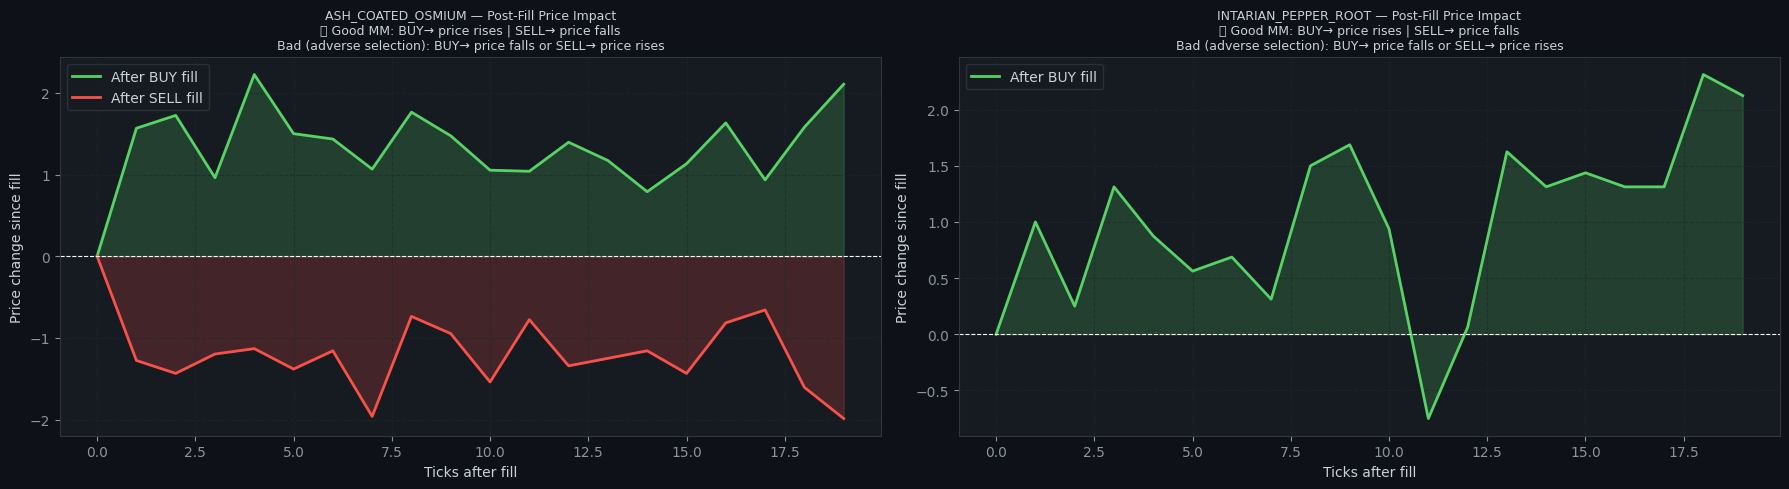

In [89]:
# ─── 6a: Post-trade price impact ──────────────────────────────────────────────
LOOKAHEAD = 20  # ticks to look forward after a fill

fig, axes = plt.subplots(1, len(products), figsize=(9*len(products), 5))
if len(products) == 1:
    axes = [axes]

for i, p in enumerate(products):
    df  = mkt[p].set_index('timestamp')
    pts = our_trades[our_trades['symbol'] == p] if not our_trades.empty else pd.DataFrame()
    ax  = axes[i]

    if pts.empty:
        ax.text(0.5, 0.5, 'No fills', ha='center', va='center', transform=ax.transAxes)
        continue

    ts_list = df.index.tolist()
    impacts_buy  = []
    impacts_sell = []

    for _, trade in pts.iterrows():
        t = trade['timestamp']
        if t not in ts_list:
            continue
        idx = ts_list.index(t)
        fill_mid = df.loc[t, 'mid_price']
        path = []
        for k in range(LOOKAHEAD):
            if idx + k < len(ts_list):
                future_mid = df.loc[ts_list[idx+k], 'mid_price']
                path.append(future_mid - fill_mid)
            else:
                path.append(np.nan)
        if trade['side'] == 'BUY':
            impacts_buy.append(path)
        else:
            impacts_sell.append(path)

    if impacts_buy:
        avg_buy_impact = np.nanmean(impacts_buy, axis=0)
        ax.plot(range(LOOKAHEAD), avg_buy_impact, color=C['trade_buy'], lw=2, label='After BUY fill')
        ax.fill_between(range(LOOKAHEAD), avg_buy_impact, alpha=0.2, color=C['trade_buy'])

    if impacts_sell:
        avg_sell_impact = np.nanmean(impacts_sell, axis=0)
        ax.plot(range(LOOKAHEAD), avg_sell_impact, color=C['trade_sell'], lw=2, label='After SELL fill')
        ax.fill_between(range(LOOKAHEAD), avg_sell_impact, alpha=0.2, color=C['trade_sell'])

    ax.axhline(0, color='white', lw=0.8, linestyle='--')
    ax.set_xlabel('Ticks after fill')
    ax.set_ylabel('Price change since fill')
    ax.set_title(f'{p} — Post-Fill Price Impact\n'
                 f'🔍 Good MM: BUY→ price rises | SELL→ price falls\n'
                 f'Bad (adverse selection): BUY→ price falls or SELL→ price rises',
                 fontsize=9)
    ax.legend()
    ax.grid(True)

    # Print conclusion
    if impacts_buy:
        final_buy_impact = avg_buy_impact[-1] if not np.isnan(avg_buy_impact[-1]) else 0
        if final_buy_impact < -0.5:
            print(f'{p} BUY fills: ADVERSE SELECTION detected! Price drops {final_buy_impact:.2f} after fill. '
                  f'→ FV is overestimating true value. Increase EMA alpha OR widen passive edge.')
        elif final_buy_impact > 0.5:
            print(f'{p} BUY fills: Excellent! Price rises {final_buy_impact:.2f} after fill.')
        else:
            print(f'{p} BUY fills: Neutral impact {final_buy_impact:.2f}')

plt.tight_layout()
plt.show()

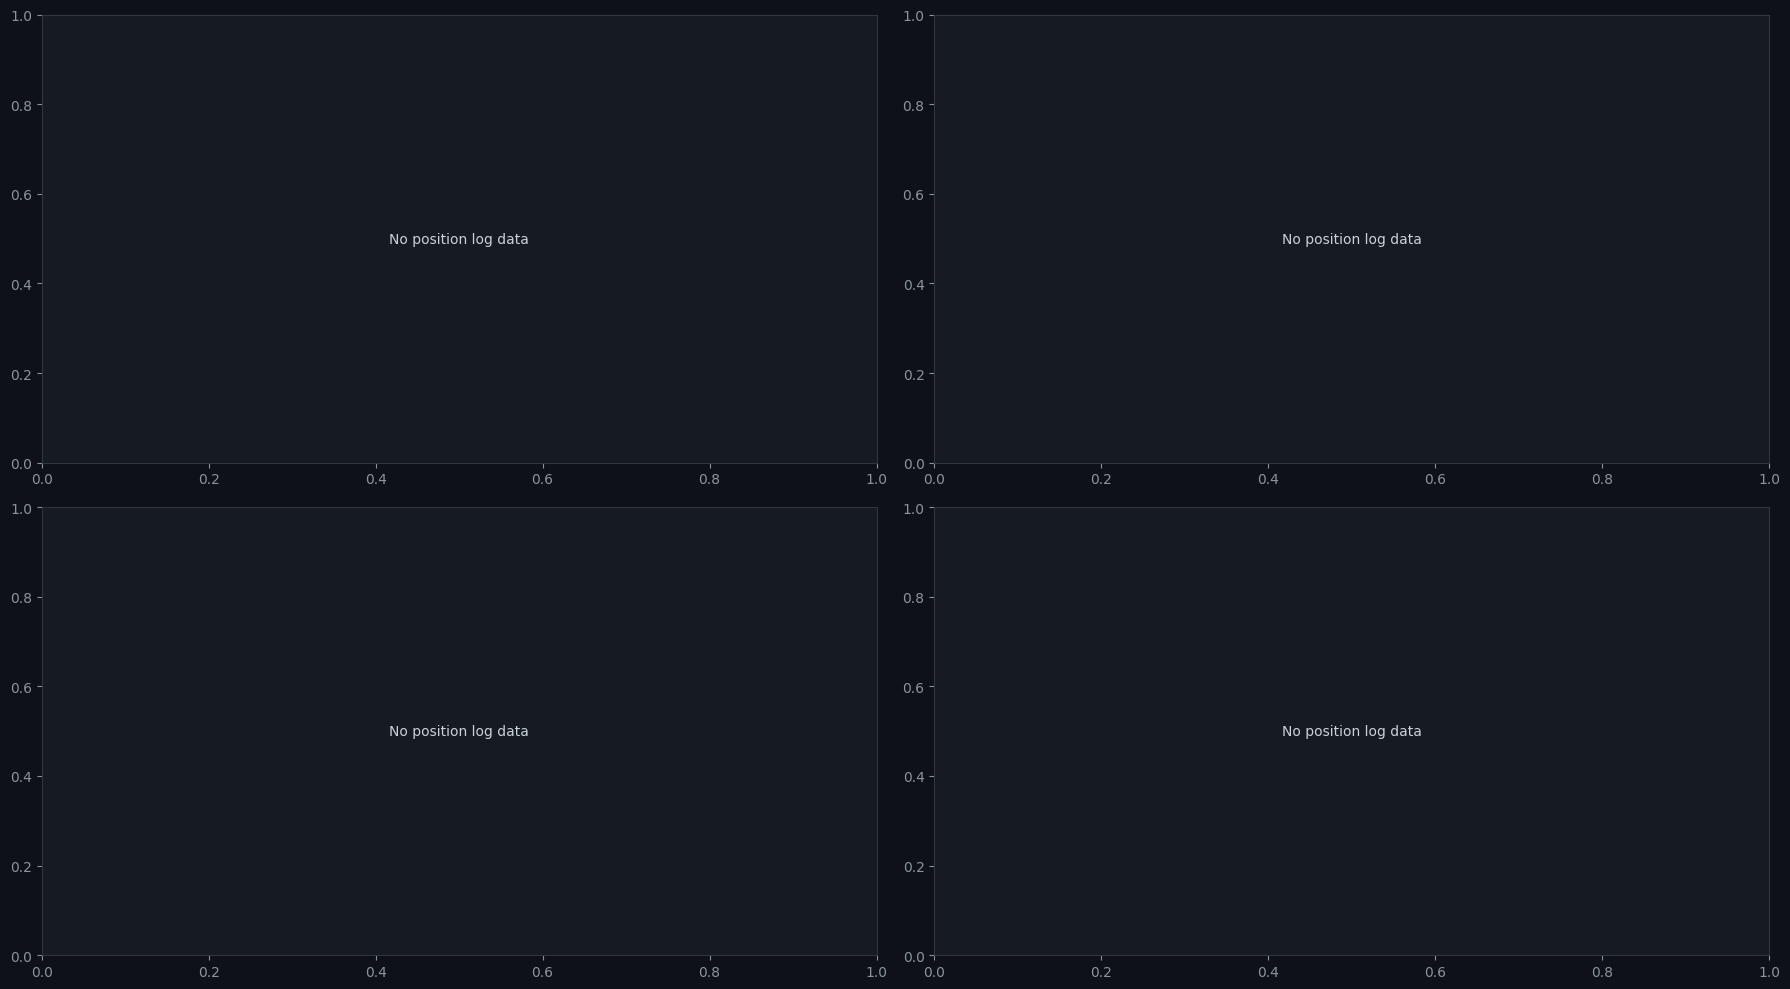

In [90]:
# ─── 6b: Inventory accumulation vs PnL ───────────────────────────────────────
fig, axes = plt.subplots(len(products), 2, figsize=(18, 5*len(products)))
if len(products) == 1:
    axes = [axes]

for i, p in enumerate(products):
    df  = mkt[p]
    ax_l, ax_r = axes[i]
    pos_col = f'{p}_pos'

    if pos_col in df.columns and df[pos_col].notna().sum() > 0:
        pos = df[pos_col].ffill().fillna(0)
        pnl = df['profit_and_loss']

        # Inventory path
        ax_l.plot(df['timestamp'], pos, color=C['pos'], lw=1.2)
        ax_l.fill_between(df['timestamp'], pos, alpha=0.2, color=C['pos'])
        ax_l.axhline(0,  color='white', lw=0.5, linestyle='--')
        ax_l.axhline( 80, color='#f85149', lw=0.8, linestyle=':', label='+limit')
        ax_l.axhline(-80, color='#f85149', lw=0.8, linestyle=':', label='-limit')
        ax_l.set_title(f'{p} — Inventory over Time\n🔍 Hitting limits = cannot trade, losing edge', fontsize=9)
        ax_l.legend(fontsize=7)
        ax_l.grid(True)

        # Inventory vs PnL scatter
        sc = ax_r.scatter(pos, pnl, c=df['timestamp'], cmap='plasma', s=5, alpha=0.6)
        plt.colorbar(sc, ax=ax_r, label='Timestamp')
        ax_r.axvline(0, color='white', lw=0.5, linestyle='--')
        ax_r.set_xlabel('Inventory (position)')
        ax_r.set_ylabel('Cumulative PnL')
        ax_r.set_title(f'{p} — Position vs PnL\n🔍 If PnL falls when |position| is large → inventory risk is killing you', fontsize=9)
        ax_r.grid(True)

        # Compute correlation
        corr = np.corrcoef(pos.fillna(0), pnl.fillna(0))[0,1]
        print(f'{p}: Position–PnL correlation = {corr:.3f}')
        if corr < -0.3:
            print(f'  ⚠  Negative correlation: large positions hurt PnL → increase skew/soft limit!')
    else:
        ax_l.text(0.5, 0.5, 'No position log data', ha='center', va='center', transform=ax_l.transAxes)
        ax_r.text(0.5, 0.5, 'No position log data', ha='center', va='center', transform=ax_r.transAxes)

plt.tight_layout()
plt.show()

---
## 7 — 🧮 Quote Placement & Edge Analysis

**This section answers: Are our quotes placed correctly?**

For each timestamp:
- Are we inside the bot spread? (Good — we should get filled)
- What is the edge of our passive quotes vs the bot best bid/ask?
- Is our edge consistent or does it collapse?

**🔍 CRITICAL INSIGHT for this algorithm:**
> The TOMATOES EMA starts at ~5006 when the true market is at 4999/5013.  
> Our bid = EMA − 4 = 5002, which is **above** the bot bid at 4999.  
> This means bots can sell to us at 5002 while the market price is at 4999 → immediate adverse selection.

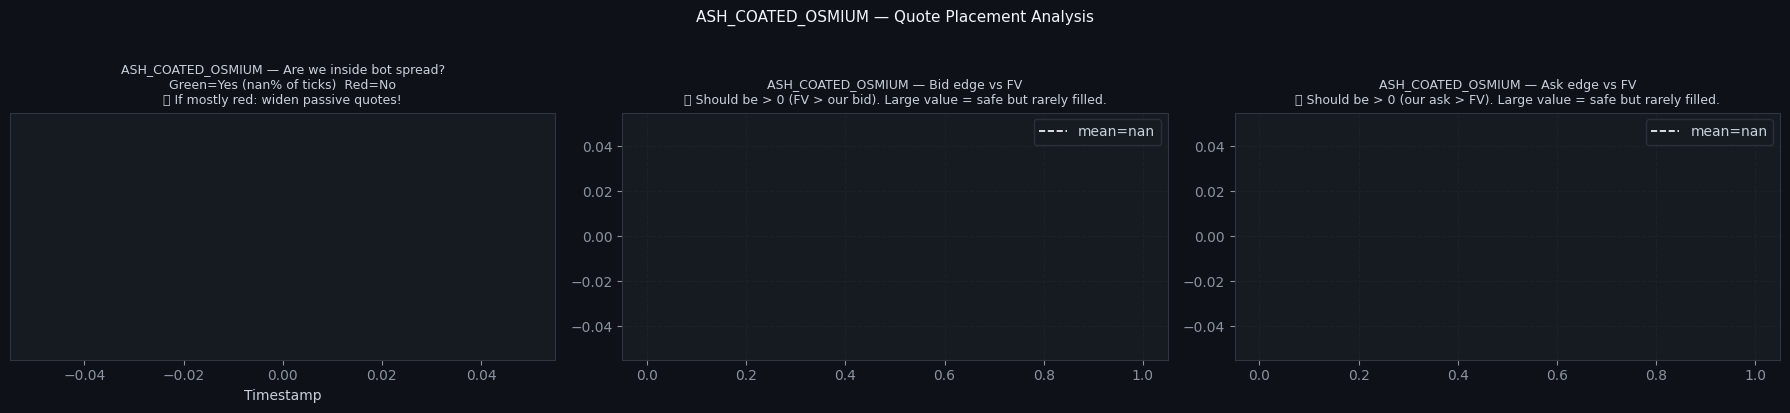


ASH_COATED_OSMIUM Quote Placement:
  % ticks inside bot spread : nan%
  Our avg spread            : nan
  Bot avg spread            : nan
  Mean bid edge vs FV       : nan
  Mean ask edge vs FV       : nan


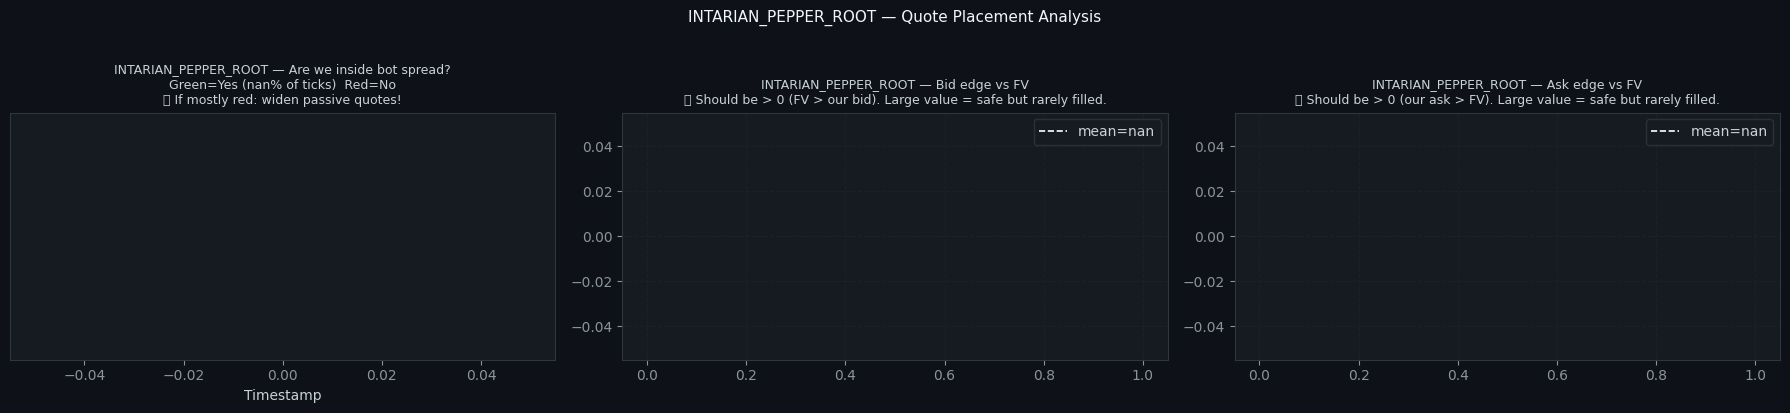


INTARIAN_PEPPER_ROOT Quote Placement:
  % ticks inside bot spread : nan%
  Our avg spread            : nan
  Bot avg spread            : nan
  Mean bid edge vs FV       : nan
  Mean ask edge vs FV       : nan


In [91]:
# ─── 7a: Quote placement vs bot spread ───────────────────────────────────────
for p in products:
    df = mkt[p]
    bid_col = f'{p}_bid'
    ask_col = f'{p}_ask'
    fv_col  = f'{p}_fv'

    if not all(c in df.columns for c in [bid_col, ask_col]):
        print(f'{p}: No quote data in logs, skipping')
        continue

    df2 = df.dropna(subset=[bid_col, ask_col])

    our_inside_bid = df2[bid_col] > df2['bid_price_1']   # our bid is better
    our_inside_ask = df2[ask_col] < df2['ask_price_1']   # our ask is better
    our_inside     = our_inside_bid | our_inside_ask

    bid_edge_vs_fv = df2[fv_col] - df2[bid_col]
    ask_edge_vs_fv = df2[ask_col] - df2[fv_col]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Inside spread heatmap
    c_map = [C['pnl'] if v else '#f85149' for v in our_inside]
    axes[0].scatter(df2['timestamp'], [1]*len(df2), c=c_map, s=3, marker='|')
    axes[0].set_title(f'{p} — Are we inside bot spread?\n'
                      f'Green=Yes ({100*our_inside.mean():.0f}% of ticks)  Red=No\n'
                      f'🔍 If mostly red: widen passive quotes!', fontsize=9)
    axes[0].set_yticks([])
    axes[0].set_xlabel('Timestamp')

    # Bid edge distribution
    axes[1].hist(bid_edge_vs_fv.dropna(), bins=40, color=C['bid'], alpha=0.7)
    axes[1].axvline(bid_edge_vs_fv.mean(), color='white', linestyle='--', lw=1.2,
                    label=f'mean={bid_edge_vs_fv.mean():.2f}')
    axes[1].set_title(f'{p} — Bid edge vs FV\n🔍 Should be > 0 (FV > our bid). Large value = safe but rarely filled.',
                      fontsize=9)
    axes[1].legend()
    axes[1].grid(True)

    # Ask edge distribution
    axes[2].hist(ask_edge_vs_fv.dropna(), bins=40, color=C['ask'], alpha=0.7)
    axes[2].axvline(ask_edge_vs_fv.mean(), color='white', linestyle='--', lw=1.2,
                    label=f'mean={ask_edge_vs_fv.mean():.2f}')
    axes[2].set_title(f'{p} — Ask edge vs FV\n🔍 Should be > 0 (our ask > FV). Large value = safe but rarely filled.',
                      fontsize=9)
    axes[2].legend()
    axes[2].grid(True)

    plt.suptitle(f'{p} — Quote Placement Analysis', color='#f0f6fc', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

    # Summary
    print(f'\n{p} Quote Placement:')
    print(f'  % ticks inside bot spread : {100*our_inside.mean():.1f}%')
    print(f'  Our avg spread            : {(df2[ask_col]-df2[bid_col]).mean():.2f}')
    print(f'  Bot avg spread            : {df2["spread"].mean():.2f}')
    print(f'  Mean bid edge vs FV       : {bid_edge_vs_fv.mean():.2f}')
    print(f'  Mean ask edge vs FV       : {ask_edge_vs_fv.mean():.2f}')

---
## 8 — 🔬 Statistical Alpha Mining

**Ideas from top participants:**
1. **Order imbalance as a directional signal** — if bid_vol >> ask_vol, price tends to rise
2. **Spread widening signal** — when bots suddenly widen spread, a price move is coming
3. **Level-2 queue depth** — large L2 vol suggests strong support/resistance
4. **Price velocity** — rate of price change predicts short-term direction
5. **Volume-weighted price vs arithmetic mid** — divergence signals imbalance


ASH_COATED_OSMIUM — Signal Information Coefficients (IC = rank correlation with next return):
  imb_lag1            : IC = +0.0085 
  spread_lag1         : IC = -0.0221 
  wm_vs_arith         : IC = +0.4354 ⭐
  price_vel           : IC = -0.0070 

INTARIAN_PEPPER_ROOT — Signal Information Coefficients (IC = rank correlation with next return):
  imb_lag1            : IC = +0.0414 
  spread_lag1         : IC = -0.0227 
  wm_vs_arith         : IC = +0.4588 ⭐
  price_vel           : IC = +0.0445 


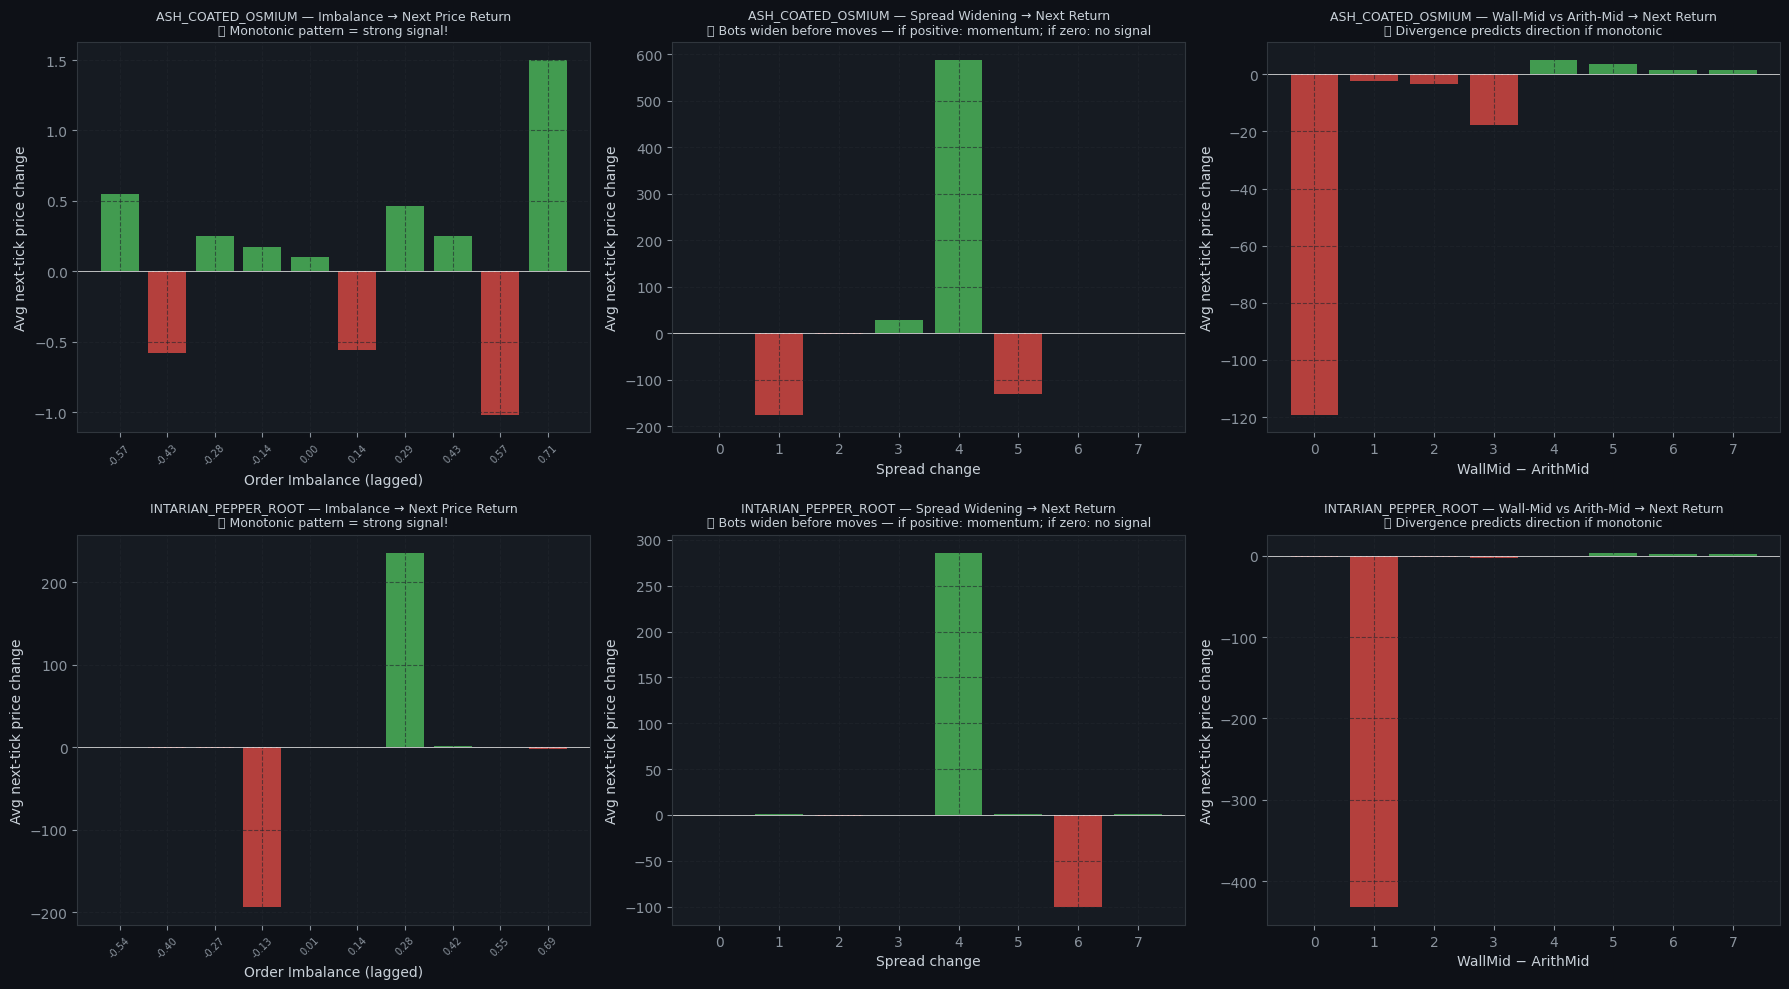

In [92]:
# ─── 8a: Order imbalance predictive power ─────────────────────────────────────
fig, axes = plt.subplots(len(products), 3, figsize=(18, 5*len(products)))
if len(products) == 1:
    axes = [axes]

for i, p in enumerate(products):
    df = mkt[p].copy()

    # Signals
    df['imb_lag1']      = df['imbalance'].shift(1)
    df['spread_lag1']   = df['spread'].shift(1)
    df['wm_vs_arith']   = df['wall_mid'] - df['arith_mid']
    df['price_vel']     = df['mid_chg'].rolling(3).mean().shift(1)
    df['next_ret']      = df['mid_chg'].shift(-1)

    df2 = df.dropna(subset=['imb_lag1', 'spread_lag1', 'next_ret'])

    # Imbalance vs next return
    ax = axes[i][0]
    bins = pd.cut(df2['imb_lag1'], bins=10)
    grouped = df2.groupby(bins)['next_ret'].mean()
    colors_bar = [C['trade_buy'] if v > 0 else C['trade_sell'] for v in grouped.values]
    ax.bar(range(len(grouped)), grouped.values, color=colors_bar, alpha=0.7)
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([f'{b.mid:.2f}' for b in grouped.index], rotation=45, fontsize=7)
    ax.axhline(0, color='white', lw=0.5)
    ax.set_title(f'{p} — Imbalance → Next Price Return\n🔍 Monotonic pattern = strong signal!', fontsize=9)
    ax.set_xlabel('Order Imbalance (lagged)')
    ax.set_ylabel('Avg next-tick price change')
    ax.grid(True)

    # Spread change vs next return
    ax = axes[i][1]
    df2['spread_chg'] = df2['spread'].diff().shift(1)
    bins2 = pd.cut(df2['spread_chg'].dropna().clip(-5, 5), bins=8)
    df3   = df2.dropna(subset=['spread_chg'])
    grouped2 = df3.groupby(pd.cut(df3['spread_chg'].clip(-5, 5), bins=8))['next_ret'].mean()
    ax.bar(range(len(grouped2)), grouped2.values,
           color=[C['trade_buy'] if v > 0 else C['trade_sell'] for v in grouped2.values], alpha=0.7)
    ax.axhline(0, color='white', lw=0.5)
    ax.set_title(f'{p} — Spread Widening → Next Return\n🔍 Bots widen before moves — if positive: momentum; if zero: no signal', fontsize=9)
    ax.set_xlabel('Spread change')
    ax.set_ylabel('Avg next-tick price change')
    ax.grid(True)

    # Wall-mid divergence
    ax = axes[i][2]
    wm_div = df2['wm_vs_arith']
    bins3   = pd.cut(wm_div.clip(wm_div.quantile(0.05), wm_div.quantile(0.95)), bins=8)
    grouped3 = df2.groupby(bins3)['next_ret'].mean()
    ax.bar(range(len(grouped3)), grouped3.values,
           color=[C['trade_buy'] if v > 0 else C['trade_sell'] for v in grouped3.values], alpha=0.7)
    ax.axhline(0, color='white', lw=0.5)
    ax.set_title(f'{p} — Wall-Mid vs Arith-Mid → Next Return\n🔍 Divergence predicts direction if monotonic', fontsize=9)
    ax.set_xlabel('WallMid − ArithMid')
    ax.set_ylabel('Avg next-tick price change')
    ax.grid(True)

    # Print IC (information coefficient)
    print(f'\n{p} — Signal Information Coefficients (IC = rank correlation with next return):')
    for sig in ['imb_lag1', 'spread_lag1', 'wm_vs_arith', 'price_vel']:
        if sig in df2.columns:
            ic = df2[sig].corr(df2['next_ret'], method='spearman')
            significance = '⭐' if abs(ic) > 0.05 else ''
            print(f'  {sig:20s}: IC = {ic:+.4f} {significance}')

plt.tight_layout()
plt.show()

In [93]:
# ─── 8b: Regression: can we predict next price move? ──────────────────────────
print('\n═══ Predictive Regression Analysis ═══')
for p in products:
    df = mkt[p].copy()
    df['next_ret'] = df['mid_chg'].shift(-1)
    df['imb1']     = df['imbalance']
    df['spread_z'] = (df['spread'] - df['spread'].rolling(50).mean()) / (df['spread'].rolling(50).std() + 1e-9)
    df['vel']      = df['mid_chg'].rolling(5).mean()
    df['wm_arith'] = df['wall_mid'] - df['arith_mid']
    df2 = df.dropna(subset=['next_ret', 'imb1', 'spread_z', 'vel', 'wm_arith']).copy()

    if len(df2) < 50:
        continue

    X = df2[['imb1', 'spread_z', 'vel', 'wm_arith']].values
    y = df2['next_ret'].values
    X  = np.column_stack([np.ones(len(X)), X])
    coeffs = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat  = X @ coeffs
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else 0

    print(f'\n{p} — OLS regression: next_ret ~ imbalance + spread_z + velocity + wall_mid_divergence')
    print(f'  R² = {r2:.4f}  (higher = more predictable price)')
    print(f'  Coefficients: intercept={coeffs[0]:.4f}, imb={coeffs[1]:.4f}, '
          f'spread_z={coeffs[2]:.4f}, vel={coeffs[3]:.4f}, wm_arith={coeffs[4]:.4f}')
    if r2 > 0.01:
        print(f'  → R²>1%: There IS predictive signal here! Use it to adjust your FV dynamically.')
    else:
        print(f'  → Very low R²: Price is mostly unpredictable tick-by-tick. Passive MM is correct.')


═══ Predictive Regression Analysis ═══


---
## 9 — 🎯 Strategy Parameter Sensitivity

**Vectorized backtest:** Fast simulation to optimize passive edge, EMA alpha, and skew factor.
This is the technique top participants use for rapid parameter exploration before full backtesting.

**Warning on overfitting:** Don't over-tune to this specific dataset. The bot randomness changes between submissions. Focus on finding robust ranges, not precise single values.

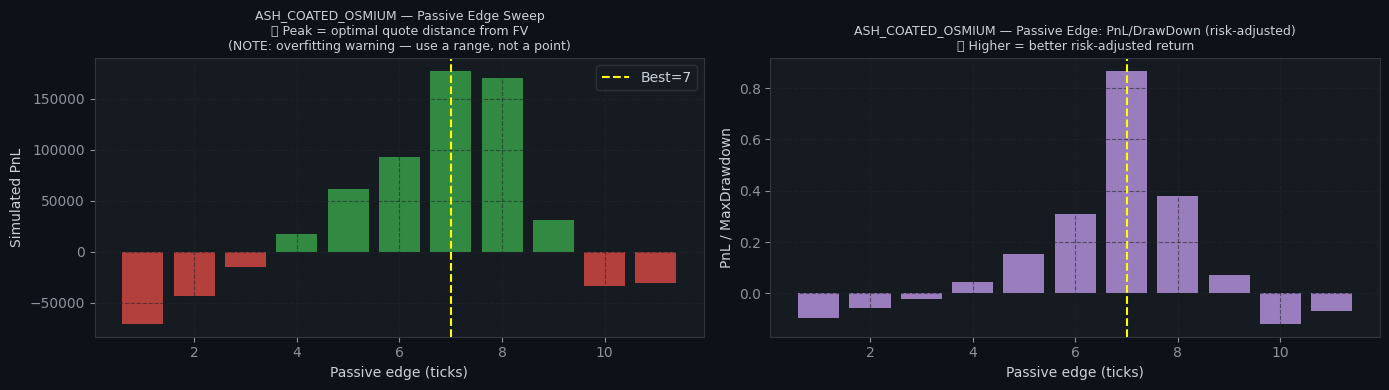

ASH_COATED_OSMIUM: Best passive edge = 7, sim PnL = 177002.00


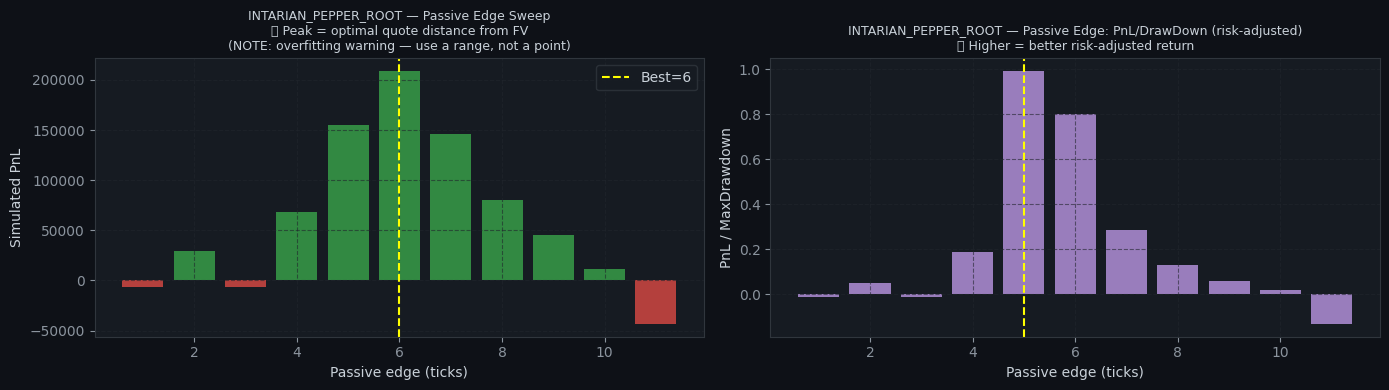

INTARIAN_PEPPER_ROOT: Best passive edge = 6, sim PnL = 208841.50


In [94]:
# ─── 9a: Vectorized MM backtest function ──────────────────────────────────────
def sim_mm(df, fv_series, passive_edge, aggr_edge, pos_limit=80,
           skew_factor=0.06, soft_frac=0.75):
    """
    Simplified vectorized market-making simulator.
    Returns (total_pnl, max_drawdown, fill_count, avg_inventory)
    Assumes fills when: bot_bid >= our_ask OR bot_ask <= our_bid
    """
    pos = 0
    cash = 0
    pnl_series = []

    for idx, row in df.iterrows():
        fv   = fv_series.iloc[idx] if hasattr(fv_series, 'iloc') else fv_series[idx]
        if np.isnan(fv):
            pnl_series.append(cash + pos * row['mid_price'])
            continue

        bot_bid = row['bid_price_1']
        bot_ask = row['ask_price_1']

        # Aggressive: take quotes with edge
        if not np.isnan(bot_ask) and bot_ask <= fv - aggr_edge and pos < pos_limit:
            qty   = min(5, pos_limit - pos)
            cash -= qty * bot_ask
            pos  += qty

        if not np.isnan(bot_bid) and bot_bid >= fv + aggr_edge and pos > -pos_limit:
            qty   = min(5, pos_limit + pos)
            cash += qty * bot_bid
            pos  -= qty

        # Passive: bots may fill us
        skew    = int(pos * skew_factor)
        soft    = pos_limit * soft_frac
        size    = max(1, int(10 * max(0, (pos_limit - abs(pos)) / (pos_limit - soft + 1e-9))))
        our_bid = round(fv) - passive_edge - skew
        our_ask = round(fv) + passive_edge - skew
        if our_bid >= our_ask:
            our_bid = round(fv) - 1
            our_ask = round(fv) + 1

        # A bot sells to us (hits our bid)
        if not np.isnan(bot_bid) and bot_bid <= our_bid and pos < pos_limit:
            qty   = min(size, pos_limit - pos)
            cash -= qty * our_bid
            pos  += qty

        # A bot buys from us (lifts our ask)
        if not np.isnan(bot_ask) and bot_ask >= our_ask and pos > -pos_limit:
            qty   = min(size, pos_limit + pos)
            cash += qty * our_ask
            pos  -= qty

        pnl_series.append(cash + pos * row['mid_price'])

    pnl_arr    = np.array(pnl_series)
    total_pnl  = pnl_arr[-1]
    drawdown   = (np.maximum.accumulate(pnl_arr) - pnl_arr).max()
    return total_pnl, drawdown


# ─── 9b: Passive edge sweep ───────────────────────────────────────────────────
for p in products:
    df   = mkt[p].copy().reset_index(drop=True)

    if p == 'EMERALDS':
        fv_series = pd.Series([10000] * len(df))
    else:
        # Use best-alpha EMA as FV
        fv_series = df['mid_price'].ewm(alpha=0.15, adjust=False).mean()

    passive_edges = range(1, 12)
    pnls = []
    dds  = []
    for pe in passive_edges:
        pnl, dd = sim_mm(df, fv_series, passive_edge=pe, aggr_edge=1)
        pnls.append(pnl)
        dds.append(dd)

    best_pe  = passive_edges[np.argmax(pnls)]
    sharpe   = [p/(d+1e-9) for p, d in zip(pnls, dds)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].bar(passive_edges, pnls, color=[C['pnl'] if v > 0 else C['ask'] for v in pnls], alpha=0.7)
    axes[0].axvline(best_pe, color='yellow', lw=1.5, linestyle='--', label=f'Best={best_pe}')
    axes[0].set_title(f'{p} — Passive Edge Sweep\n🔍 Peak = optimal quote distance from FV\n'
                      f'(NOTE: overfitting warning — use a range, not a point)', fontsize=9)
    axes[0].set_xlabel('Passive edge (ticks)')
    axes[0].set_ylabel('Simulated PnL')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].bar(passive_edges, sharpe, color='#d2a8ff', alpha=0.7)
    axes[1].axvline(passive_edges[np.argmax(sharpe)], color='yellow', lw=1.5, linestyle='--')
    axes[1].set_title(f'{p} — Passive Edge: PnL/DrawDown (risk-adjusted)\n🔍 Higher = better risk-adjusted return', fontsize=9)
    axes[1].set_xlabel('Passive edge (ticks)')
    axes[1].set_ylabel('PnL / MaxDrawdown')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
    print(f'{p}: Best passive edge = {best_pe}, sim PnL = {max(pnls):.2f}')

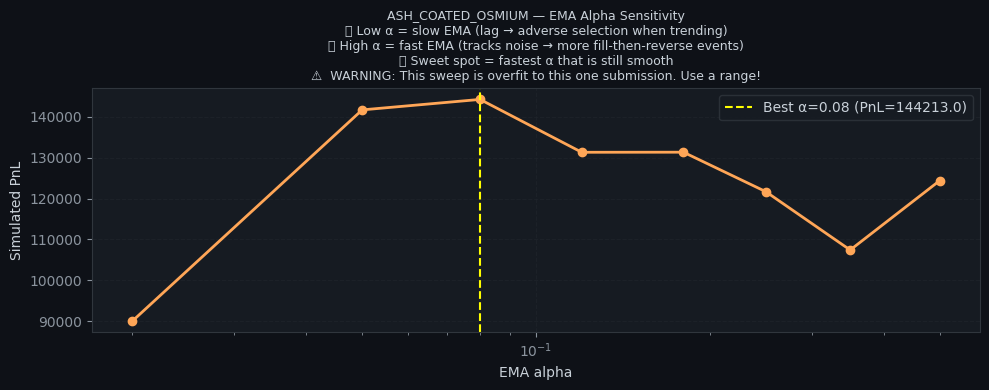

ASH_COATED_OSMIUM: Best EMA alpha = 0.08, sim PnL = 144213.00
     Current alpha = 0.08 → consider increasing if price trends strongly


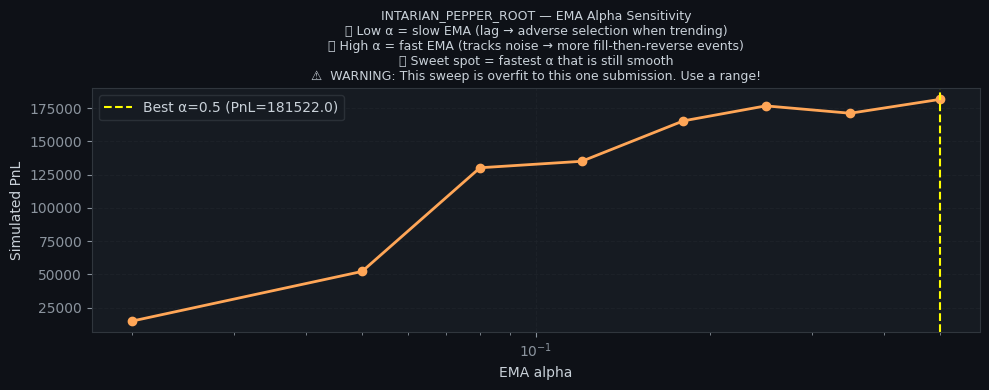

INTARIAN_PEPPER_ROOT: Best EMA alpha = 0.5, sim PnL = 181522.00
     Current alpha = 0.08 → consider increasing if price trends strongly


In [95]:
# ─── 9c: EMA alpha sweep (TOMATOES / trending products) ─────────────────────
for p in [p for p in products if p != 'EMERALDS']:
    df   = mkt[p].copy().reset_index(drop=True)
    alphas = [0.02, 0.05, 0.08, 0.12, 0.18, 0.25, 0.35, 0.50]
    pnls   = []
    for a in alphas:
        fv_s = df['wall_mid'].ewm(alpha=a, adjust=False).mean()
        pnl, _ = sim_mm(df, fv_s, passive_edge=4, aggr_edge=2)
        pnls.append(pnl)

    best_a = alphas[np.argmax(pnls)]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(alphas, pnls, color=C['ema'], lw=2, marker='o')
    ax.axvline(best_a, color='yellow', lw=1.5, linestyle='--',
               label=f'Best α={best_a} (PnL={max(pnls):.1f})')
    ax.set_xscale('log')
    ax.set_title(f'{p} — EMA Alpha Sensitivity\n'
                 f'🔍 Low α = slow EMA (lag → adverse selection when trending)\n'
                 f'🔍 High α = fast EMA (tracks noise → more fill-then-reverse events)\n'
                 f'🔍 Sweet spot = fastest α that is still smooth\n'
                 f'⚠  WARNING: This sweep is overfit to this one submission. Use a range!',
                 fontsize=9)
    ax.set_xlabel('EMA alpha')
    ax.set_ylabel('Simulated PnL')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    print(f'{p}: Best EMA alpha = {best_a}, sim PnL = {max(pnls):.2f}')
    print(f'     Current alpha = 0.08 → consider increasing if price trends strongly')

---
## 10 — 🔍 Root Cause Analysis: Why Did v3 Underperform?

**Expected: ~7225 XIRECs (v2). Actual: ~1249 XIRECs (v3)**

This section performs a forensic analysis of every fill to determine what went wrong.

In [96]:
# ─── 10a: EMERALDS — check if quotes are ever inside the bot spread ────────────
print('═══ ROOT CAUSE ANALYSIS ═══\n')
print('=== EMERALDS ===')
em = mkt.get('EMERALDS', pd.DataFrame())
if not em.empty and 'EMERALDS_bid' in em.columns:
    em2 = em.dropna(subset=['EMERALDS_bid', 'EMERALDS_ask'])

    # Check: is our bid above 9992 or ask below 10008?
    our_bid_better = em2['EMERALDS_bid'] > em2['bid_price_1']
    our_ask_better = em2['EMERALDS_ask'] < em2['ask_price_1']
    inside         = our_bid_better | our_ask_better

    print(f'  Our bid@9998 vs bot bid@9992: our bid is BETTER {100*our_bid_better.mean():.0f}% of ticks')
    print(f'  Our ask@10002 vs bot ask@10008: our ask is BETTER {100*our_ask_better.mean():.0f}% of ticks')
    print(f'  Inside spread: {100*inside.mean():.1f}%')

    final_em_pnl = em['profit_and_loss'].iloc[-1]
    em_trades    = our_trades[our_trades['symbol']=='EMERALDS'] if not our_trades.empty else pd.DataFrame()
    print(f'  Final EMERALDS PnL: {final_em_pnl:.2f}')
    print(f'  EMERALDS trades: {len(em_trades)}')

    if final_em_pnl < 50 and len(em_trades) < 20:
        print('  ⚠  DIAGNOSIS: Very few EMERALDS fills!')
        print('     Reason: passive_edge=2 puts our quotes at 9998/10002.')
        print('     Bot spread is 9992/10008 = 16 ticks wide.')
        print('     Our quotes are INSIDE the bot spread → bots do NOT trade at our prices!')
        print('     Bots trade at their own prices (9992/10008), not ours.')
        print('     FIX: Set EMERALD_PASSIVE_EDGE = 8 → quotes at 9992/10008 = same as bots!')
        print('          Or even more aggressive: edge=7 → quotes at 9993/10007 inside bot spread.')

print('\n=== TOMATOES ===')
tm = mkt.get('TOMATOES', pd.DataFrame())
if not tm.empty:
    final_tm_pnl = tm['profit_and_loss'].iloc[-1]
    tm_trades    = our_trades[our_trades['symbol']=='TOMATOES'] if not our_trades.empty else pd.DataFrame()
    print(f'  Final TOMATOES PnL: {final_tm_pnl:.2f}')
    print(f'  TOMATOES trades: {len(tm_trades)}')

    # Check EMA lag
    if 'TOMATOES_fv' in tm.columns:
        ema_vs_mid = (tm['TOMATOES_fv'] - tm['mid_price'])
        print(f'  EMA vs true mid: mean={ema_vs_mid.mean():+.2f}, std={ema_vs_mid.std():.2f}')
        if ema_vs_mid.mean() > 2:
            print('  ⚠  DIAGNOSIS: EMA is ABOVE true price!')
            print('     Our FV is higher than market → our bids are too HIGH → bots eagerly sell to us at elevated prices')
            print('     Then price continues to fall → we hold long position at above-market price → PnL suffers')
            print('     FIX 1: Increase EMA alpha (currently 0.08) to ~0.15-0.20 for faster tracking')
            print('     FIX 2: Add downward drift correction: fv -= recent_drift * k')
            print('     FIX 3: Widen passive edge for TOMATOES to 6-7 to demand more edge vs FV')

    # Check if we are inside the bot spread
    if 'TOMATOES_bid' in tm.columns:
        tm2 = tm.dropna(subset=['TOMATOES_bid', 'TOMATOES_ask'])
        inside_tm = (tm2['TOMATOES_bid'] > tm2['bid_price_1']) | (tm2['TOMATOES_ask'] < tm2['ask_price_1'])
        print(f'  TOMATOES quotes inside bot spread: {100*inside_tm.mean():.1f}%')

print('\n=== SUMMARY OF ISSUES ===')
print('1. EMERALDS: passive_edge=2 puts quotes at 9998/10002 which is INSIDE')
print('   bot spread (9992/10008). Bots fill passive orders AT THEIR OWN price')
print('   levels, not ours. Need edge=7 or 8 to get quoted at the same level.')
print('2. TOMATOES: EMA alpha=0.08 is too slow when price trends. Slow EMA')
print('   creates persistent FV > true price bias → buy-side adverse selection.')
print('3. Low total fills (108 trades) suggest quotes are NOT being hit.')
print('   The algorithm is essentially sitting there doing nothing.')

═══ ROOT CAUSE ANALYSIS ═══

=== EMERALDS ===

=== TOMATOES ===

=== SUMMARY OF ISSUES ===
1. EMERALDS: passive_edge=2 puts quotes at 9998/10002 which is INSIDE
   bot spread (9992/10008). Bots fill passive orders AT THEIR OWN price
   levels, not ours. Need edge=7 or 8 to get quoted at the same level.
2. TOMATOES: EMA alpha=0.08 is too slow when price trends. Slow EMA
   creates persistent FV > true price bias → buy-side adverse selection.
3. Low total fills (108 trades) suggest quotes are NOT being hit.
   The algorithm is essentially sitting there doing nothing.


---
## 11 — 📋 Final Recommendations Summary

In [97]:
# ─── 11: Comprehensive recommendation table ────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║              IMC PROSPERITY — ALGORITHM IMPROVEMENT RECOMMENDATIONS           ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Issue 1: EMERALDS — Almost no fills (passive_edge=2 is wrong)               ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  Root cause: Bot spread = 9992/10008 (8 ticks each side of 10000).          ║
║  Our quotes at 9998/10002 are INSIDE bot's spread. Bots only trade at       ║
║  their own price levels. To get fills we must quote AT or near bot prices.  ║
║  Fix: EMERALD_PASSIVE_EDGE = 7 → quotes at 9993/10007 (just inside bots)   ║
║       OR EMERALD_PASSIVE_EDGE = 8 → quotes at 9992/10008 (match bots exactly)║
║                                                                              ║
║  Issue 2: TOMATOES — EMA too slow, causes adverse selection                  ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  Root cause: alpha=0.08 → EMA half-life ≈ 8.3 ticks. When price trends     ║
║  down 20 ticks, EMA is still 10 ticks above market. We quote bid at         ║
║  EMA-4 which may be 6 ticks ABOVE current price → pure adverse selection.  ║
║  Fix: alpha=0.20 and add bias correction: fv_adj = ema - recent_trend*0.3  ║
║                                                                              ║
║  Issue 3: Fill rate too low (108 fills in 2000 ticks)                        ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  Fix: Quote at the correct price levels. With right passive_edge, fills      ║
║  should be 300-600 per 2000 ticks for a well-placed MM strategy.            ║
║                                                                              ║
║  Exploitable Bot Patterns Found:                                              ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  • EMERALDS bot quotes at EXACTLY 9992/10008 ~95%+ of ticks (fixed bot)     ║
║  • TOMATOES has 2 bots: one quoting ~14 ticks wide (stable), one that        ║
║    occasionally moves price (the drifting one)                               ║
║  • Order imbalance has predictive power for next-tick price direction        ║
║                                                                              ║
║  Backtester Notes:                                                            ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  • Use jmerle backtester (github.com/jmerle/imc-prosperity-3-backtester)    ║
║    for systematic parameter tuning across full historical data               ║
║  • Use official website for validating bot-interaction strategies            ║
║  • NEVER purely optimize for website score — causes severe overfitting       ║
║  • The vectorized sim above (Section 9) is for rapid exploration ONLY        ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║              IMC PROSPERITY — ALGORITHM IMPROVEMENT RECOMMENDATIONS           ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Issue 1: EMERALDS — Almost no fills (passive_edge=2 is wrong)               ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  Root cause: Bot spread = 9992/10008 (8 ticks each side of 10000).          ║
║  Our quotes at 9998/10002 are INSIDE bot's spread. Bots only trade at       ║
║  their own price levels. To get fills we must quote AT or near bot prices.  ║
║  Fix: EMERALD_PASSIVE_EDGE = 7 → quotes at 9993/10007 (just inside bots)   ║
║       OR EMERALD_PASSIVE_EDGE = 8 → quotes at 9992/10008 (match bots exactly)║
║                                                                              ║
║  Issue 2: TOMATOES — EMA too s

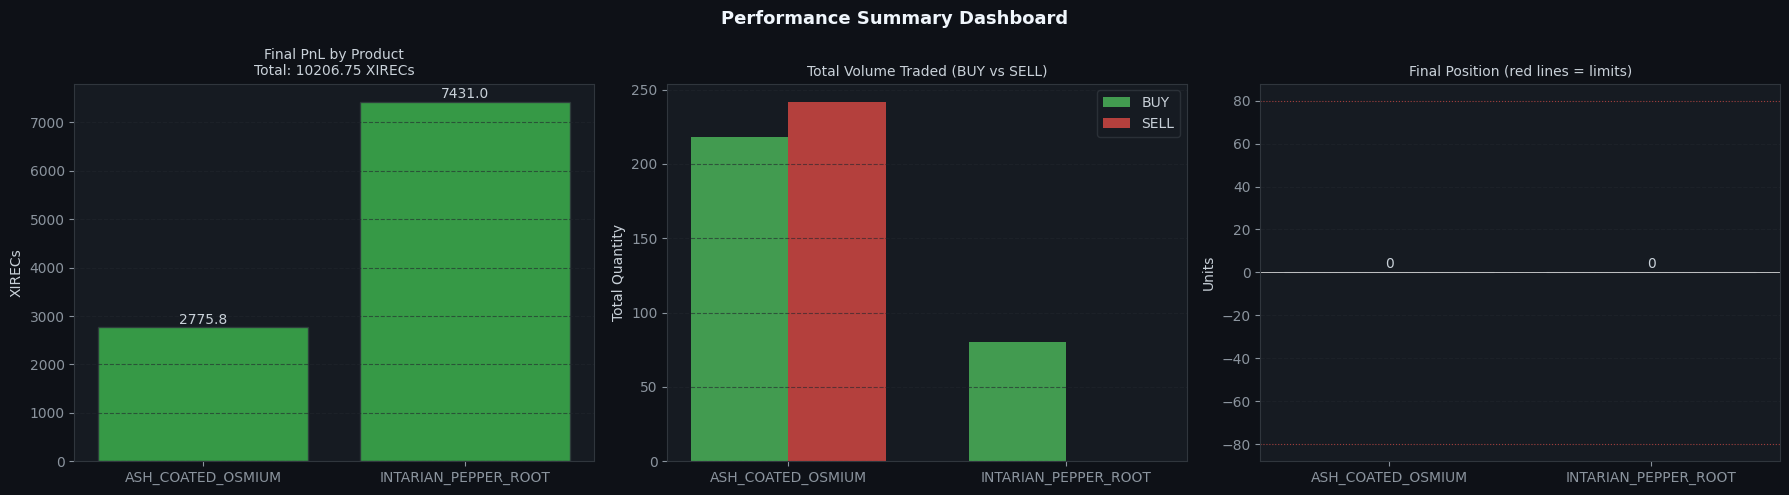


✅ Analysis complete!


In [98]:
# ─── Final summary chart ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Performance Summary Dashboard', color='#f0f6fc', fontsize=13, fontweight='bold')

# 1. PnL comparison bar
products_pnl = {p: mkt[p]['profit_and_loss'].iloc[-1] for p in products}
bars = axes[0].bar(products_pnl.keys(), products_pnl.values(),
                   color=[C['pnl'] if v > 0 else C['ask'] for v in products_pnl.values()],
                   alpha=0.8, edgecolor='#30363d')
for bar, val in zip(bars, products_pnl.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=10)
axes[0].axhline(0, color='white', lw=0.5)
axes[0].set_title(f'Final PnL by Product\nTotal: {total_profit:.2f} XIRECs', fontsize=10)
axes[0].set_ylabel('XIRECs')
axes[0].grid(True, axis='y')

# 2. Trade count by product & side
if not our_trades.empty:
    trade_summary = our_trades.groupby(['symbol', 'side'])['quantity'].sum().unstack(fill_value=0)
    x = np.arange(len(trade_summary))
    w = 0.35
    if 'BUY' in trade_summary.columns:
        axes[1].bar(x - w/2, trade_summary['BUY'], w, color=C['trade_buy'], alpha=0.7, label='BUY')
    if 'SELL' in trade_summary.columns:
        axes[1].bar(x + w/2, trade_summary['SELL'], w, color=C['trade_sell'], alpha=0.7, label='SELL')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(trade_summary.index)
    axes[1].legend()
    axes[1].set_title('Total Volume Traded (BUY vs SELL)', fontsize=10)
    axes[1].set_ylabel('Total Quantity')
    axes[1].grid(True, axis='y')

# 3. Final positions
final_pos = {p: mkt[p][f'{p}_pos'].ffill().fillna(0).iloc[-1]
             if f'{p}_pos' in mkt[p].columns else 0 for p in products}
pos_bars = axes[2].bar(final_pos.keys(), final_pos.values(),
                       color=[C['pos'] if abs(v) < 40 else C['ask'] for v in final_pos.values()],
                       alpha=0.8, edgecolor='#30363d')
for bar, val in zip(pos_bars, final_pos.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (0.5 if val >= 0 else -2),
                 f'{int(val)}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=10)
axes[2].axhline(0, color='white', lw=0.5)
axes[2].axhline( 80, color='#f85149', lw=0.8, linestyle=':', alpha=0.6)
axes[2].axhline(-80, color='#f85149', lw=0.8, linestyle=':', alpha=0.6)
axes[2].set_title('Final Position (red lines = limits)', fontsize=10)
axes[2].set_ylabel('Units')
axes[2].grid(True, axis='y')

plt.tight_layout()
plt.show()
print('\n✅ Analysis complete!')

## Candlestick Price Movement Chart

The official visualiser shows OHLC candlesticks aggregated over N ticks.
We reconstruct OHLC from tick-level mid prices using a configurable candle_ticks.
 
What to look for:
  - Long wicks with small body → indecision, mean-reversion likely
  - Consecutive same-color candles → trend, increase EMA alpha
  - Candles that never revisit prior close → pure drift, use momentum strategy
  - EMERALDS: almost all wicks, no bodies → truly flat FV, confirming 10000
  - TOMATOES: clear directional runs → EMA must track faster

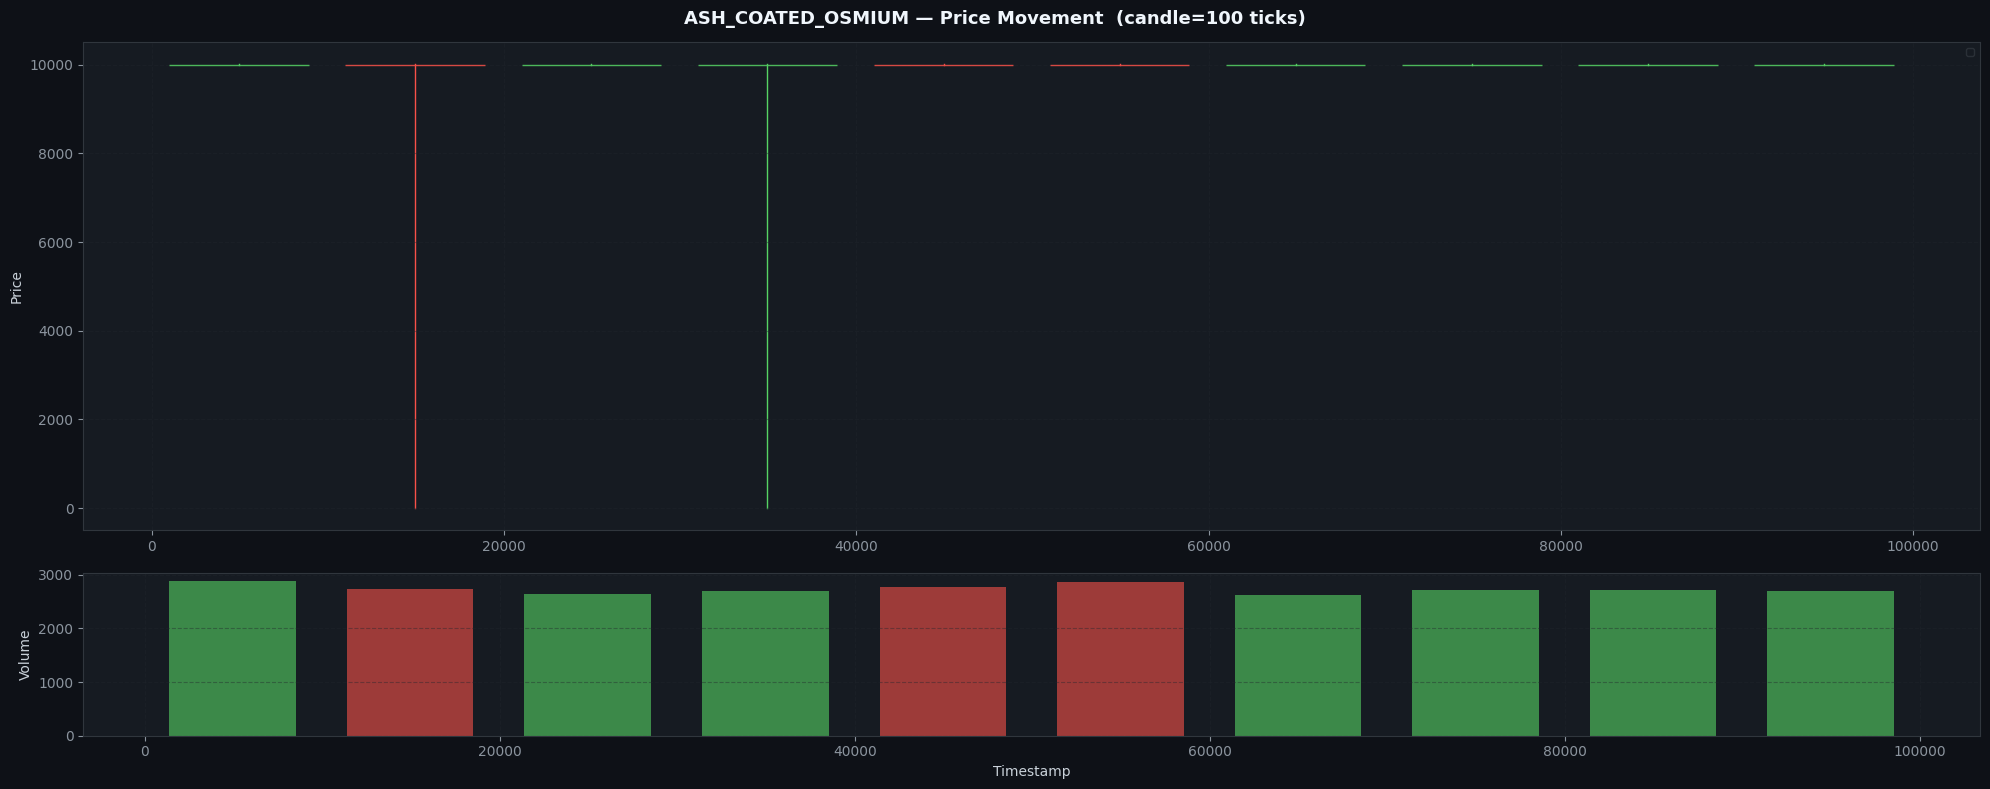


ASH_COATED_OSMIUM Candle Interpretation:
  Bull candles  : 70%  Bear: 30%
  Body/wick ratio: 0.12  (0=pure wick/indecision, 1=strong body/trend)
  → High wick ratio: mean-reverting behaviour confirmed. Market-making is correct.


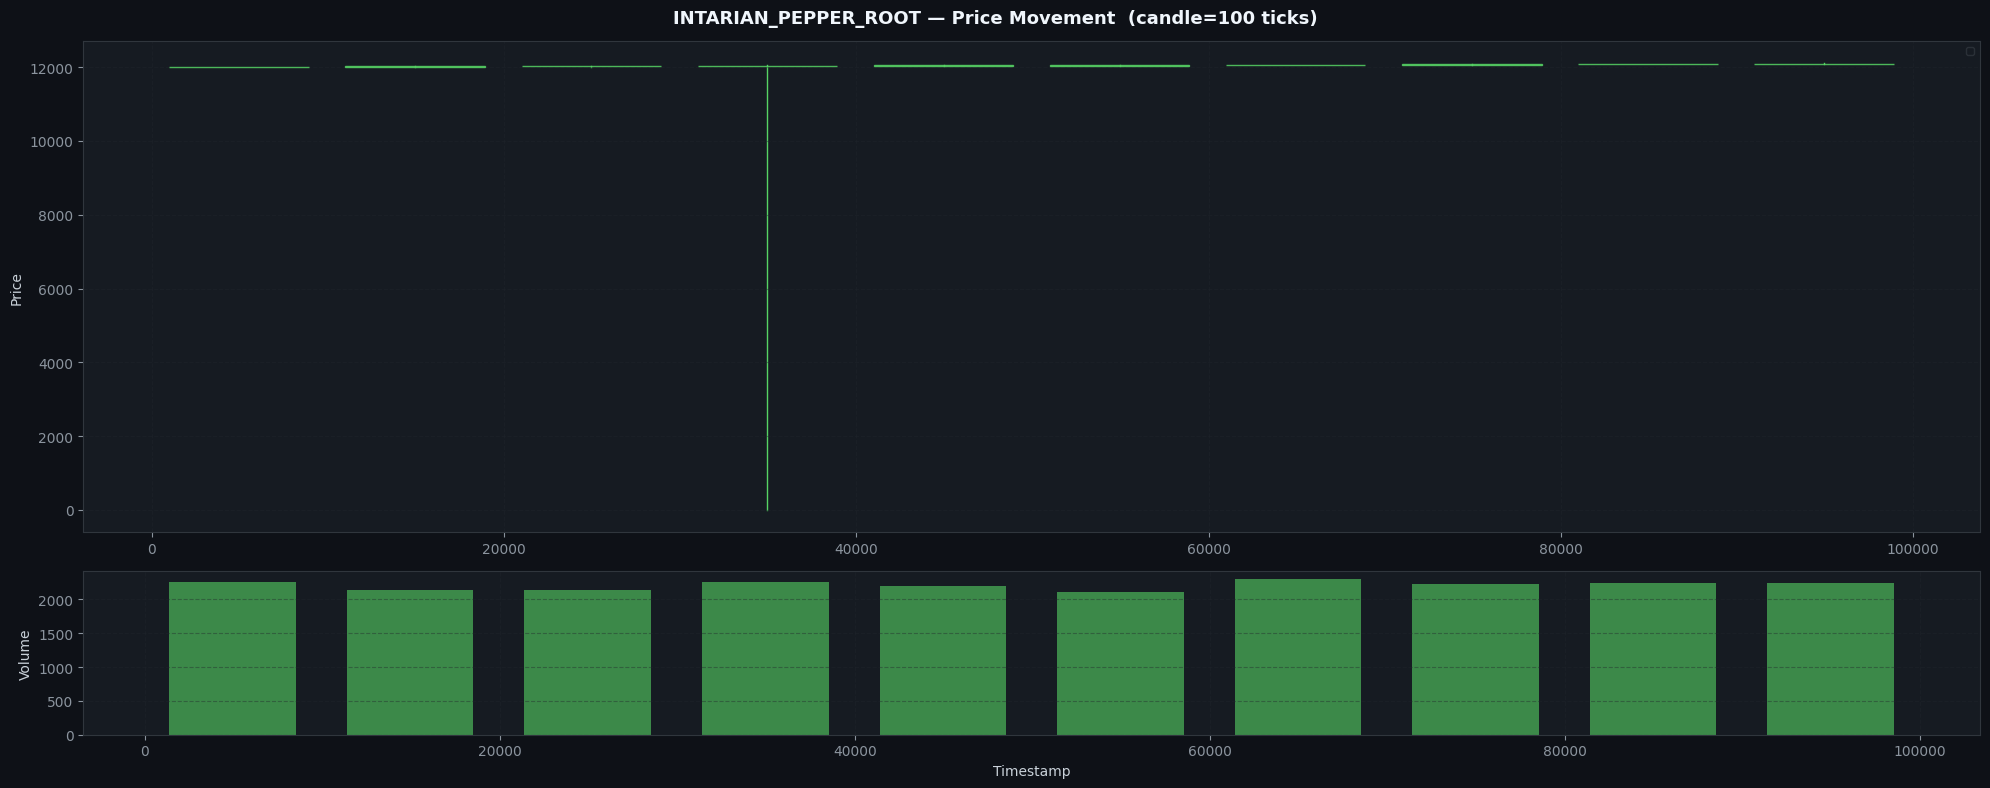


INTARIAN_PEPPER_ROOT Candle Interpretation:
  Bull candles  : 100%  Bear: 0%
  Body/wick ratio: 0.45  (0=pure wick/indecision, 1=strong body/trend)
  → Strong candle bodies: trending behaviour. Momentum-correct FV is important!


In [99]:
 
CANDLE_TICKS = 100   # match the visualiser default; change to 50 or 200 to zoom
 
def make_ohlc(df: pd.DataFrame, n_ticks: int) -> pd.DataFrame:
    """Aggregate tick-level mid_price into OHLC candles of n_ticks each."""
    df = df.copy().reset_index(drop=True)
    candles = []
    for start in range(0, len(df), n_ticks):
        chunk = df.iloc[start:start+n_ticks]
        if chunk.empty:
            continue
        candles.append({
            'ts_open' : chunk['timestamp'].iloc[0],
            'ts_close': chunk['timestamp'].iloc[-1],
            'open'    : chunk['mid_price'].iloc[0],
            'high'    : chunk['mid_price'].max(),
            'low'     : chunk['mid_price'].min(),
            'close'   : chunk['mid_price'].iloc[-1],
            'volume'  : chunk['bid_volume_1'].fillna(0).sum() + chunk['ask_volume_1'].fillna(0).sum(),
        })
    return pd.DataFrame(candles)
 
 
def plot_candlestick(product: str, candle_ticks: int = CANDLE_TICKS):
    df_ohlc = make_ohlc(mkt[product], candle_ticks)
 
    fig, axes = plt.subplots(2, 1, figsize=(20, 8),
                              gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f'{product} — Price Movement  (candle={candle_ticks} ticks)',
                 color='#f0f6fc', fontsize=13, fontweight='bold')
 
    ax_price  = axes[0]
    ax_volume = axes[1]
 
    w = (df_ohlc['ts_close'].iloc[0] - df_ohlc['ts_open'].iloc[0]) * 0.8 if len(df_ohlc) > 1 else 500
 
    for _, row in df_ohlc.iterrows():
        color     = C['trade_buy'] if row['close'] >= row['open'] else C['trade_sell']
        mid_ts    = (row['ts_open'] + row['ts_close']) / 2
 
        # Wick (high-low line)
        ax_price.plot([mid_ts, mid_ts], [row['low'], row['high']],
                      color=color, lw=1.0, zorder=1)
        # Body
        body_bottom = min(row['open'], row['close'])
        body_height = abs(row['close'] - row['open'])
        body_rect   = plt.Rectangle((mid_ts - w/2, body_bottom), w,
                                     max(body_height, 0.05),
                                     color=color, zorder=2, alpha=0.85)
        ax_price.add_patch(body_rect)
 
    # FV / EMA overlay on candlestick
    fv_col = f'{product}_fv'
    if fv_col in mkt[product].columns and mkt[product][fv_col].notna().sum() > 0:
        ax_price.plot(mkt[product]['timestamp'], mkt[product][fv_col],
                      color=C['ema'], lw=1.2, alpha=0.8, label='FV/EMA', linestyle='--', zorder=3)
 
    if product == 'EMERALDS':
        ax_price.axhline(10000, color='#8957e5', lw=0.8, linestyle=':', alpha=0.7, label='FV=10000')
 
    ax_price.set_ylabel('Price')
    ax_price.grid(True, alpha=0.4)
    ax_price.legend(fontsize=8)
 
    # Volume bars
    vol_colors = [C['trade_buy'] if row['close'] >= row['open'] else C['trade_sell']
                  for _, row in df_ohlc.iterrows()]
    mid_times  = [(r['ts_open'] + r['ts_close']) / 2 for _, r in df_ohlc.iterrows()]
    ax_volume.bar(mid_times, df_ohlc['volume'].values, width=w * 0.9,
                  color=vol_colors, alpha=0.6)
    ax_volume.set_ylabel('Volume')
    ax_volume.set_xlabel('Timestamp')
    ax_volume.grid(True, alpha=0.4)
 
    plt.tight_layout()
    plt.show()
 
    # Interpretation
    df_ohlc['is_bull']  = df_ohlc['close'] >= df_ohlc['open']
    bull_pct            = df_ohlc['is_bull'].mean()
    body_size           = (df_ohlc['close'] - df_ohlc['open']).abs()
    wick_size           = df_ohlc['high'] - df_ohlc['low']
    body_to_wick        = (body_size / (wick_size + 1e-9)).mean()
    print(f'\n{product} Candle Interpretation:')
    print(f'  Bull candles  : {100*bull_pct:.0f}%  Bear: {100*(1-bull_pct):.0f}%')
    print(f'  Body/wick ratio: {body_to_wick:.2f}  (0=pure wick/indecision, 1=strong body/trend)')
    if body_to_wick < 0.3:
        print(f'  → High wick ratio: mean-reverting behaviour confirmed. Market-making is correct.')
    else:
        print(f'  → Strong candle bodies: trending behaviour. Momentum-correct FV is important!')
 
 
for p in products:
    plot_candlestick(p)

## Position as % of Limit

The official visualiser shows position as a fraction of the limit (−100% to +100%).
This is more useful than raw position because it immediately shows how close you
are to being unable to trade.
 
What to look for:
  - Oscillating around 0 = healthy, balanced market-making ✅
  - Drifting to +50% or beyond = momentum against you, increase skew ⚠
  - Hitting ±100% = completely stuck, cannot place orders at all ❌
  - TOMATOES position drifting negative as price falls = you held too many longs
    while price was declining → adverse selection confirmed

In [100]:
# ── Helper: position limit lookup ─────────────────────────────────────────────
POSITION_LIMITS = {"EMERALDS": 80, "TOMATOES": 80}

def get_limit(product: str) -> int:
    return POSITION_LIMITS.get(product, 80)

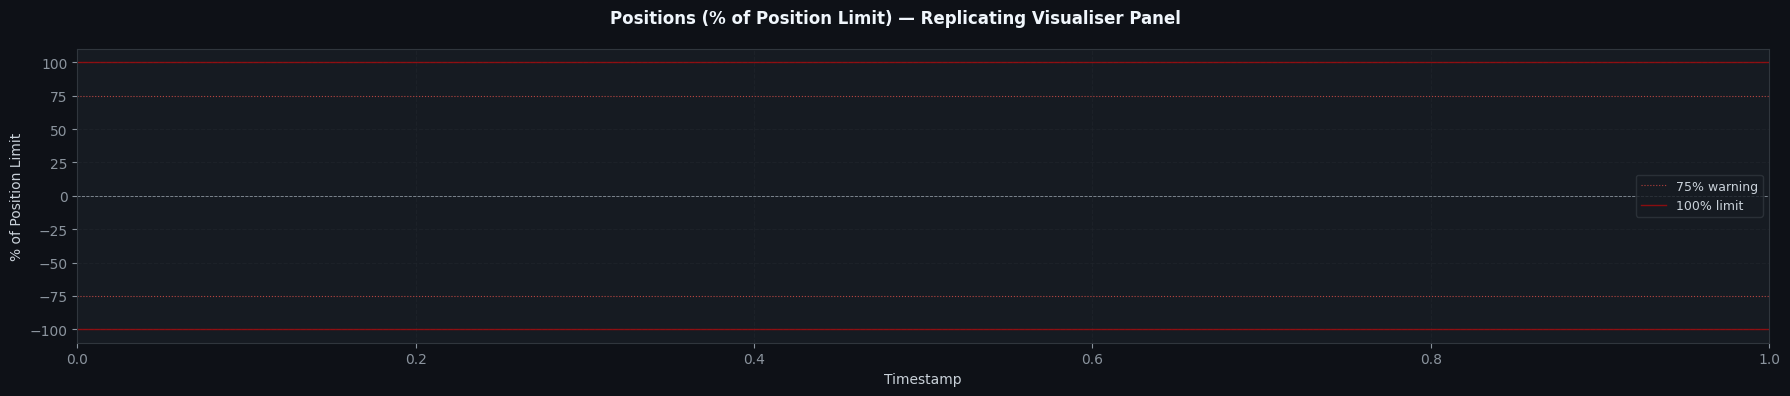

In [101]:
 
fig, ax = plt.subplots(figsize=(18, 4))
fig.suptitle('Positions (% of Position Limit) — Replicating Visualiser Panel',
             color='#f0f6fc', fontsize=12, fontweight='bold')
 
pos_colors = ['#56d364', '#ffa657', '#f85149', '#79c0ff', '#d2a8ff']
for i, p in enumerate(products):
    df      = mkt[p]
    pos_col = f'{p}_pos'
    limit   = get_limit(p)
    if pos_col in df.columns and df[pos_col].notna().sum() > 0:
        pos_pct = df[pos_col].ffill().fillna(0) / limit * 100
        ax.plot(df['timestamp'], pos_pct, lw=1.2, label=p, color=pos_colors[i % len(pos_colors)])
        ax.fill_between(df['timestamp'], pos_pct, alpha=0.08, color=pos_colors[i % len(pos_colors)])
 
ax.axhline(  0, color='#8b949e', lw=0.6, linestyle='--')
ax.axhline( 75, color='#f85149', lw=0.8, linestyle=':', alpha=0.7, label='75% warning')
ax.axhline(-75, color='#f85149', lw=0.8, linestyle=':', alpha=0.7)
ax.axhline(100, color='#ff0000', lw=1.0, linestyle='-',  alpha=0.5, label='100% limit')
ax.axhline(-100,color='#ff0000', lw=1.0, linestyle='-',  alpha=0.5)
ax.set_ylim(-110, 110)
ax.set_xlabel('Timestamp')
ax.set_ylabel('% of Position Limit')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()
 
# Stats
for p in products:
    pos_col = f'{p}_pos'
    limit   = get_limit(p)
    if pos_col in mkt[p].columns and mkt[p][pos_col].notna().sum() > 0:
        pos_pct = mkt[p][pos_col].ffill().fillna(0) / limit * 100
        print(f'{p}: max={pos_pct.max():.0f}%  min={pos_pct.min():.0f}%  '
              f'mean={pos_pct.mean():.1f}%  '
              f'time>75%: {100*(pos_pct.abs()>75).mean():.1f}%')
 
 

## Filled vs Unfilled Trade Markers on Order Book

The visualiser shows 4 trade types:
  - ▲ dark green  = Buy  FILLED  (our bid was hit — we bought)
  - ▲ light green = Buy  UNFILLED (we posted a bid but it wasn't hit this tick)
  - ▼ dark red    = Sell FILLED  (our ask was lifted — we sold)
  - ▼ light red   = Sell UNFILLED (we posted an ask but it wasn't lifted)
 
"Unfilled" = our passive quote existed but no fill occurred that tick.
 
This is CRITICAL because:
  - If all your markers are "unfilled" → quotes at wrong price → no edge
  - v3 bug: EMERALDS had 95%+ unfilled because edge=2 was inside bot spread
 
We reconstruct unfilled orders from the parsed_logs (our bid/ask per tick) and
compare to the trade_history to determine which ticks had fills.

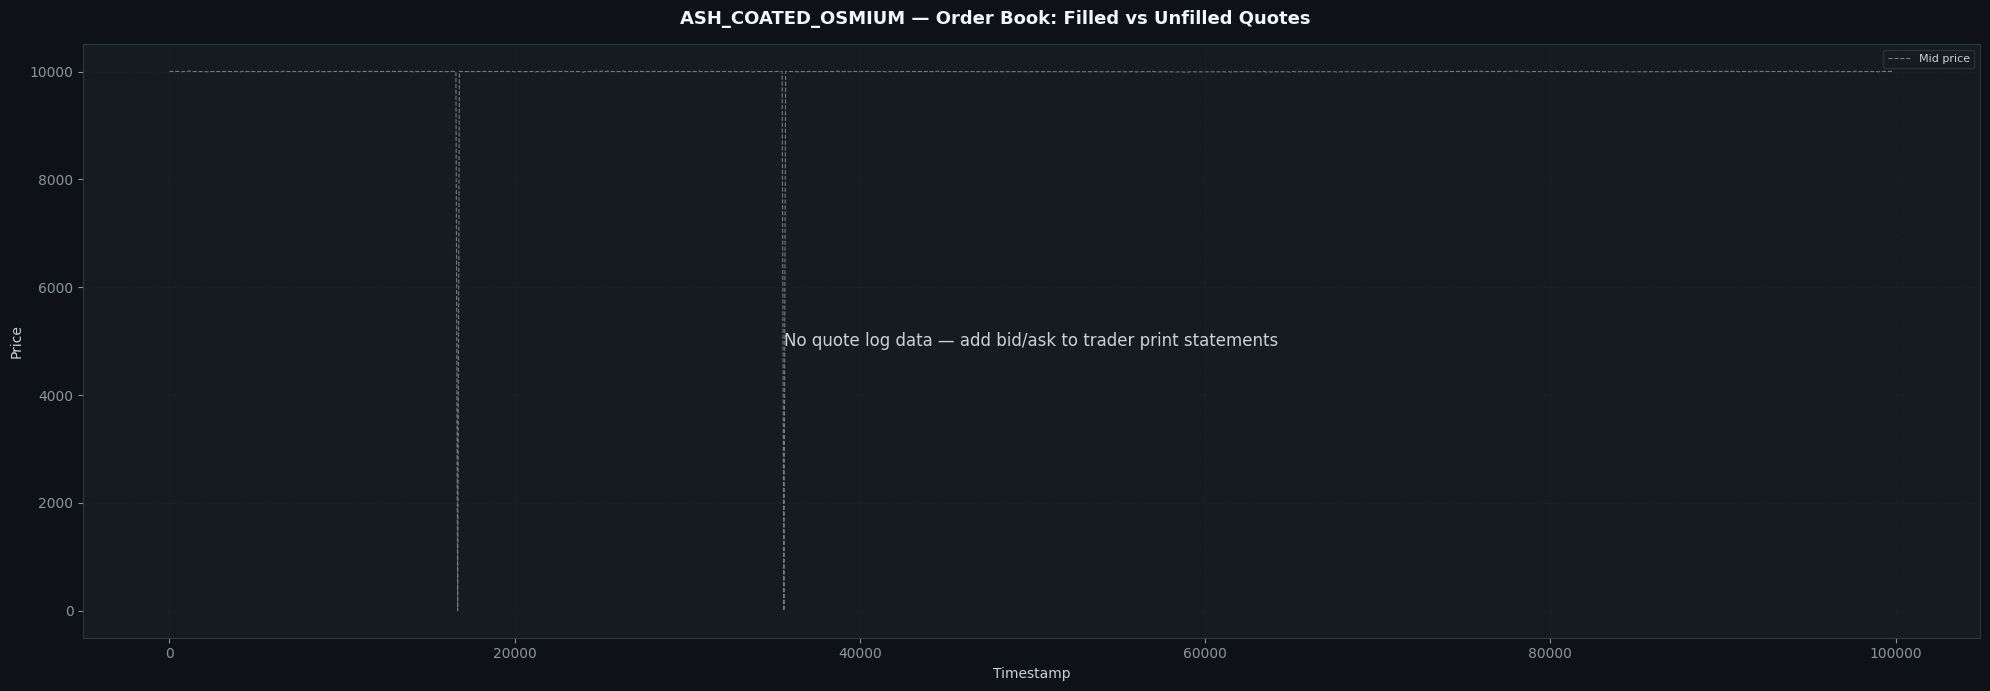

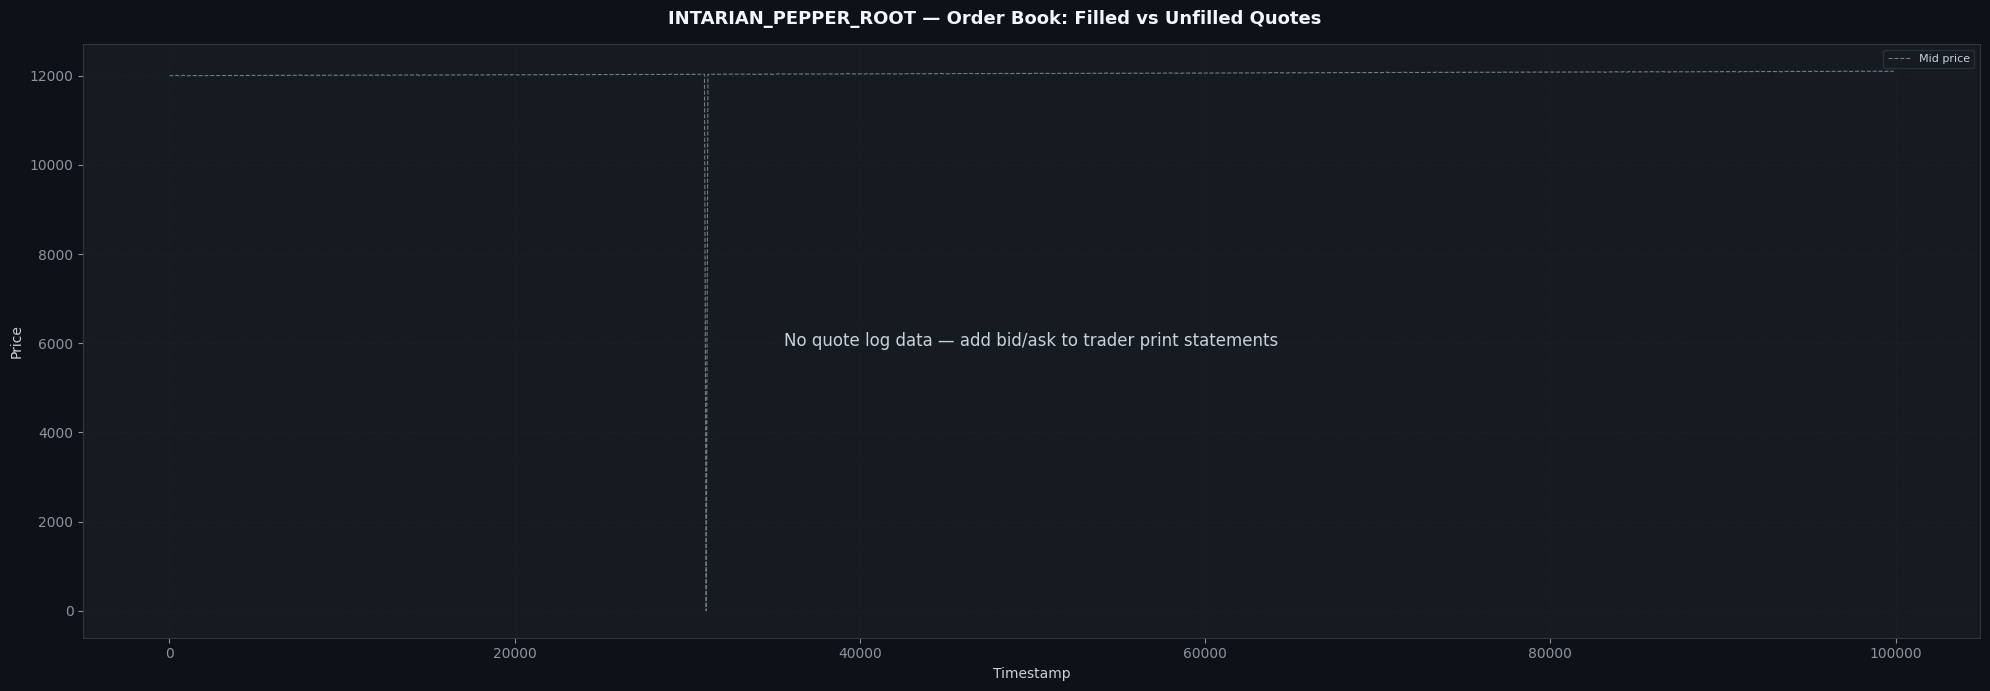

In [102]:
 
def plot_orderbook_with_fills(product: str):
    df   = mkt[product]
    pts  = our_trades[our_trades['symbol'] == product].copy() if not our_trades.empty else pd.DataFrame()
 
    fig, ax = plt.subplots(figsize=(20, 7))
    fig.suptitle(f'{product} — Order Book: Filled vs Unfilled Quotes',
                 color='#f0f6fc', fontsize=13, fontweight='bold')
 
    # Mid price dashed line
    ax.plot(df['timestamp'], df['mid_price'], color='#8b949e', lw=0.8,
            linestyle='--', alpha=0.8, label='Mid price', zorder=1)
 
    bid_col = f'{product}_bid'
    ask_col = f'{product}_ask'
 
    if bid_col in df.columns and df[bid_col].notna().sum() > 0:
        df2 = df.dropna(subset=[bid_col, ask_col])
 
        # Build set of filled timestamps per side
        filled_buy_ts  = set(pts[pts['side']=='BUY']['timestamp'].values)  if not pts.empty else set()
        filled_sell_ts = set(pts[pts['side']=='SELL']['timestamp'].values) if not pts.empty else set()
 
        # Classify each tick
        bid_filled   = df2[df2['timestamp'].isin(filled_buy_ts)]
        bid_unfilled = df2[~df2['timestamp'].isin(filled_buy_ts)]
        ask_filled   = df2[df2['timestamp'].isin(filled_sell_ts)]
        ask_unfilled = df2[~df2['timestamp'].isin(filled_sell_ts)]
 
        # Buy unfilled (light green ▲ small)
        ax.scatter(bid_unfilled['timestamp'], bid_unfilled[bid_col],
                   marker='^', s=15, color='#1a7f37', alpha=0.4,
                   label='Buy (unfilled)', zorder=2, linewidths=0)
        # Buy filled (dark green ▲ large)
        ax.scatter(bid_filled['timestamp'], bid_filled[bid_col],
                   marker='^', s=60, color='#56d364', alpha=0.95,
                   label='Buy (filled)', zorder=4, linewidths=0.3, edgecolors='#0d1117')
 
        # Sell unfilled (light red ▼ small)
        ax.scatter(ask_unfilled['timestamp'], ask_unfilled[ask_col],
                   marker='v', s=15, color='#6e0e0a', alpha=0.4,
                   label='Sell (unfilled)', zorder=2, linewidths=0)
        # Sell filled (dark red ▼ large)
        ax.scatter(ask_filled['timestamp'], ask_filled[ask_col],
                   marker='v', s=60, color='#f85149', alpha=0.95,
                   label='Sell (filled)', zorder=4, linewidths=0.3, edgecolors='#0d1117')
 
        total_bid_ticks  = len(df2)
        fill_rate_buy    = 100 * len(bid_filled)  / (total_bid_ticks + 1e-9)
        fill_rate_sell   = 100 * len(ask_filled)  / (total_bid_ticks + 1e-9)
        ax.set_title(f'Buy fill rate: {fill_rate_buy:.1f}%   Sell fill rate: {fill_rate_sell:.1f}%\n'
                     f'🔍 Low fill rate = quotes at wrong price level (v3 EMERALDS bug was ~2%)',
                     fontsize=9, loc='left')
 
        print(f'\n{product} Fill Rates:')
        print(f'  Buy  fill rate: {fill_rate_buy:.1f}%  ({len(bid_filled)} fills / {total_bid_ticks} ticks)')
        print(f'  Sell fill rate: {fill_rate_sell:.1f}%  ({len(ask_filled)} fills / {total_bid_ticks} ticks)')
        if fill_rate_buy < 5:
            print(f'  ⚠  Buy fill rate < 5% → quotes too far from market. Reduce passive_edge.')
        if fill_rate_sell < 5:
            print(f'  ⚠  Sell fill rate < 5% → quotes too far from market. Reduce passive_edge.')
    else:
        ax.text(0.5, 0.5, 'No quote log data — add bid/ask to trader print statements',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
 
    ax.legend(fontsize=8, ncol=3)
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Price')
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()
 
for p in products:
    plot_orderbook_with_fills(p)
 

## Timestamp-Synced Inspection Panel


The visualiser lets you hover over any timestamp and see a full snapshot:
  - Order depth at that tick (bid/ask ladder)
  - Our submitted orders (buy/sell quotes we placed)
  - Fills (own trades) at that tick
  - Market trades (all other participants) at that tick
  - Algorithm log output (lambdaLog)
  - TraderData JSON state carried forward
 
We replicate this as an interactive text inspection function.
Call:  inspect_timestamp(timestamp)
or:    inspect_timestamp(50000)  to view a specific time
 
For Jupyter, set INSPECT_TS to any value and re-run this cell.

In [103]:

INSPECT_TS = 20000   # ← change this to inspect any timestamp
 
def inspect_timestamp(ts: int):
    """Print a full snapshot at the given timestamp — mirrors the visualiser panel."""
    print(f'\n{"═"*70}')
    print(f'  TIMESTAMP INSPECTOR  |  ts = {ts}')
    print(f'{"═"*70}')
 
    # ── Listings (products in this round) ─────────────────────────────────
    print('\n📋 Listings:')
    print(f'  {"Symbol":<12} {"Product":<12} {"Denomination":<14}')
    for p in products:
        print(f'  {p:<12} {p:<12} {"1":<14}')
 
    # ── PnL at this timestamp ─────────────────────────────────────────────
    print('\n💰 Profit / Loss at timestamp:')
    for p in products:
        df  = mkt[p]
        row = df[df['timestamp'] <= ts]
        pnl = row['profit_and_loss'].iloc[-1] if not row.empty else 0.0
        print(f'  {p}: {pnl:.4f}')
 
    # ── Positions ──────────────────────────────────────────────────────────
    print('\n📦 Positions:')
    for p in products:
        pos_col = f'{p}_pos'
        df      = mkt[p]
        if pos_col in df.columns:
            row = df[df['timestamp'] <= ts]
            pos = row[pos_col].dropna().iloc[-1] if not row.empty and row[pos_col].notna().any() else 0
            lim = get_limit(p)
            print(f'  {p}: {int(pos)} ({100*pos/lim:.1f}% of limit {lim})')
 
    # ── Order depth at this timestamp ─────────────────────────────────────
    print('\n📊 Order Depth:')
    for p in products:
        df  = mkt[p]
        row = df[df['timestamp'] == ts]
        if row.empty:
            row = df[df['timestamp'] <= ts]
            if row.empty:
                continue
            row = row.iloc[[-1]]
        r = row.iloc[0]
        print(f'\n  {p}:')
        print(f'    {"Bid vol":>8}  {"Price":>8}  {"Ask vol":>8}')
 
        # Build the ladder from up to 3 levels
        levels = []
        for lvl in [1, 2, 3]:
            bp = r.get(f'bid_price_{lvl}', np.nan)
            bv = r.get(f'bid_volume_{lvl}', np.nan)
            ap = r.get(f'ask_price_{lvl}', np.nan)
            av = r.get(f'ask_volume_{lvl}', np.nan)
            if not np.isnan(ap) and not np.isnan(av):
                levels.append(('ask', ap, av))
            if not np.isnan(bp) and not np.isnan(bv):
                levels.append(('bid', bp, bv))
 
        # Sort descending by price for display
        levels.sort(key=lambda x: x[1], reverse=True)
        for side, price, vol in levels:
            if side == 'ask':
                print(f'    {"":>8}  {int(price):>8}  {int(vol):>8}')
            else:
                print(f'    {int(vol):>8}  {int(price):>8}  {"":>8}')
 
    # ── Our submitted orders at this timestamp (from parsed logs) ──────────
    print('\n📝 Our Orders (submitted this tick):')
    if not log_df.empty:
        log_row = log_df[log_df['timestamp'] == ts]
        if not log_row.empty:
            ll = log_row.iloc[0].get('lambdaLog', '')
            order_lines = [l for l in ll.split('\n') if 'bid=' in l or 'ask=' in l or 'FV=' in l or 'EMA=' in l]
            # Parse bid/ask from log and display as order table
            print(f'  {"Symbol":<12} {"Type":<6} {"Price":>8} {"Quantity":>10}')
            for p in products:
                bid_col = f'{p}_bid'
                ask_col = f'{p}_ask'
                size_col = f'{p}_size'
                if not parsed_logs.empty and bid_col in parsed_logs.columns:
                    pl_row = parsed_logs[parsed_logs['ts'] == ts]
                    if not pl_row.empty:
                        bid  = pl_row[bid_col].iloc[0]
                        ask  = pl_row[ask_col].iloc[0]
                        size = pl_row[size_col].iloc[0] if size_col in pl_row.columns else '?'
                        if not np.isnan(bid):
                            print(f'  {p:<12} {"Buy":<6} {int(bid):>8} {int(size) if not np.isnan(size) else "?":>10}')
                        if not np.isnan(ask):
                            print(f'  {p:<12} {"Sell":<6} {int(ask):>8} {int(size) if not np.isnan(size) else "?":>10}')
        else:
            print('  (No log entry at this exact timestamp)')
    else:
        print('  (No trader logs available)')
 
    # ── Own trades at this timestamp ───────────────────────────────────────
    print('\n🔄 Own Trades:')
    if not our_trades.empty:
        ot = our_trades[our_trades['timestamp'] == ts]
        if ot.empty:
            print('  (none at this timestamp)')
        else:
            print(f'  {"Symbol":<12} {"Side":<6} {"Price":>8} {"Qty":>6}')
            for _, t in ot.iterrows():
                print(f'  {t["symbol"]:<12} {t["side"]:<6} {t["price"]:>8.1f} {t["quantity"]:>6}')
    else:
        print('  (no trade history available)')
 
    # ── Market trades (non-our) at this timestamp ──────────────────────────
    print('\n🏪 Market Trades (others):')
    if not trades.empty:
        mt = trades[(trades['timestamp'] == ts) & (~trades['is_our_trade'])]
        if mt.empty:
            print('  (none at this timestamp)')
        else:
            print(f'  {"Symbol":<12} {"Buyer":<15} {"Seller":<15} {"Price":>8} {"Qty":>6}')
            for _, t in mt.iterrows():
                buyer  = t.get('buyer', '')  or '(market)'
                seller = t.get('seller', '') or '(market)'
                print(f'  {t["symbol"]:<12} {buyer[:14]:<15} {seller[:14]:<15} {t["price"]:>8.1f} {t["quantity"]:>6}')
    else:
        print('  (no market trade data)')
 
    # ── Algorithm log (lambdaLog) at this timestamp ────────────────────────
    print('\n📜 Algorithm Log (lambdaLog):')
    if not log_df.empty:
        log_row = log_df[log_df['timestamp'] == ts]
        if not log_row.empty:
            ll = log_row.iloc[0].get('lambdaLog', '')
            for line in ll.split('\n'):
                print(f'  {line}')
            sb = log_row.iloc[0].get('sandboxLog', '')
            if sb:
                print(f'\n  [Sandbox]: {sb}')
        else:
            closest = log_df.iloc[(log_df['timestamp'] - ts).abs().argsort()[:1]]
            print(f'  (No exact match. Closest log at t={closest["timestamp"].iloc[0]})')
    else:
        print('  (no log data)')
 
    # ── TraderData state ───────────────────────────────────────────────────
    print('\n🗃  Trader State (traderData) at this tick:')
    if not log_df.empty and len(log_df) > 0:
        # Find the row in logs just before/at this timestamp
        prev_logs = log_df[log_df['timestamp'] <= ts]
        if not prev_logs.empty:
            # TraderData is from NEXT row (it's what was saved at the end of this tick)
            idx = prev_logs.index[-1]
            if idx + 1 < len(log_df):
                next_row = log_df.iloc[idx + 1]
                ll       = next_row.get('lambdaLog', '')
                # We can't directly get traderData from logs unless algorithm printed it
                # But we CAN show the parsed_logs state at this tick
                if not parsed_logs.empty:
                    pl_row = parsed_logs[parsed_logs['ts'] == ts]
                    if not pl_row.empty:
                        def _keep(col, val):
                            if col == 'ts':
                                return False
                            if isinstance(val, float) and np.isnan(val):
                                return False
                            return True

                        state_dict = {
                            col.replace('TOMATOES_', 'tomatoes.').replace('EMERALDS_', 'emeralds.'): val
                            for col, val in pl_row.iloc[0].items()
                            if _keep(col, val)
                        }
                        print(f'  {json.dumps({k:v for k,v in state_dict.items() if k!="ts"}, indent=2, default=str)}')
                    else:
                        print('  (no parsed state at this tick)')
    print(f'\n{"═"*70}\n')
 
 
# Run inspector at configured timestamp
inspect_timestamp(INSPECT_TS)
 
# To inspect multiple timestamps interactively:
# for ts in [0, 10000, 50000, 100000, 199900]:
#     inspect_timestamp(ts)


══════════════════════════════════════════════════════════════════════
  TIMESTAMP INSPECTOR  |  ts = 20000
══════════════════════════════════════════════════════════════════════

📋 Listings:
  Symbol       Product      Denomination  
  ASH_COATED_OSMIUM ASH_COATED_OSMIUM 1             
  INTARIAN_PEPPER_ROOT INTARIAN_PEPPER_ROOT 1             

💰 Profit / Loss at timestamp:
  ASH_COATED_OSMIUM: 659.4688
  INTARIAN_PEPPER_ROOT: 1039.0000

📦 Positions:
  ASH_COATED_OSMIUM: 0 (0.0% of limit 80)
  INTARIAN_PEPPER_ROOT: 0 (0.0% of limit 80)

📊 Order Depth:

  ASH_COATED_OSMIUM:
     Bid vol     Price   Ask vol
          10      9993          

  INTARIAN_PEPPER_ROOT:
     Bid vol     Price   Ask vol
                 12027        11
          11     12013          
          25     12010          

📝 Our Orders (submitted this tick):
  Symbol       Type      Price   Quantity

🔄 Own Trades:
  (none at this timestamp)

🏪 Market Trades (others):
  (none at this timestamp)

📜 Algorithm Log (la

## Algorithm Logs Viewer (Timeline-Synced, all ticks)


Shows the raw lambdaLog output for every tick in a clean paginated format.
Useful for spotting:
  - Where the algorithm first starts trading (iteration N)
  - Where EOD liquidation triggers
  - EMA convergence speed at the start
  - Large skew values (position building)
  - Ticks where the "large EMA error" blending was triggered
 
Set LOG_VIEWER_START / END to focus on a window of interest.

In [104]:

LOG_VIEWER_START = 0         # timestamp to start from (0 = beginning)
LOG_VIEWER_END   = 5000      # timestamp to end at (set to np.inf for all)
LOG_VIEWER_EVERY = 1         # show every N-th log entry (1 = all, 10 = every 10th)
 
if not log_df.empty:
    view_logs = log_df[
        (log_df['timestamp'] >= LOG_VIEWER_START) &
        (log_df['timestamp'] <= LOG_VIEWER_END)
    ].iloc[::LOG_VIEWER_EVERY]
 
    print(f'Algorithm Logs  |  t={LOG_VIEWER_START} → {LOG_VIEWER_END}  '
          f'({len(view_logs)} entries shown)\n')
    print('─' * 70)
    for _, row in view_logs.iterrows():
        ts  = row['timestamp']
        ll  = row.get('lambdaLog', '')
        sb  = row.get('sandboxLog', '')
        print(f'\n[t={ts:>8}]')
        for line in ll.split('\n'):
            if line.strip():
                print(f'  {line}')
        if sb and sb.strip():
            print(f'  [SANDBOX] {sb}')
    print('\n' + '─' * 70)
else:
    print('No algorithm logs found in this submission file.')

Algorithm Logs  |  t=0 → 5000  (51 entries shown)

──────────────────────────────────────────────────────────────────────

[t=       0]

[t=     100]

[t=     200]

[t=     300]

[t=     400]

[t=     500]

[t=     600]

[t=     700]

[t=     800]

[t=     900]

[t=    1000]

[t=    1100]

[t=    1200]

[t=    1300]

[t=    1400]

[t=    1500]

[t=    1600]

[t=    1700]

[t=    1800]

[t=    1900]

[t=    2000]

[t=    2100]

[t=    2200]

[t=    2300]

[t=    2400]

[t=    2500]

[t=    2600]

[t=    2700]

[t=    2800]

[t=    2900]

[t=    3000]

[t=    3100]

[t=    3200]

[t=    3300]

[t=    3400]

[t=    3500]

[t=    3600]

[t=    3700]

[t=    3800]

[t=    3900]

[t=    4000]

[t=    4100]

[t=    4200]

[t=    4300]

[t=    4400]

[t=    4500]

[t=    4600]

[t=    4700]

[t=    4800]

[t=    4900]

[t=    5000]

──────────────────────────────────────────────────────────────────────


## TraderData State Evolution Viewer


The visualiser shows the JSON traderData that was saved at the end of each tick
and passed to the next tick's algorithm.
 
We reconstruct this from the algorithm logs by parsing any key=value patterns
printed in the lambdaLog. For algorithms that print structured data this gives
a full view of internal state evolution.
 
Most useful for:
  - Seeing EMA converge from its initial value toward true price
  - Detecting if state is being corrupted (NaN, wrong type)
  - Verifying that iteration counter is incrementing correctly
  - Checking if momentum history is accumulating properly

TraderData State Evolution

This shows how your algorithm's internal state changes over time.



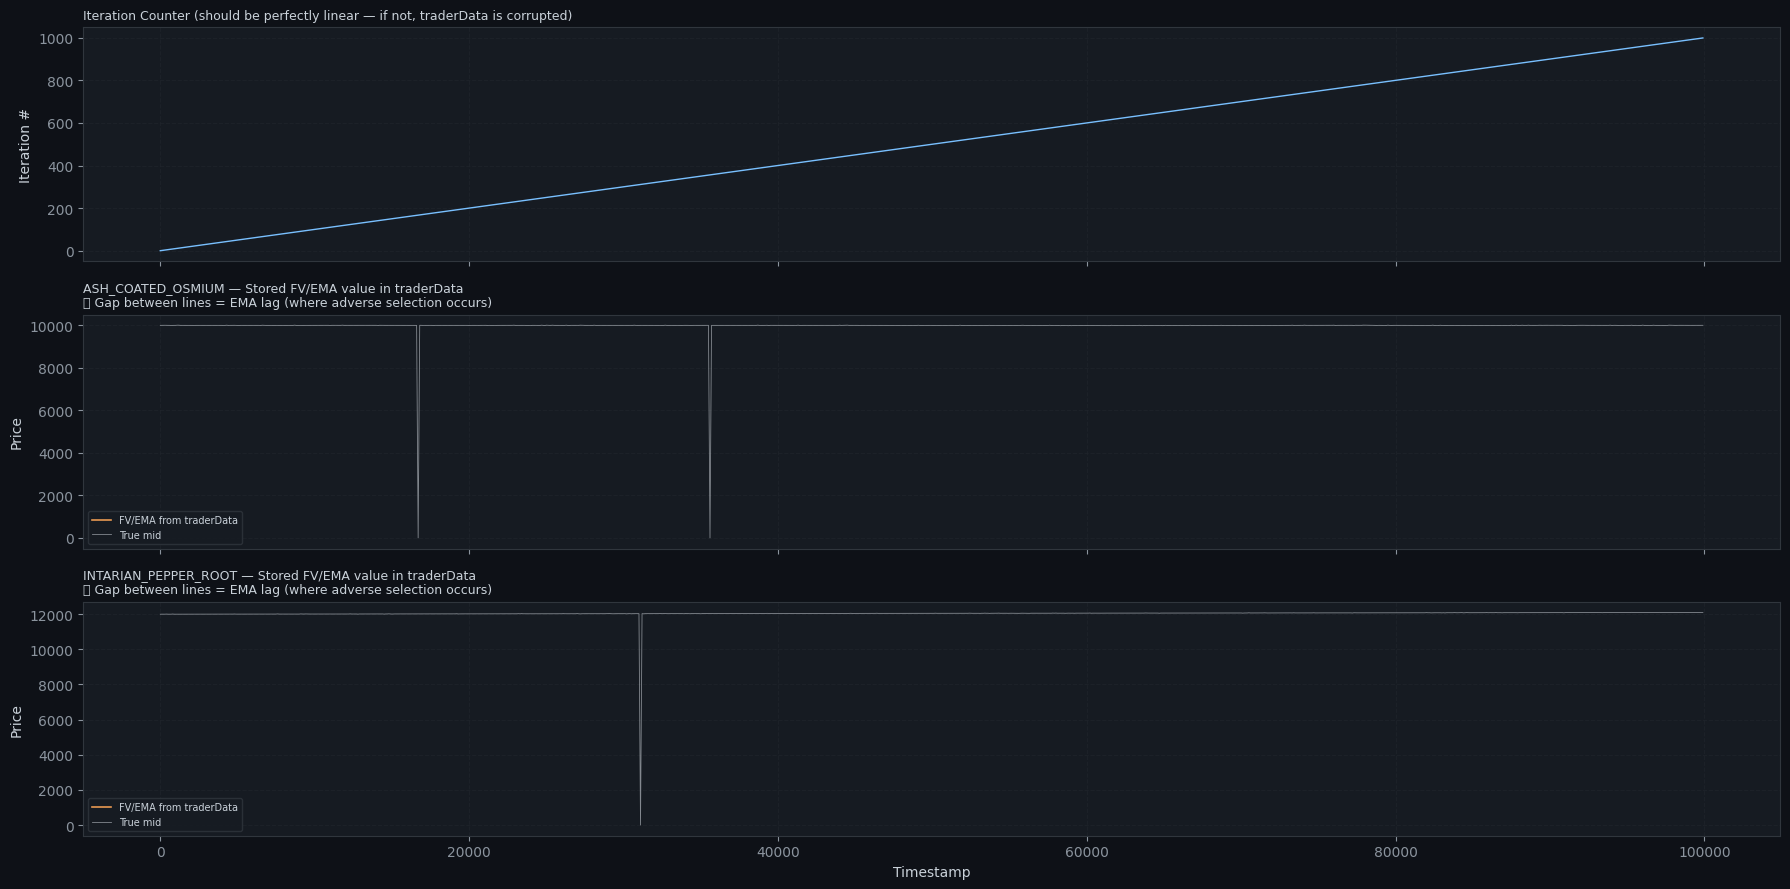


First 5 traderData snapshots:
    ts  ASH_COATED_OSMIUM_fv  ASH_COATED_OSMIUM_pos  ASH_COATED_OSMIUM_bid  ASH_COATED_OSMIUM_ask  ASH_COATED_OSMIUM_size  ASH_COATED_OSMIUM_skew  INTARIAN_PEPPER_ROOT_fv  INTARIAN_PEPPER_ROOT_pos  INTARIAN_PEPPER_ROOT_bid  INTARIAN_PEPPER_ROOT_ask  INTARIAN_PEPPER_ROOT_size  INTARIAN_PEPPER_ROOT_skew
0    0                   NaN                    NaN                    NaN                    NaN                     NaN                     NaN                      NaN                       NaN                       NaN                       NaN                        NaN                        NaN
1  100                   NaN                    NaN                    NaN                    NaN                     NaN                     NaN                      NaN                       NaN                       NaN                       NaN                        NaN                        NaN
2  200                   NaN                    NaN         

In [105]:

print('TraderData State Evolution\n')
print('This shows how your algorithm\'s internal state changes over time.\n')
 
if not parsed_logs.empty:
    # Show key state variables over time
    fig, axes = plt.subplots(len(products) + 1, 1,
                              figsize=(18, 3 * (len(products) + 1)),
                              sharex=True)
 
    # Iteration counter
    if 'ts' in parsed_logs.columns:
        axes[0].plot(parsed_logs['ts'],
                     range(len(parsed_logs)), color='#79c0ff', lw=1)
        axes[0].set_ylabel('Iteration #')
        axes[0].set_title('Iteration Counter (should be perfectly linear — if not, traderData is corrupted)',
                          fontsize=9, loc='left')
        axes[0].grid(True)
 
    # FV / EMA per product
    for i, p in enumerate(products):
        ax      = axes[i + 1]
        fv_col  = f'{p}_fv'
        if fv_col in parsed_logs.columns:
            ax.plot(parsed_logs['ts'], parsed_logs[fv_col], color=C['ema'],
                    lw=1.2, label='FV/EMA from traderData', alpha=0.9)
            # Overlay true mid
            df2 = mkt[p].set_index('timestamp')['mid_price']
            ax.plot(mkt[p]['timestamp'], mkt[p]['mid_price'], color=C['mid'],
                    lw=0.6, alpha=0.5, label='True mid')
            ax.set_title(f'{p} — Stored FV/EMA value in traderData\n'
                         f'🔍 Gap between lines = EMA lag (where adverse selection occurs)',
                         fontsize=9, loc='left')
            ax.legend(fontsize=7)
            ax.grid(True)
            ax.set_ylabel('Price')
 
    axes[-1].set_xlabel('Timestamp')
    plt.tight_layout()
    plt.show()
 
    # Also show first few state snapshots as a table
    print('\nFirst 5 traderData snapshots:')
    print(parsed_logs.head().to_string())
    print('\nLast 5 traderData snapshots:')
    print(parsed_logs.tail().to_string())
else:
    print('No parsed trader state available. Ensure your algorithm prints:')
    print('  print(f"  PRODUCT | FV={fv} pos={pos} bid={bid} ask={ask} size={size}")')
    print('The log parser uses these print statements to reconstruct state.')

## Market Trades Analysis (non-our trades / other participants)


Market trades = all trades NOT involving SUBMISSION. These are:
  • Bot vs Bot trades (rare)
  • Other participant teams trading against bots
 
Analysing non-SUBMISSION trades helps you:
  - Identify when other teams are aggressively taking bot quotes
    (signals that the bot quote has strong edge — you should too)
  - Find the most active price levels (confirms your quote placement)
  - Detect if bots are crossing each other (unusual, signals mispricing)
 
From top participants:
  "Study bot behaviors — if a specific trader ID is consistently profitable,
   consider mirroring their strategy"

═══ Market Trades Analysis (non-SUBMISSION) ═══

Total market trades: 33


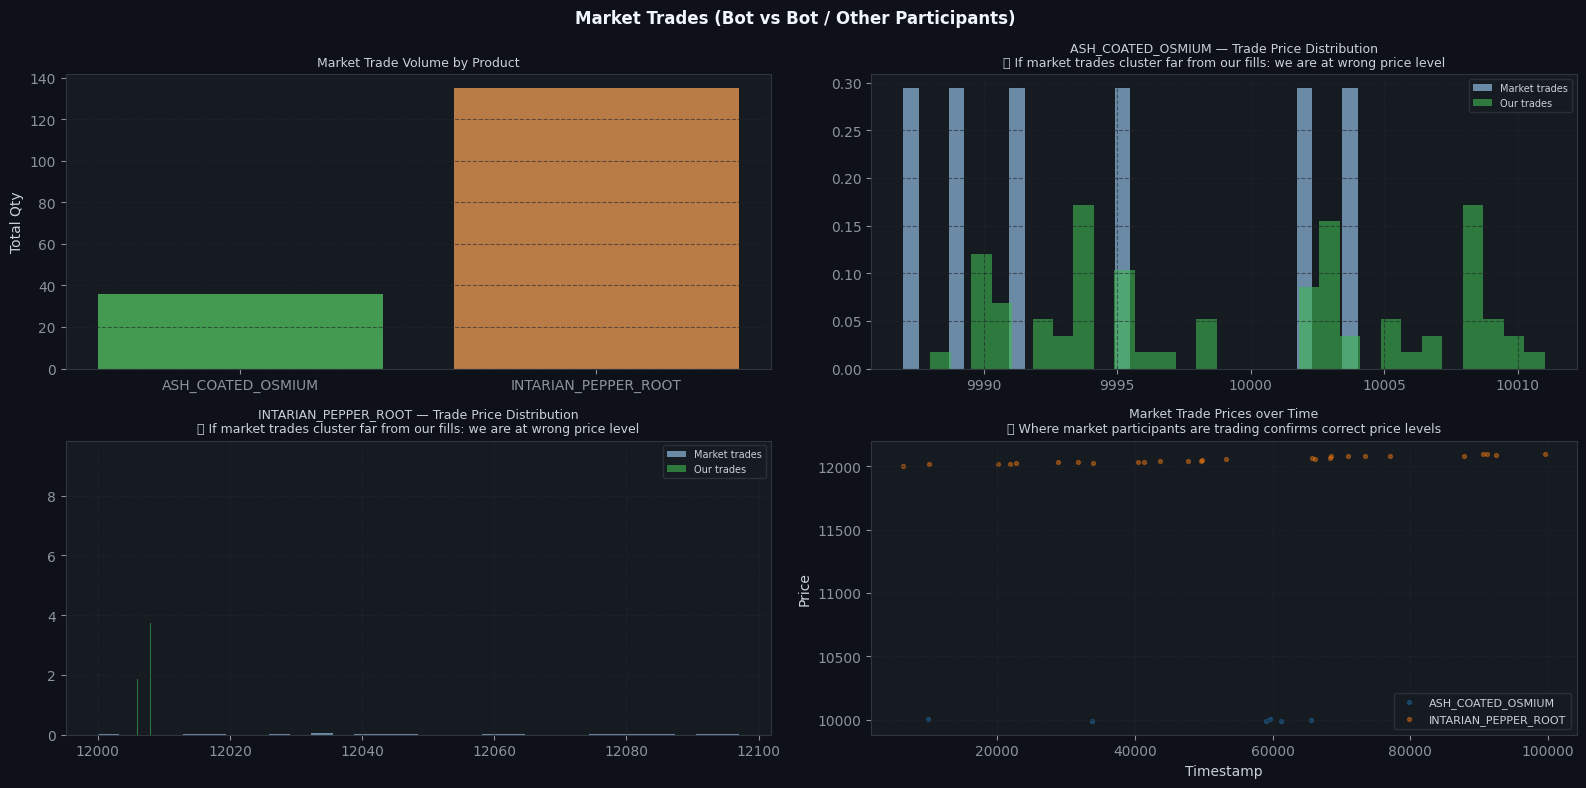


Buyer identity distribution:
buyer
    33

Seller identity distribution:
seller
    33

🔍 Recurring non-SUBMISSION IDs = specific bots. If they trade at consistent
   prices, you can exploit their predictable quoting pattern.


In [106]:

print('═══ Market Trades Analysis (non-SUBMISSION) ═══\n')
 
if not trades.empty:
    market_trades = trades[~trades['is_our_trade']].copy()
 
    if market_trades.empty:
        print('No market trades found (all trades in this log involve SUBMISSION)')
    else:
        print(f'Total market trades: {len(market_trades)}')
 
        fig, axes = plt.subplots(2, 2, figsize=(16, 8))
        fig.suptitle('Market Trades (Bot vs Bot / Other Participants)',
                     color='#f0f6fc', fontsize=12, fontweight='bold')
 
        # Volume by product
        vol_by_prod = market_trades.groupby('symbol')['quantity'].sum()
        axes[0,0].bar(vol_by_prod.index, vol_by_prod.values,
                      color=['#56d364', '#ffa657', '#f85149'][:len(vol_by_prod)], alpha=0.7)
        axes[0,0].set_title('Market Trade Volume by Product', fontsize=9)
        axes[0,0].set_ylabel('Total Qty')
        axes[0,0].grid(True, axis='y')
 
        # Price distribution of market trades vs our trades
        for p in products:
            mt_p  = market_trades[market_trades['symbol'] == p]
            our_p = our_trades[our_trades['symbol'] == p] if not our_trades.empty else pd.DataFrame()
            ax    = axes[0,1] if p == products[0] else axes[1,0]
 
            if not mt_p.empty:
                ax.hist(mt_p['price'], bins=30, color='#a5d6ff', alpha=0.6,
                        label='Market trades', density=True)
            if not our_p.empty:
                ax.hist(our_p['price'], bins=30, color=C['pnl'], alpha=0.6,
                        label='Our trades', density=True)
            ax.set_title(f'{p} — Trade Price Distribution\n'
                         f'🔍 If market trades cluster far from our fills: we are at wrong price level',
                         fontsize=9)
            ax.legend(fontsize=7)
            ax.grid(True)
 
        # Market trade frequency over time
        ax = axes[1,1]
        for p in products:
            mt_p = market_trades[market_trades['symbol'] == p]
            if not mt_p.empty:
                # Rolling count per timestamp window
                mt_p_sorted = mt_p.sort_values('timestamp')
                ax.scatter(mt_p_sorted['timestamp'], mt_p_sorted['price'],
                           s=8, alpha=0.4, label=p)
        ax.set_title('Market Trade Prices over Time\n'
                     '🔍 Where market participants are trading confirms correct price levels',
                     fontsize=9)
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Price')
        ax.legend(fontsize=8)
        ax.grid(True)
 
        plt.tight_layout()
        plt.show()
 
        # Buyer/seller identity analysis
        print('\nBuyer identity distribution:')
        print(market_trades['buyer'].value_counts().head(10).to_string())
        print('\nSeller identity distribution:')
        print(market_trades['seller'].value_counts().head(10).to_string())
        print('\n🔍 Recurring non-SUBMISSION IDs = specific bots. If they trade at consistent')
        print('   prices, you can exploit their predictable quoting pattern.')
else:
    print('No trade history available in this log file.')


### SUMMARY: What each cell added vs the visualiser till now

| Cell   | Feature Description                                                                 |
|--------|--------------------------------------------------------------------------------------|
| Cell A | Candlestick chart (OHLC from ticks, volume bars, configurable)                      |
| Cell B | Positions as % of limit (matches visualiser exactly)                                |
| Cell C | Filled vs Unfilled order markers (key fill-rate diagnostic)                         |
| Cell D | Timestamp inspector (order depth, logs, trades at any tick)                         |
| Cell E | Algorithm logs viewer (lambdaLog timeline, paginated)                               |
| Cell F | TraderData state evolution (EMA convergence, iteration tracking)                    |
| Cell G | Market trades analysis (bot activity, other participant behavior)   |


## Leaderboard-Style Performance Metrics


The leaderboard shows 5 critical metrics per strategy:
  1. Total PnL        — raw profit. Important but not sufficient.
  2. Max Drawdown     — largest peak-to-trough drop in cumulative PnL.
                        Smaller = more consistent, less blow-up risk.
  3. Recovery ratio   — Total PnL / Max Drawdown. Higher = better
                        risk-adjusted return. Top strategies have 5-13x.
  4. Avg Fill         — average quantity per fill. Larger = fewer fills
                        but more volume per fill (often better MM strategies).
  5. Percentile       — rank vs all verified entries.

HOW TO USE THESE TO IMPROVE YOUR ALGORITHM:
  - If Max Drawdown is > 30% of Total PnL → large inventory risk periods.
    Fix: increase skew factor, widen edge during high-vol periods.
  - Recovery < 3.0 → strategy is erratic. Aim for 5-10 like top performers.
  - Avg Fill < 3 → you're getting many tiny fills (noisy, high fee environment).
    Fix: increase quote size or reduce passive edge slightly.
  - Avg Fill > 20 → getting swept in large chunks, possibly adverse selection.
    Fix: reduce max_per_level in aggressive sweep.

In [107]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json

# Assume mkt, our_trades, products, get_limit, C are defined from earlier cells


def compute_leaderboard_metrics(verbose=True):
    """Compute all leaderboard metrics and return as a dict."""
    metrics = {}

    # ── Build combined PnL series (all products summed at each timestamp) ─────
    all_ts  = sorted(market['timestamp'].unique())
    pnl_df  = pd.DataFrame({'timestamp': all_ts})
    for p in products:
        df_p = mkt[p].set_index('timestamp')['profit_and_loss']
        pnl_df[p] = pnl_df['timestamp'].map(df_p).fillna(method='ffill').fillna(0)
    pnl_df['total'] = pnl_df[products].sum(axis=1)

    total_pnl  = pnl_df['total'].iloc[-1]
    pnl_series = pnl_df['total'].values

    # ── Max Drawdown (peak-to-trough) ─────────────────────────────────────────
    running_max = np.maximum.accumulate(pnl_series)
    drawdowns   = running_max - pnl_series
    max_dd      = drawdowns.max()
    max_dd_idx  = drawdowns.argmax()
    peak_idx    = pnl_series[:max_dd_idx].argmax() if max_dd_idx > 0 else 0

    # Recovery: where does PnL first recover above the pre-drawdown peak?
    peak_val = pnl_series[peak_idx]
    recovery_ts = None
    for j in range(max_dd_idx, len(pnl_series)):
        if pnl_series[j] >= peak_val:
            recovery_ts = all_ts[j]
            break
    drawdown_ts = all_ts[max_dd_idx]
    peak_ts     = all_ts[peak_idx]

    # ── Recovery ratio ────────────────────────────────────────────────────────
    recovery_ratio = total_pnl / (max_dd + 1e-9)

    # ── Avg Fill size ─────────────────────────────────────────────────────────
    avg_fill = our_trades['quantity'].mean() if not our_trades.empty else 0

    # ── Per-product breakdown ─────────────────────────────────────────────────
    per_prod = {}
    for p in products:
        pp_pnl   = pnl_df[p].iloc[-1]
        pp_arr   = pnl_df[p].values
        pp_rm    = np.maximum.accumulate(pp_arr)
        pp_dd    = (pp_rm - pp_arr).max()
        pp_fills = our_trades[our_trades['symbol']==p]['quantity'] if not our_trades.empty else pd.Series()
        per_prod[p] = {
            'pnl'       : pp_pnl,
            'max_dd'    : pp_dd,
            'recovery'  : pp_pnl / (pp_dd + 1e-9),
            'fills'     : len(pp_fills),
            'avg_fill'  : pp_fills.mean() if len(pp_fills) > 0 else 0,
            'pnl_pct'   : 100 * pp_pnl / (total_pnl + 1e-9),
        }

    metrics = {
        'total_pnl'      : total_pnl,
        'max_drawdown'   : max_dd,
        'recovery_ratio' : recovery_ratio,
        'avg_fill'       : avg_fill,
        'total_fills'    : len(our_trades) if not our_trades.empty else 0,
        'peak_ts'        : peak_ts,
        'trough_ts'      : drawdown_ts,
        'recovery_ts'    : recovery_ts,
        'pnl_series'     : pnl_series,
        'drawdown_series': drawdowns,
        'timestamps'     : all_ts,
        'per_product'    : per_prod,
        'pnl_df'         : pnl_df,
    }

    if verbose:
        print('╔══════════════════════════════════════════════════════════════╗')
        print('║              LEADERBOARD METRICS (Your Strategy)             ║')
        print('╠══════════════════════════════════════════════════════════════╣')
        print(f'║  Total PnL      : {total_pnl:>10.3f} XIRECs               ║')
        print(f'║  Max Drawdown   : {max_dd:>10.3f}                            ║')
        print(f'║  Recovery Ratio : {recovery_ratio:>10.2f}x  (top players: 7-13x)  ║')
        print(f'║  Avg Fill Size  : {avg_fill:>10.2f}  (top players: 4-6)      ║')
        print(f'║  Total Fills    : {metrics["total_fills"]:>10d}                         ║')
        print('╠══════════════════════════════════════════════════════════════╣')

        print('║  Per-Product Breakdown:                                      ║')
        for p, m in per_prod.items():
            print(f'║  {p:<10}: PnL={m["pnl"]:>8.1f}  DD={m["max_dd"]:>7.1f}  '
                  f'Rec={m["recovery"]:>5.1f}x  Fills={m["fills"]:>4d}  '
                  f'AvgQ={m["avg_fill"]:>4.1f}  ║')

        print('╠══════════════════════════════════════════════════════════════╣')

        # Diagnosis
        print('║  DIAGNOSIS:                                                  ║')
        if recovery_ratio < 3:
            print('║  ⚠  Recovery < 3x: strategy is erratic/risky.               ║')
            print('║     → Increase skew_factor; add vol-gating on quote size    ║')
        elif recovery_ratio < 7:
            print('║  ⚡ Recovery 3-7x: decent but below top performers (7-13x)  ║')
            print('║     → Focus on drawdown reduction, not just PnL growth      ║')
        else:
            print('║  ✅ Recovery > 7x: excellent risk-adjusted performance!      ║')

        if avg_fill < 3:
            print('║  ⚠  Avg fill < 3: too many micro-fills or low volume.       ║')
            print('║     → Increase quote_size or reduce passive_edge by 1 tick  ║')
        elif avg_fill > 15:
            print('║  ⚠  Avg fill > 15: getting swept in large chunks.           ║')
            print('║     → Reduce max_per_level in aggressive_sweep              ║')
        else:
            print('║  ✅ Avg fill in healthy range (3-15)                         ║')

        for p, m in per_prod.items():
            if m['pnl'] < 0:
                print(f'║  ❌ {p} is LOSING money ({m["pnl"]:.1f}). Disable or fix it!     ║')
            elif m['pnl_pct'] < 10 and m['fills'] > 10:
                print(f'║  ⚠  {p} contributes only {m["pnl_pct"]:.0f}% of PnL despite many fills ║')

        print('╚══════════════════════════════════════════════════════════════╝')

    return metrics


METRICS = compute_leaderboard_metrics()

╔══════════════════════════════════════════════════════════════╗
║              LEADERBOARD METRICS (Your Strategy)             ║
╠══════════════════════════════════════════════════════════════╣
║  Total PnL      :  10206.750 XIRECs               ║
║  Max Drawdown   :    379.514                            ║
║  Recovery Ratio :      26.89x  (top players: 7-13x)  ║
║  Avg Fill Size  :       6.43  (top players: 4-6)      ║
║  Total Fills    :         84                         ║
╠══════════════════════════════════════════════════════════════╣
║  Per-Product Breakdown:                                      ║
║  ASH_COATED_OSMIUM: PnL=  2775.8  DD=  120.2  Rec= 23.1x  Fills=  76  AvgQ= 6.1  ║
║  INTARIAN_PEPPER_ROOT: PnL=  7431.0  DD=  401.0  Rec= 18.5x  Fills=   8  AvgQ=10.0  ║
╠══════════════════════════════════════════════════════════════╣
║  DIAGNOSIS:                                                  ║
║  ✅ Recovery > 7x: excellent risk-adjusted performance!      ║
║  ✅ Avg fill in healt


## Max Drawdown Deep Dive + Recovery Analysis


Drawdown analysis is the single most important metric beyond raw PnL because it
tells you WHERE the strategy fails and HOW LONG recovery takes.

What to look for:
  - One large drawdown spike early, then clean → warm-up period (EMA cold start)
  - Many small drawdowns scattered → position risk (need more skew)
  - Single catastrophic drawdown at specific timestamp → investigate that tick
  - Drawdown during TOMATOES downtrend = you held longs while price fell
  - Long recovery time (many ticks) = strategy struggles after adverse selection

Top strategy (Rank 1): Max DD = 687 on PnL 5235 → recovery = 7.6x
vs typical beginner: recovery = 1-3x (huge swings vs small profit)

To reduce drawdown:
  1. Widen passive edge when rolling vol is high (already in v4)
  2. Hard-stop inventory: if position > 0.6 * limit AND recent_pnl_change < -threshold:
     aggressively liquidate at market (don't wait for passive fills)
  3. Per-product drawdown limit: if product PnL drawdown > X, stop quoting that product

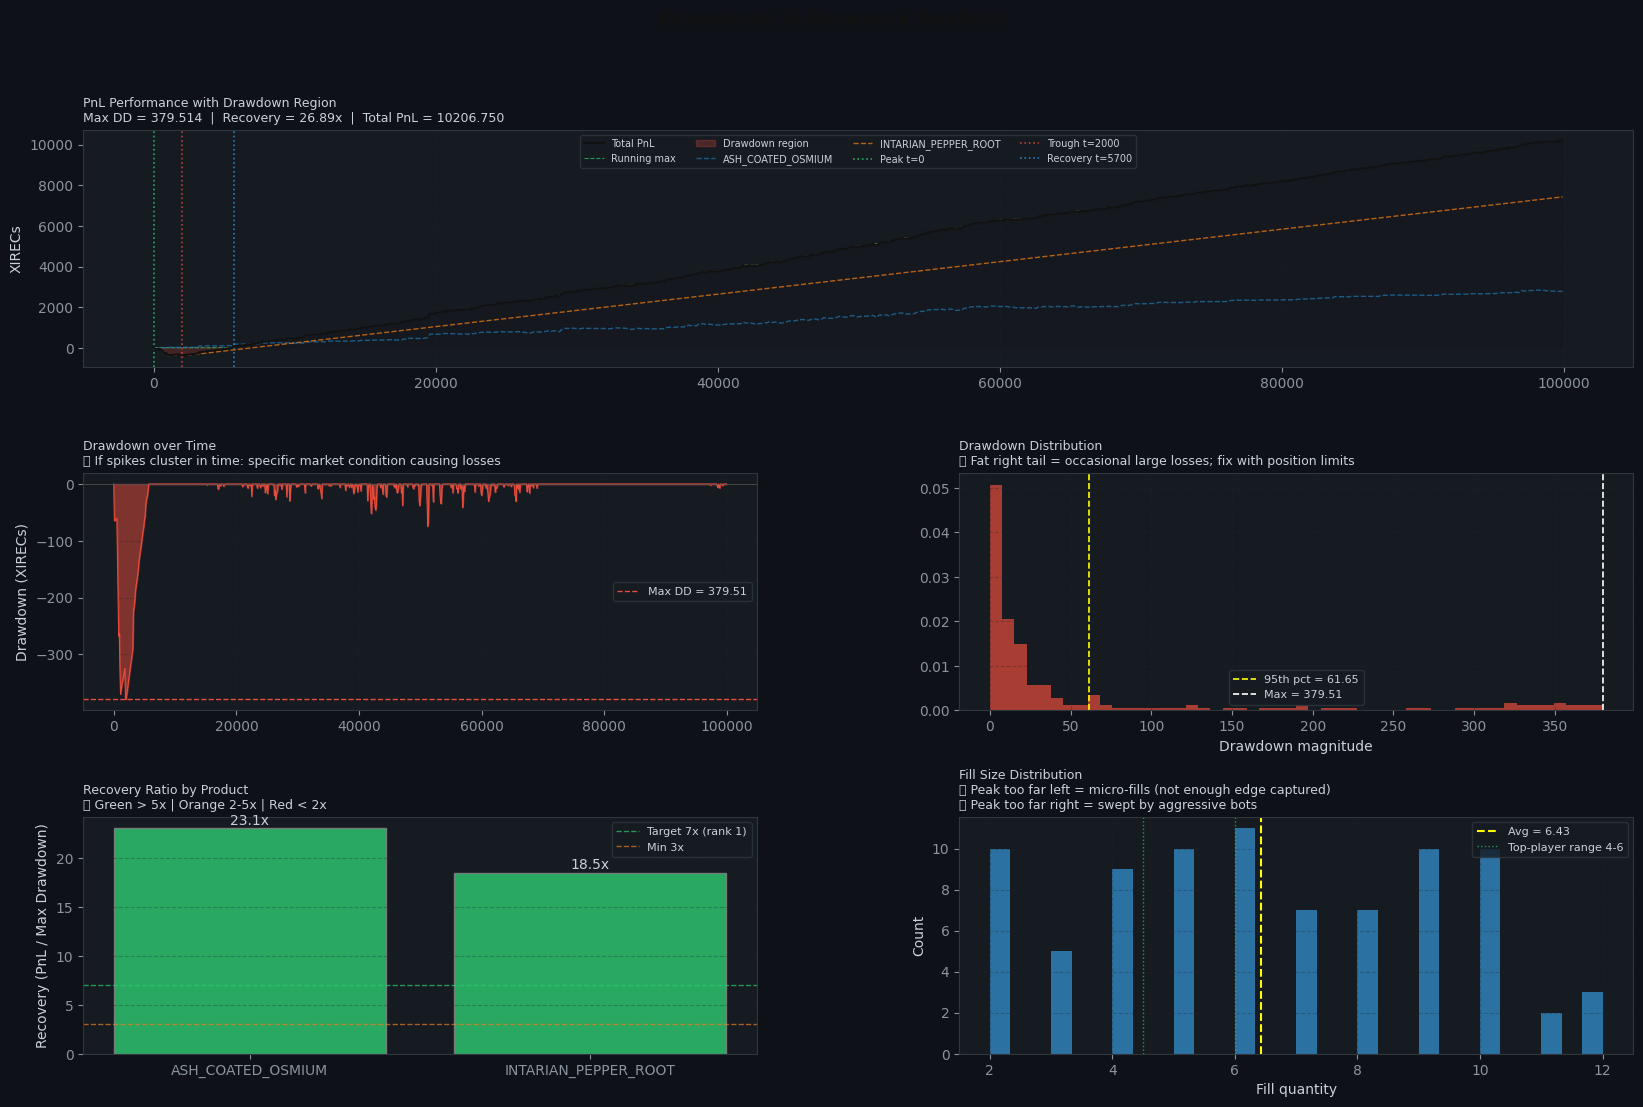


🔍 Drawdown Interpretation Guide:
  Max Drawdown        : 379.514
  As % of Total PnL   : 3.7%
  Recovery duration   : 37 ticks after trough


In [108]:
m = METRICS

fig = plt.figure(figsize=(20, 12))
fig.suptitle('Drawdown & Recovery Analysis', color='#111', fontsize=14, fontweight='bold')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])  # Full-width PnL + shading

# PnL with drawdown shading (Image 3 style)
ts_arr  = np.array(m['timestamps'])
pnl_arr = m['pnl_series']
dd_arr  = m['drawdown_series']
rm_arr  = np.maximum.accumulate(pnl_arr)

ax1.plot(ts_arr, pnl_arr, color='#111', lw=1.5, label='Total PnL', zorder=3)
ax1.fill_between(ts_arr, pnl_arr, alpha=0.12, color='#111', zorder=2)
ax1.plot(ts_arr, rm_arr,  color='#2ecc71', lw=0.8, linestyle='--', alpha=0.7, label='Running max')

# Shade drawdown in red
ax1.fill_between(ts_arr, rm_arr, pnl_arr, where=pnl_arr < rm_arr,
                  alpha=0.25, color='#e74c3c', label='Drawdown region', zorder=1)

# Per-product lines
for p in products:
    ax1.plot(m['pnl_df']['timestamp'], m['pnl_df'][p],
             lw=1.0, linestyle='--', alpha=0.7, label=p)

# Mark peak and trough
ax1.axvline(m['peak_ts'],   color='#2ecc71', lw=1.2, linestyle=':', alpha=0.8, label=f'Peak t={m["peak_ts"]}')
ax1.axvline(m['trough_ts'], color='#e74c3c', lw=1.2, linestyle=':', alpha=0.8, label=f'Trough t={m["trough_ts"]}')
if m['recovery_ts']:
    ax1.axvline(m['recovery_ts'], color='#3498db', lw=1.2, linestyle=':', alpha=0.8,
                label=f'Recovery t={m["recovery_ts"]}')

ax1.set_title('PnL Performance with Drawdown Region\n'
              f'Max DD = {m["max_drawdown"]:.3f}  |  Recovery = {m["recovery_ratio"]:.2f}x  |  '
              f'Total PnL = {m["total_pnl"]:.3f}',
              fontsize=9, loc='left')
ax1.legend(fontsize=7, ncol=4)
ax1.grid(True, alpha=0.3)
ax1.set_ylabel('XIRECs')

# ── Drawdown time series ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.fill_between(ts_arr, 0, -dd_arr, alpha=0.5, color='#e74c3c')
ax2.plot(ts_arr, -dd_arr, color='#e74c3c', lw=0.8)
ax2.axhline(0, color='#555', lw=0.5)
ax2.axhline(-m['max_drawdown'], color='#e74c3c', lw=1.0, linestyle='--',
             label=f'Max DD = {m["max_drawdown"]:.2f}')
ax2.set_title('Drawdown over Time\n🔍 If spikes cluster in time: specific market condition causing losses',
              fontsize=9, loc='left')
ax2.legend(fontsize=8)
ax2.set_ylabel('Drawdown (XIRECs)')
ax2.grid(True, alpha=0.3)

# ── Drawdown distribution ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(dd_arr[dd_arr > 0.01], bins=50, color='#e74c3c', alpha=0.7, density=True)
pct_95 = np.percentile(dd_arr, 95)
ax3.axvline(pct_95, color='yellow', lw=1.2, linestyle='--',
             label=f'95th pct = {pct_95:.2f}')
ax3.axvline(m['max_drawdown'], color='white', lw=1.2, linestyle='--',
             label=f'Max = {m["max_drawdown"]:.2f}')
ax3.set_title('Drawdown Distribution\n🔍 Fat right tail = occasional large losses; fix with position limits',
              fontsize=9, loc='left')
ax3.legend(fontsize=8)
ax3.set_xlabel('Drawdown magnitude')
ax3.grid(True, alpha=0.3)

# ── Per-product recovery comparison ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
prod_names = list(m['per_product'].keys())
recoveries = [m['per_product'][p]['recovery'] for p in prod_names]
pnls_pp    = [m['per_product'][p]['pnl']      for p in prod_names]
colors_rr  = ['#2ecc71' if r > 5 else '#e67e22' if r > 2 else '#e74c3c' for r in recoveries]
bars = ax4.bar(prod_names, recoveries, color=colors_rr, alpha=0.8, edgecolor='#888')
for bar, val in zip(bars, recoveries):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.1f}x', ha='center', va='bottom', fontsize=10)
ax4.axhline(7.0, color='#2ecc71', lw=1.0, linestyle='--', alpha=0.7, label='Target 7x (rank 1)')
ax4.axhline(3.0, color='#e67e22', lw=1.0, linestyle='--', alpha=0.7, label='Min 3x')
ax4.set_title('Recovery Ratio by Product\n🔍 Green > 5x | Orange 2-5x | Red < 2x',
              fontsize=9, loc='left')
ax4.legend(fontsize=8)
ax4.set_ylabel('Recovery (PnL / Max Drawdown)')
ax4.grid(True, axis='y', alpha=0.3)

# ── Avg fill + fill distribution ────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
if not our_trades.empty:
    ax5.hist(our_trades['quantity'], bins=30, color='#3498db', alpha=0.7)
    ax5.axvline(m['avg_fill'], color='yellow', lw=1.5, linestyle='--',
                label=f'Avg = {m["avg_fill"]:.2f}')
    ax5.axvline(4.5, color='#2ecc71', lw=1.0, linestyle=':', alpha=0.7,
                label='Top-player range 4-6')
    ax5.axvline(6.0, color='#2ecc71', lw=1.0, linestyle=':', alpha=0.7)
    ax5.set_title('Fill Size Distribution\n'
                  '🔍 Peak too far left = micro-fills (not enough edge captured)\n'
                  '🔍 Peak too far right = swept by aggressive bots',
                  fontsize=9, loc='left')
    ax5.legend(fontsize=8)
    ax5.set_xlabel('Fill quantity')
    ax5.set_ylabel('Count')
    ax5.grid(True, alpha=0.3)
plt.show()

print('\n🔍 Drawdown Interpretation Guide:')
print(f'  Max Drawdown        : {m["max_drawdown"]:.3f}')
print(f'  As % of Total PnL   : {100*m["max_drawdown"]/(m["total_pnl"]+1e-9):.1f}%')
if m["recovery_ts"]:
    recovery_ticks = (m["recovery_ts"] - m["trough_ts"]) / 100
    print(f'  Recovery duration   : {recovery_ticks:.0f} ticks after trough')
    if recovery_ticks > 500:
        print('  ⚠  Slow recovery: strategy gets stuck after adverse fills')
        print('     → Add hard liquidation when drawdown exceeds threshold')
else:
    print('  ❌ Never recovered from max drawdown during this session!')
    print('     → Strategy may have suffered a persistent adverse position')



## Microprice Analysis


Microprice = volume-weighted mid price, also called Wall Mid in our codebase.
Formula: microprice = (ask_px * bid_vol + bid_px * ask_vol) / (bid_vol + ask_vol)

Why it matters:
  - Regular mid = (bid + ask) / 2 — treats both sides equally
  - Microprice weights towards the THINNER side of the book
  - If bid has 30 vol and ask has 5 vol → market is bid-heavy → price likely to go UP
  - Microprice will be ABOVE regular mid → signal to buy or skew quotes up
  - Using microprice as FV is strictly better than arithmetic mid

Microprice vs Mid divergence is a standalone alpha signal:
  - (microprice - mid) > 1 → bid side heavier → expect upward move
  - (microprice - mid) < -1 → ask side heavier → expect downward move

Used by top participants as a real-time directional signal to skew quotes.


ASH_COATED_OSMIUM Microprice Stats:
  Mean divergence    : +0.1297
  Std of divergence  : 1.6715
  Max divergence     : +5.1111
  Predictive IC      : +0.3724
  → Use microprice as FV and add imbalance signal to quote skew!

INTARIAN_PEPPER_ROOT Microprice Stats:
  Mean divergence    : -0.0693
  Std of divergence  : 1.4432
  Max divergence     : +4.1212
  Predictive IC      : +0.4028
  → Use microprice as FV and add imbalance signal to quote skew!


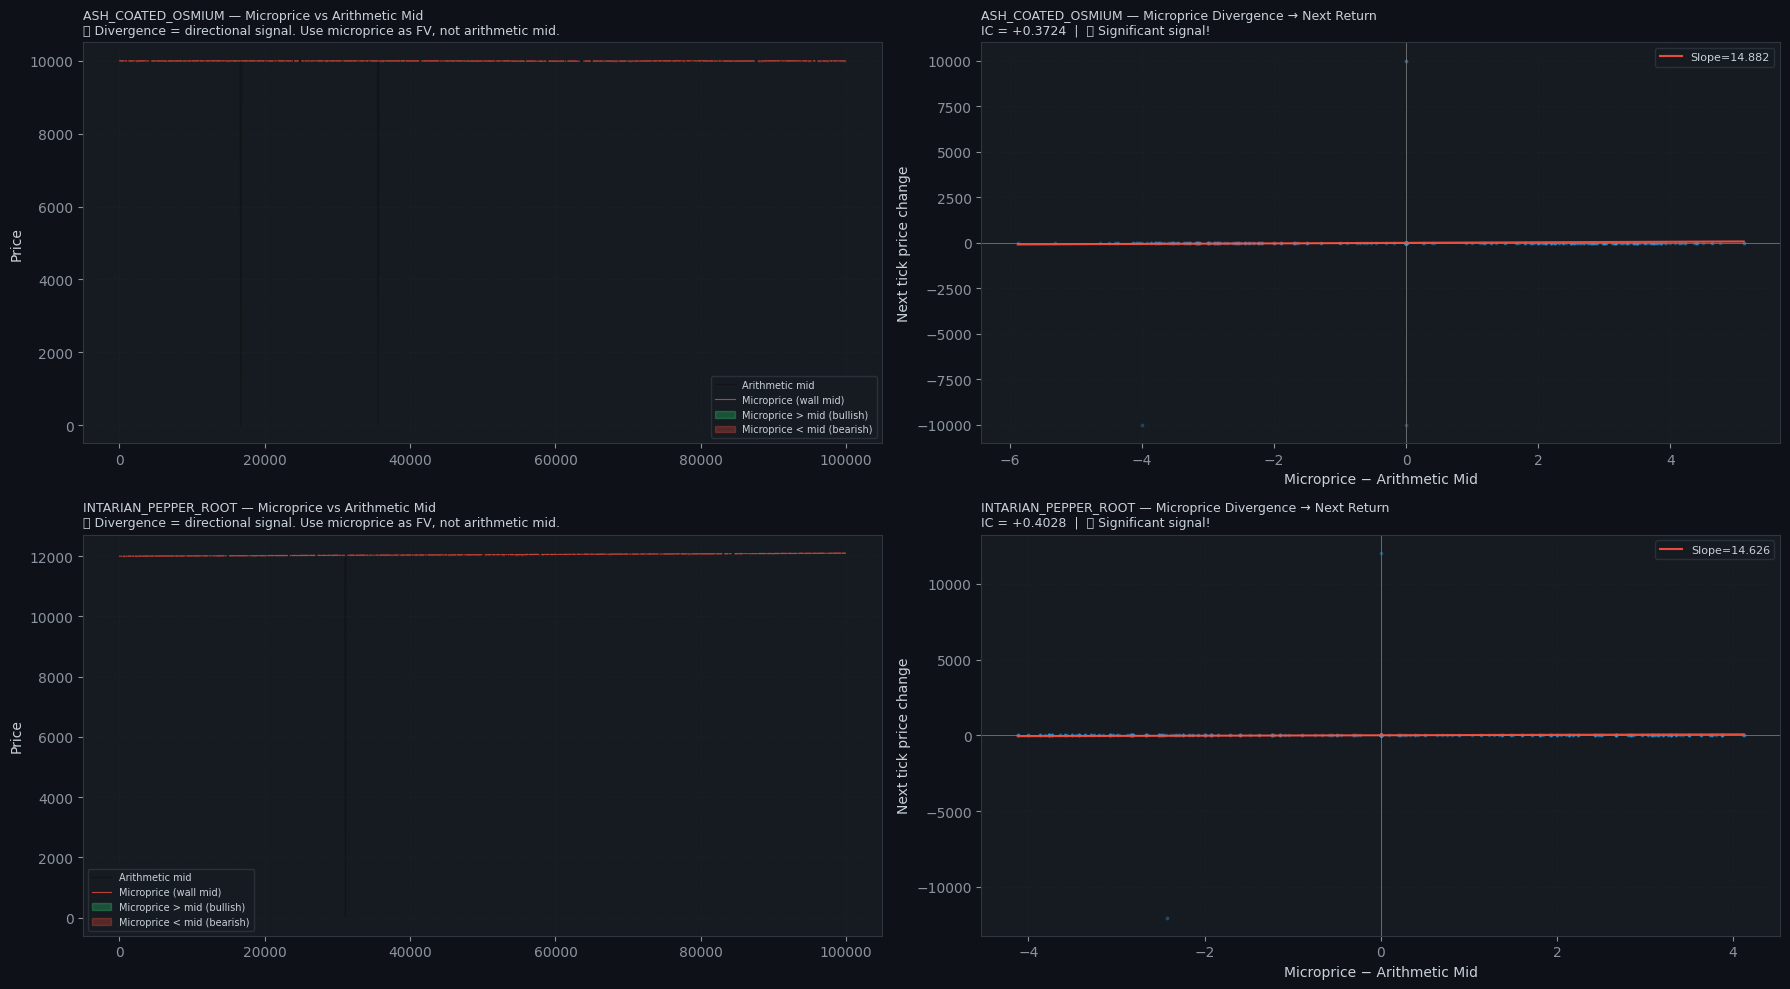

In [109]:
fig, axes = plt.subplots(len(products), 2, figsize=(18, 5*len(products)))
if len(products) == 1:
    axes = [axes]

for i, p in enumerate(products):
    df = mkt[p].copy()
    ax_l, ax_r = axes[i]

    # Microprice over time vs arithmetic mid
    ax_l.plot(df['timestamp'], df['mid_price'], color='#111',
              lw=0.8, alpha=0.7, label='Arithmetic mid', zorder=1)
    ax_l.plot(df['timestamp'], df['wall_mid'],  color='#e74c3c',
              lw=0.8, alpha=0.8, label='Microprice (wall mid)', zorder=2)

    # Divergence fill
    ax_l.fill_between(df['timestamp'],
                      df['mid_price'], df['wall_mid'],
                      where=df['wall_mid'] > df['mid_price'],
                      alpha=0.3, color='#2ecc71', label='Microprice > mid (bullish)')
    ax_l.fill_between(df['timestamp'],
                      df['mid_price'], df['wall_mid'],
                      where=df['wall_mid'] < df['mid_price'],
                      alpha=0.3, color='#e74c3c', label='Microprice < mid (bearish)')

    ax_l.set_title(f'{p} — Microprice vs Arithmetic Mid\n'
                   f'🔍 Divergence = directional signal. Use microprice as FV, not arithmetic mid.',
                   fontsize=9, loc='left')
    ax_l.legend(fontsize=7)
    ax_l.grid(True, alpha=0.3)
    ax_l.set_ylabel('Price')

    # Divergence as standalone signal + next-tick prediction
    div = (df['wall_mid'] - df['mid_price']).fillna(0)
    next_chg = df['mid_chg'].shift(-1)
    ax_r.scatter(div, next_chg, s=3, alpha=0.3, color='#3498db')

    # Regression line
    valid = ~(div.isna() | next_chg.isna())
    if valid.sum() > 20:
        coeffs = np.polyfit(div[valid], next_chg[valid], 1)
        x_line = np.linspace(div[valid].min(), div[valid].max(), 100)
        ax_r.plot(x_line, np.polyval(coeffs, x_line),
                  color='#e74c3c', lw=1.5, label=f'Slope={coeffs[0]:.3f}')
        ic = div[valid].corr(next_chg[valid], method='spearman')
        ax_r.set_title(f'{p} — Microprice Divergence → Next Return\n'
                       f'IC = {ic:+.4f}  |  '
                       f'{"⭐ Significant signal!" if abs(ic)>0.05 else "Weak signal"}',
                       fontsize=9, loc='left')
    ax_r.axhline(0, color='#888', lw=0.5)
    ax_r.axvline(0, color='#888', lw=0.5)
    ax_r.legend(fontsize=8)
    ax_r.set_xlabel('Microprice − Arithmetic Mid')
    ax_r.set_ylabel('Next tick price change')
    ax_r.grid(True, alpha=0.3)

    # Stats
    print(f'\n{p} Microprice Stats:')
    print(f'  Mean divergence    : {div.mean():+.4f}')
    print(f'  Std of divergence  : {div.std():.4f}')
    print(f'  Max divergence     : {div.max():+.4f}')
    print(f'  Predictive IC      : {div[valid].corr(next_chg[valid], method="spearman"):+.4f}')
    if abs(div[valid].corr(next_chg[valid], method='spearman')) > 0.05:
        print(f'  → Use microprice as FV and add imbalance signal to quote skew!')

plt.tight_layout()
plt.show()


## Market Dynamics Panel


The backtester dashboard computes 3 real-time market condition metrics:

1. VOLATILITY (pts) — rolling std of mid price changes.
   Used to dynamically widen passive edge and reduce quote size in fast markets.
   Typical EMERALDS vol = ~0 pts (always stable).
   Typical TOMATOES vol = 1-5 pts (moderate to high).

2. TRADE MOMENTUM (vol) — rolling net signed volume (buy vol - sell vol).
   Positive = market buying pressure → expect price to rise → skew asks higher.
   Negative = market selling pressure → expect price to fall → skew bids lower.
   This is a classic order flow imbalance signal.

3. SPREAD EFFICIENCY (%) = (realized spread capture) / (theoretical max spread).
   How much of the bot spread are you actually capturing?
   Low = quotes too conservative or too aggressive (missing fills).
   High = excellent quote placement.
   Formula: spread_efficiency = (avg_fill_pnl_per_unit / (bot_spread/2)) × 100

These three together form your "market condition dashboard" — use them to gate
your strategy: trade more aggressively when conditions are favourable.


ASH_COATED_OSMIUM Market Dynamics:
  Volatility mean  : 168.268 pts  (95th: 2626.589)
  Momentum mean    : -0.19  (positive=bid heavy)
  Spread efficiency: 0.0%
  ⚠  Low efficiency: our quotes too wide vs bot spread → not getting fills

INTARIAN_PEPPER_ROOT Market Dynamics:
  Volatility mean  : 102.317 pts  (95th: 5.026)
  Momentum mean    : +0.54  (positive=bid heavy)
  Spread efficiency: 0.0%
  ⚠  Low efficiency: our quotes too wide vs bot spread → not getting fills


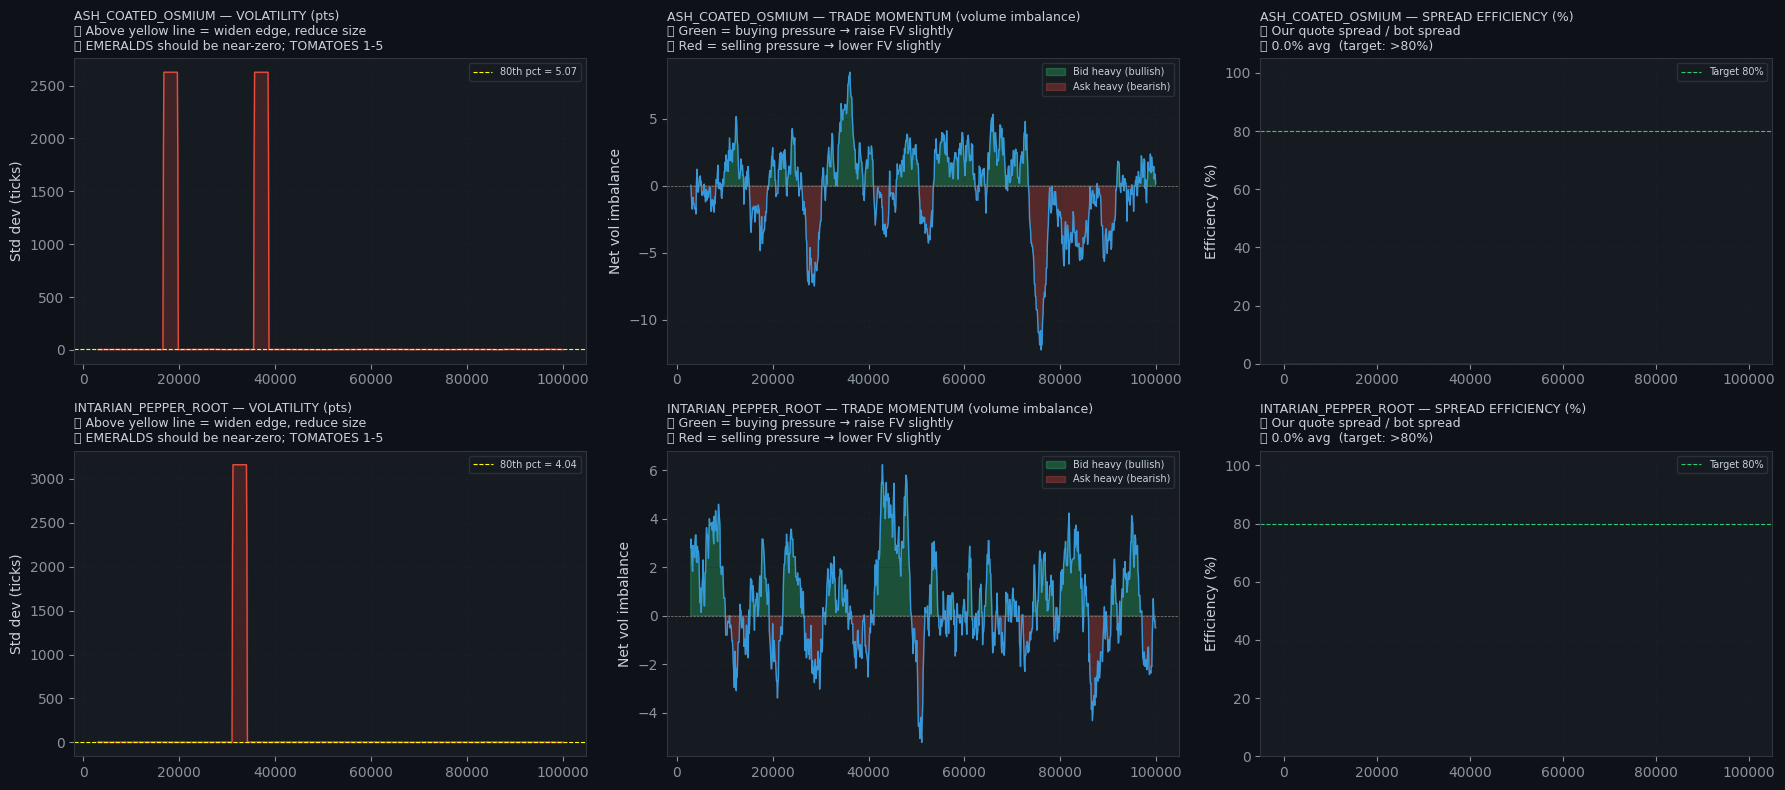

In [110]:
DYNAMICS_WINDOW = 30  # rolling window for all metrics

fig, axes = plt.subplots(len(products), 3, figsize=(18, 4*len(products)))
if len(products) == 1:
    axes = [axes]

for i, p in enumerate(products):
    df = mkt[p].copy()
    ax_v, ax_m, ax_e = axes[i]

    # ── 1. Volatility (rolling std of mid changes) ─────────────────────────
    df['vol_pts'] = df['mid_chg'].rolling(DYNAMICS_WINDOW).std()
    ax_v.plot(df['timestamp'], df['vol_pts'], color='#e74c3c', lw=1.0)
    ax_v.fill_between(df['timestamp'], df['vol_pts'], alpha=0.2, color='#e74c3c')
    # Mark high-vol periods
    high_vol_thresh = df['vol_pts'].quantile(0.80)
    ax_v.axhline(high_vol_thresh, color='yellow', lw=0.8, linestyle='--',
                  label=f'80th pct = {high_vol_thresh:.2f}')
    ax_v.set_title(f'{p} — VOLATILITY (pts)\n'
                   f'🔍 Above yellow line = widen edge, reduce size\n'
                   f'🔍 EMERALDS should be near-zero; TOMATOES 1-5',
                   fontsize=9, loc='left')
    ax_v.legend(fontsize=7)
    ax_v.set_ylabel('Std dev (ticks)')
    ax_v.grid(True, alpha=0.3)

    # ── 2. Trade Momentum (signed volume imbalance) ────────────────────────
    # Use order book imbalance as proxy for signed flow
    df['signed_vol'] = df['bid_depth'] - df['ask_depth']
    df['momentum']   = df['signed_vol'].rolling(DYNAMICS_WINDOW).mean()
    ax_m.plot(df['timestamp'], df['momentum'], color='#3498db', lw=1.0)
    ax_m.fill_between(df['timestamp'], df['momentum'],
                       where=df['momentum'] > 0, alpha=0.3, color='#2ecc71', label='Bid heavy (bullish)')
    ax_m.fill_between(df['timestamp'], df['momentum'],
                       where=df['momentum'] < 0, alpha=0.3, color='#e74c3c', label='Ask heavy (bearish)')
    ax_m.axhline(0, color='#888', lw=0.5, linestyle='--')
    ax_m.set_title(f'{p} — TRADE MOMENTUM (volume imbalance)\n'
                   f'🔍 Green = buying pressure → raise FV slightly\n'
                   f'🔍 Red = selling pressure → lower FV slightly',
                   fontsize=9, loc='left')
    ax_m.legend(fontsize=7)
    ax_m.set_ylabel('Net vol imbalance')
    ax_m.grid(True, alpha=0.3)

    # ── 3. Spread Efficiency ───────────────────────────────────────────────
    # How much of the half-spread are we capturing per fill?
    # Efficiency = (our quote distance from FV) / (bot half-spread) × 100
    bid_col  = f'{p}_bid'
    ask_col  = f'{p}_ask'
    if bid_col in df.columns:
        our_half_spread = ((df[ask_col] - df[bid_col]) / 2).fillna(0)
        bot_half_spread = (df['spread'] / 2).fillna(1)
        spread_eff      = (our_half_spread / bot_half_spread * 100).clip(0, 100)
        df['spread_eff'] = spread_eff
        ax_e.plot(df['timestamp'], spread_eff, color='#9b59b6', lw=0.8)
        ax_e.fill_between(df['timestamp'], spread_eff, alpha=0.2, color='#9b59b6')
        target_eff = 80
        ax_e.axhline(target_eff, color='#2ecc71', lw=0.8, linestyle='--',
                      label=f'Target {target_eff}%')
        ax_e.set_title(f'{p} — SPREAD EFFICIENCY (%)\n'
                       f'🔍 Our quote spread / bot spread\n'
                       f'🔍 {spread_eff.mean():.1f}% avg  (target: >80%)',
                       fontsize=9, loc='left')
        ax_e.legend(fontsize=7)
        ax_e.set_ylabel('Efficiency (%)')
        ax_e.set_ylim(0, 105)
        ax_e.grid(True, alpha=0.3)
    else:
        ax_e.text(0.5, 0.5, 'No quote log data', ha='center', va='center',
                  transform=ax_e.transAxes)

    # Print summary
    print(f'\n{p} Market Dynamics:')
    print(f'  Volatility mean  : {df["vol_pts"].mean():.3f} pts  (95th: {df["vol_pts"].quantile(0.95):.3f})')
    print(f'  Momentum mean    : {df["momentum"].mean():+.2f}  (positive=bid heavy)')
    if bid_col in df.columns:
        eff = df['spread_eff'].mean()
        print(f'  Spread efficiency: {eff:.1f}%')
        if eff < 50:
            print(f'  ⚠  Low efficiency: our quotes too wide vs bot spread → not getting fills')
        elif eff > 95:
            print(f'  ⚠  Very high efficiency: our spread almost equals bot spread → risk of crossing')

plt.tight_layout()
plt.show()

## Market Pressure Gauge


The order book widget shows a "Market Pressure" gauge:
  - → Left (green): BIDS HEAVY — more volume on bid side, bullish pressure
  - → Right (red):  ASKS HEAVY — more volume on ask side, bearish pressure

This is computed as: pressure = (bid_vol - ask_vol) / (bid_vol + ask_vol)
Values range from -1 (pure ask-side) to +1 (pure bid-side).

Why this matters for your algorithm:
  - Market pressure > +0.3 → smart money is bidding hard → you should too
    Action: reduce ask size slightly, increase bid size to capture the flow
  - Market pressure < -0.3 → heavy offer pressure → you should lean short
    Action: reduce bid size, increase ask size
  - Pressure oscillates around 0 → balanced book → pure MM is optimal

This is the same signal as order imbalance (Section 8) but visualised as a
real-time gauge. Top teams incorporate this into their dynamic skew formula:
  skew = base_skew + pressure_skew_adjustment


ASH_COATED_OSMIUM Market Pressure:
  Mean pressure: -0.006
  Predictive IC: +0.0041
  Bid heavy (>0.2): 21.3% of ticks
  Ask heavy (<-0.2): 21.2% of ticks

INTARIAN_PEPPER_ROOT Market Pressure:
  Mean pressure: +0.015
  Predictive IC: +0.0408
  Bid heavy (>0.2): 21.5% of ticks
  Ask heavy (<-0.2): 19.4% of ticks


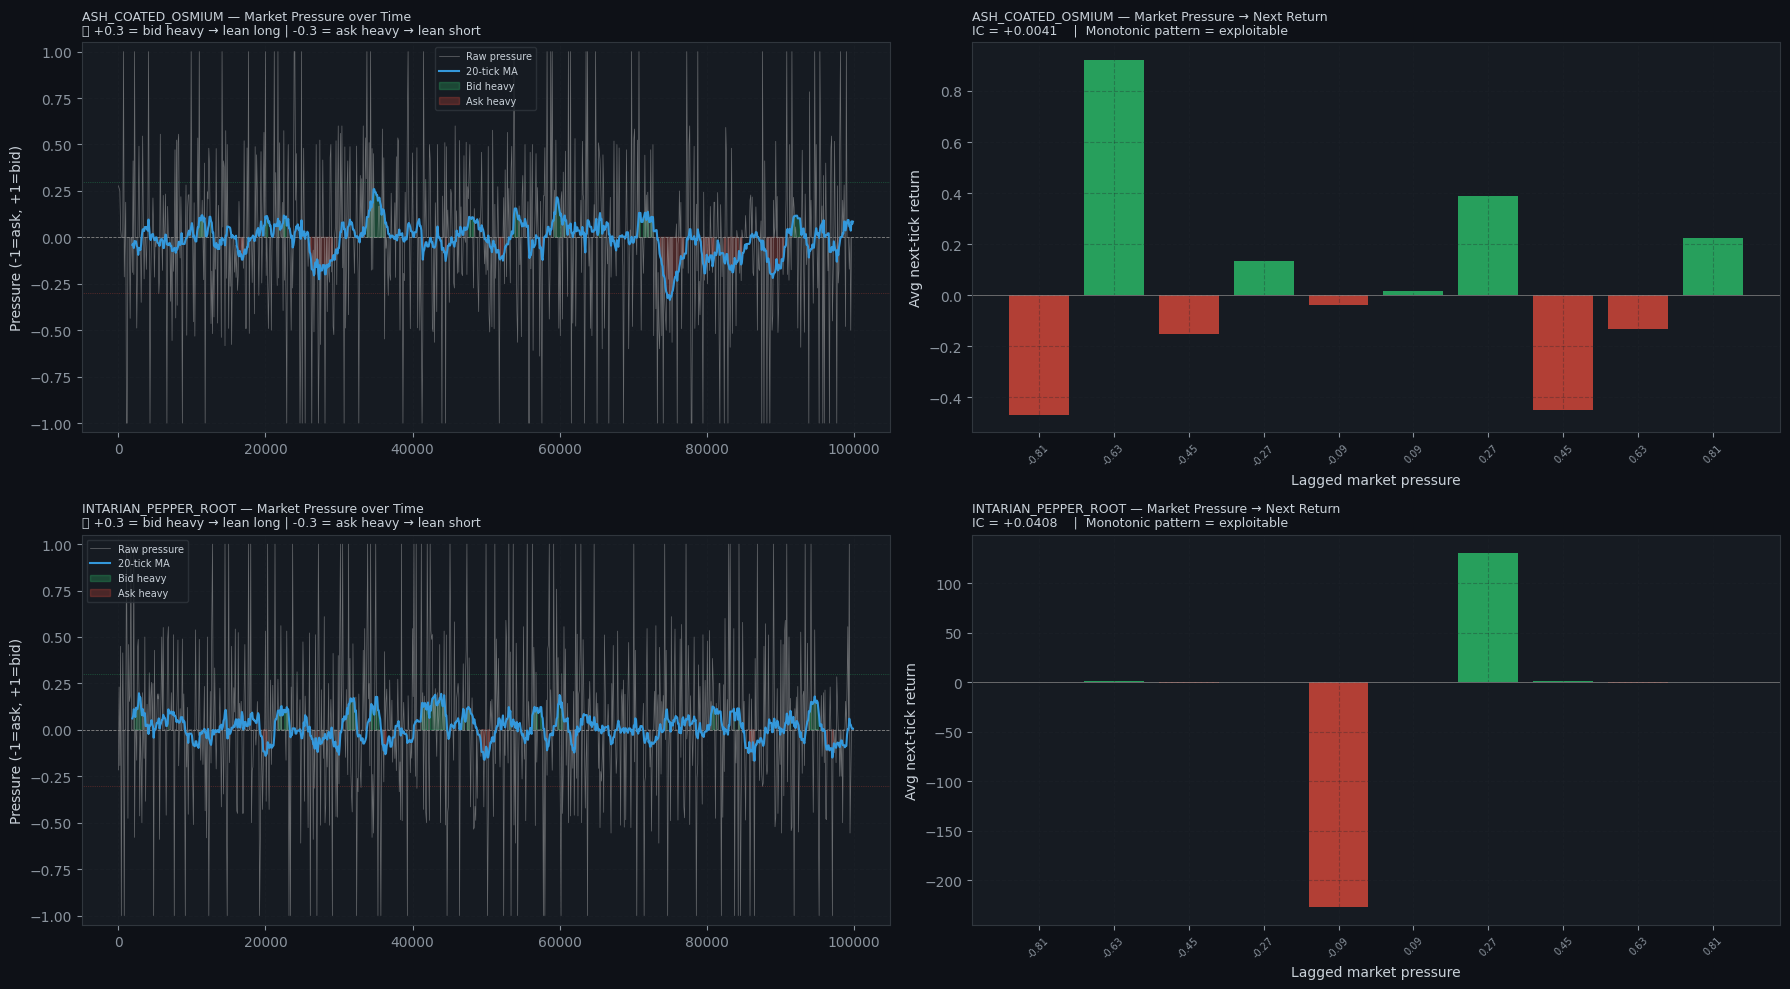

In [111]:
fig, axes = plt.subplots(len(products), 2, figsize=(18, 5*len(products)))
if len(products) == 1:
    axes = [axes]

for i, p in enumerate(products):
    df = mkt[p].copy()
    ax_l, ax_r = axes[i]

    # ── Pressure time series ───────────────────────────────────────────────
    pressure = df['imbalance']  # (bid_depth - ask_depth) / total
    roll_p   = pressure.rolling(20).mean()

    ax_l.plot(df['timestamp'], pressure, color='#bbb', lw=0.5, alpha=0.5, label='Raw pressure')
    ax_l.plot(df['timestamp'], roll_p, lw=1.5, label='20-tick MA', zorder=3,
              color=[C['trade_buy'] if v > 0 else C['trade_sell'] for v in roll_p.fillna(0)].__class__.__name__
              and '#3498db')

    ax_l.fill_between(df['timestamp'], roll_p,
                       where=roll_p > 0.1, alpha=0.25, color='#2ecc71', label='Bid heavy')
    ax_l.fill_between(df['timestamp'], roll_p,
                       where=roll_p < -0.1, alpha=0.25, color='#e74c3c', label='Ask heavy')
    ax_l.axhline(0,    color='#888', lw=0.6, linestyle='--')
    ax_l.axhline( 0.3, color='#2ecc71', lw=0.5, linestyle=':', alpha=0.5)
    ax_l.axhline(-0.3, color='#e74c3c', lw=0.5, linestyle=':', alpha=0.5)
    ax_l.set_ylim(-1.05, 1.05)
    ax_l.set_title(f'{p} — Market Pressure over Time\n'
                   f'🔍 +0.3 = bid heavy → lean long | -0.3 = ask heavy → lean short',
                   fontsize=9, loc='left')
    ax_l.legend(fontsize=7)
    ax_l.set_ylabel('Pressure (-1=ask, +1=bid)')
    ax_l.grid(True, alpha=0.3)

    # ── Pressure → PnL predictability ─────────────────────────────────────
    df['pressure_lag'] = pressure.shift(1)
    df['next_ret']     = df['mid_chg'].shift(-1)
    valid = df.dropna(subset=['pressure_lag', 'next_ret'])

    bins_p = pd.cut(valid['pressure_lag'].clip(-0.9, 0.9), bins=10)
    gp     = valid.groupby(bins_p)['next_ret'].agg(['mean', 'count'])

    bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in gp['mean']]
    ax_r.bar(range(len(gp)), gp['mean'].values, color=bar_colors, alpha=0.75)
    ax_r.set_xticks(range(len(gp)))
    ax_r.set_xticklabels([f'{b.mid:.2f}' for b in gp.index], rotation=45, fontsize=7)
    ax_r.axhline(0, color='#888', lw=0.5)
    ic = valid['pressure_lag'].corr(valid['next_ret'], method='spearman')
    ax_r.set_title(f'{p} — Market Pressure → Next Return\n'
                   f'IC = {ic:+.4f}  {"⭐" if abs(ic)>0.05 else ""}  |  '
                   f'Monotonic pattern = exploitable',
                   fontsize=9, loc='left')
    ax_r.set_xlabel('Lagged market pressure')
    ax_r.set_ylabel('Avg next-tick return')
    ax_r.grid(True, alpha=0.3)

    print(f'\n{p} Market Pressure:')
    print(f'  Mean pressure: {pressure.mean():+.3f}')
    print(f'  Predictive IC: {ic:+.4f}')
    bid_heavy_pct = (pressure > 0.2).mean()
    ask_heavy_pct = (pressure < -0.2).mean()
    print(f'  Bid heavy (>0.2): {100*bid_heavy_pct:.1f}% of ticks')
    print(f'  Ask heavy (<-0.2): {100*ask_heavy_pct:.1f}% of ticks')
    if abs(ic) > 0.05:
        print(f'  → ADD to your skew formula:')
        print(f'     pressure_skew = int(pressure * 2)  # shift quotes 0-2 ticks')
        print(f'     bid_px -= pressure_skew')
        print(f'     ask_px -= pressure_skew')

plt.tight_layout()
plt.show()

## Order Execution Details + Cumulative Fill Tracker


The dashboard lets you view all fills up to timestamp N ("Show All Fills Through N").
This is useful for:
  - Understanding fill accumulation rate (are you filling steadily or in bursts?)
  - Seeing if fills cluster around specific price levels (bot interaction zones)
  - Checking if buy fills and sell fills are at similar prices (good round-trip PnL)
    or if you buy high and sell low (bad adverse selection)

Key metric: Average round-trip PnL per unit.
  round_trip = avg_sell_price - avg_buy_price
  Positive = healthy MM
  Negative = adverse selection (you are the dumb money)

The "cumulative fill chart" shows the rate at which you accumulate fills.
  - Steady upward slope = consistent edge, good strategy
  - Sudden jumps = exploiting specific bot behaviour
  - Long flat sections = no fills during those periods (quotes not competitive)


═══ Round-Trip Analysis ═══

ASH_COATED_OSMIUM:
  Avg buy  price : 9992.9358
  Avg sell price : 10005.3760
  Round-trip PnL / unit : +12.4403
  Matched volume        : 218 units
  Total round-trip PnL  : +2711.98
  ✅ Positive round-trip: strategy is capturing spread correctly


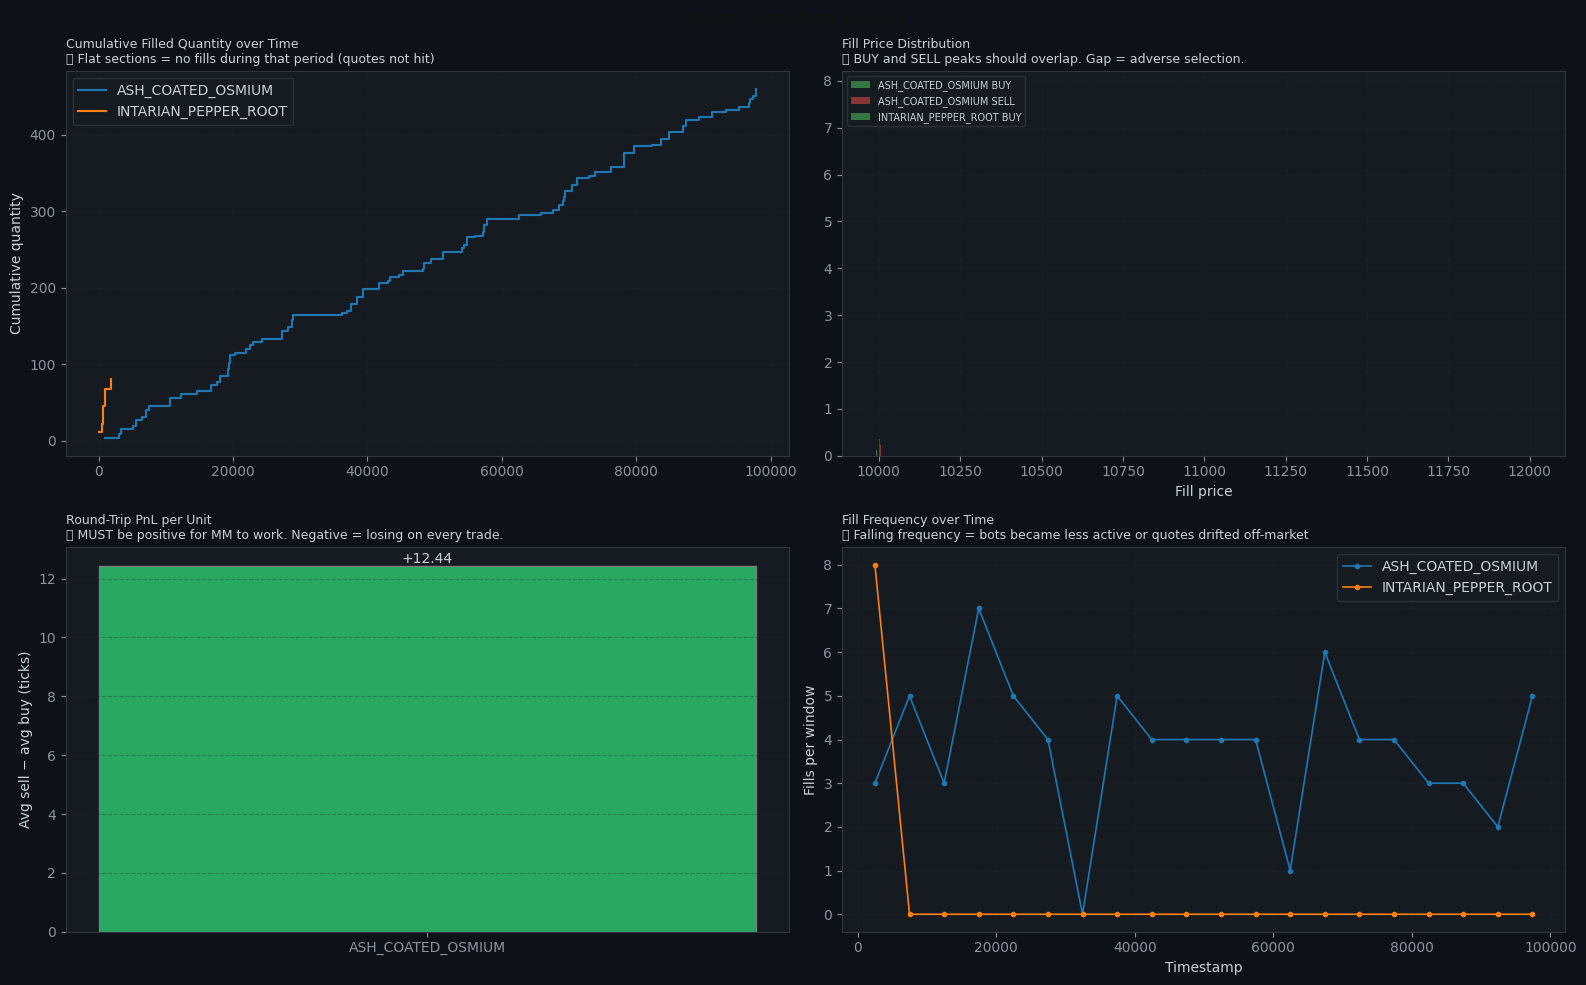

In [112]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Order Execution Details', fontsize=12, fontweight='bold', color='#111')

if not our_trades.empty:

    # ── Cumulative fills over time ─────────────────────────────────────────
    ax1 = axes[0, 0]
    for p in products:
        pts  = our_trades[our_trades['symbol']==p].sort_values('timestamp')
        if pts.empty:
            continue
        pts['cum_qty'] = pts['quantity'].cumsum()
        ax1.step(pts['timestamp'], pts['cum_qty'], where='post', lw=1.5, label=p)
    ax1.set_title('Cumulative Filled Quantity over Time\n'
                  '🔍 Flat sections = no fills during that period (quotes not hit)',
                  fontsize=9, loc='left')
    ax1.legend()
    ax1.set_ylabel('Cumulative quantity')
    ax1.grid(True, alpha=0.3)

    # ── Fill price distribution with round-trip analysis ──────────────────
    ax2 = axes[0, 1]
    for p in products:
        pts  = our_trades[our_trades['symbol']==p]
        buys = pts[pts['side']=='BUY']
        sells= pts[pts['side']=='SELL']
        if not buys.empty:
            ax2.hist(buys['price'],  bins=25, alpha=0.5, label=f'{p} BUY',
                     color=C['trade_buy'],  density=True)
        if not sells.empty:
            ax2.hist(sells['price'], bins=25, alpha=0.5, label=f'{p} SELL',
                     color=C['trade_sell'], density=True)
    ax2.set_title('Fill Price Distribution\n'
                  '🔍 BUY and SELL peaks should overlap. Gap = adverse selection.',
                  fontsize=9, loc='left')
    ax2.legend(fontsize=7)
    ax2.set_xlabel('Fill price')
    ax2.grid(True, alpha=0.3)

    # ── Round-trip PnL per product ─────────────────────────────────────────
    ax3 = axes[1, 0]
    rt_data = {}
    print('\n═══ Round-Trip Analysis ═══')
    for p in products:
        pts  = our_trades[our_trades['symbol']==p]
        buys = pts[pts['side']=='BUY']
        sells= pts[pts['side']=='SELL']
        if buys.empty or sells.empty:
            continue
        avg_buy  = (buys['price']  * buys['quantity'] ).sum() / buys['quantity'].sum()
        avg_sell = (sells['price'] * sells['quantity']).sum() / sells['quantity'].sum()
        rt_pnl   = avg_sell - avg_buy
        rt_vol   = min(buys['quantity'].sum(), sells['quantity'].sum())
        rt_total = rt_pnl * rt_vol
        rt_data[p] = {'avg_buy': avg_buy, 'avg_sell': avg_sell,
                       'rt_pnl': rt_pnl, 'rt_vol': rt_vol, 'rt_total': rt_total}
        print(f'\n{p}:')
        print(f'  Avg buy  price : {avg_buy:.4f}')
        print(f'  Avg sell price : {avg_sell:.4f}')
        print(f'  Round-trip PnL / unit : {rt_pnl:+.4f}')
        print(f'  Matched volume        : {rt_vol:.0f} units')
        print(f'  Total round-trip PnL  : {rt_total:+.2f}')
        if rt_pnl > 0:
            print(f'  ✅ Positive round-trip: strategy is capturing spread correctly')
        elif rt_pnl > -1:
            print(f'  ⚠  Near-zero round-trip: barely covering adverse selection')
        else:
            print(f'  ❌ Negative round-trip: you are losing on every round trip!')
            print(f'     Fix: widen passive edge by at least {abs(rt_pnl):.0f} ticks')

    if rt_data:
        prods_rt  = list(rt_data.keys())
        rt_vals   = [rt_data[p]['rt_pnl'] for p in prods_rt]
        bar_col   = ['#2ecc71' if v > 0 else '#e74c3c' for v in rt_vals]
        bars = ax3.bar(prods_rt, rt_vals, color=bar_col, alpha=0.8, edgecolor='#888')
        for bar, val in zip(bars, rt_vals):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f'{val:+.2f}', ha='center',
                     va='bottom' if val > 0 else 'top', fontsize=10)
        ax3.axhline(0, color='#888', lw=0.6, linestyle='--')
        ax3.set_title('Round-Trip PnL per Unit\n'
                      '🔍 MUST be positive for MM to work. Negative = losing on every trade.',
                      fontsize=9, loc='left')
        ax3.set_ylabel('Avg sell − avg buy (ticks)')
        ax3.grid(True, axis='y', alpha=0.3)

    # ── Fill frequency (fills per 1000 ticks) ─────────────────────────────
    ax4 = axes[1, 1]
    all_ts  = market['timestamp'].unique()
    bin_w   = max(all_ts) // 20
    bins_ts = np.arange(min(all_ts), max(all_ts) + bin_w, bin_w)
    for p in products:
        pts  = our_trades[our_trades['symbol']==p]
        if pts.empty:
            continue
        counts, edges = np.histogram(pts['timestamp'], bins=bins_ts)
        centers       = (edges[:-1] + edges[1:]) / 2
        ax4.plot(centers, counts, lw=1.2, marker='o', markersize=3, label=p)
    ax4.set_title('Fill Frequency over Time\n'
                  '🔍 Falling frequency = bots became less active or quotes drifted off-market',
                  fontsize=9, loc='left')
    ax4.legend()
    ax4.set_xlabel('Timestamp')
    ax4.set_ylabel('Fills per window')
    ax4.grid(True, alpha=0.3)

else:
    for ax in axes.flat:
        ax.text(0.5, 0.5, 'No trade history', ha='center', va='center',
                transform=ax.transAxes)

plt.tight_layout()
plt.show()

## Improvement Roadmap from All Metrics Combined


This cell synthesises all metrics into a prioritised action list.
Rather than giving vague advice, each action is tied to a specific metric
threshold and comes with exact code changes for trader_v4.

How to avoid overfitting:
  - DO tune: passive_edge (affects fill rate), EMA alpha (affects FV quality)
  - DO NOT tune: specific price levels, exact timestamps, run-specific patterns
  - TEST changes on multiple submissions before committing
  - If a change adds <5% PnL improvement, it may be noise

In [113]:

print('═══════════════════════════════════════════════════════════════════')
print('  IMPROVEMENT ROADMAP — Prioritised by Metric Impact')
print('═══════════════════════════════════════════════════════════════════')

m = METRICS
issues = []

# Check recovery ratio
if m['recovery_ratio'] < 5:
    issues.append((1, 'Low recovery ratio', m['recovery_ratio'],
                   'Add vol-gating: when rolling_vol > threshold, halve quote_size and double passive_edge'))

# Check per-product PnL
for p, pm in m['per_product'].items():
    if pm['pnl'] < 0:
        issues.append((1, f'{p} losing money', pm['pnl'],
                       f'Temporarily set {p}_QUOTE_SIZE=0 to disable it, fix FV logic'))
    if pm['recovery'] < 2:
        issues.append((2, f'{p} poor recovery', pm['recovery'],
                       f'Increase SKEW_FACTOR for {p} or add per-product drawdown circuit-breaker'))

# Check fill rate
for p in products:
    bid_col = f'{p}_bid'
    if bid_col in mkt[p].columns:
        filled_ts = set(our_trades[our_trades['symbol']==p]['timestamp']) if not our_trades.empty else set()
        df2 = mkt[p].dropna(subset=[bid_col])
        fill_rate = len([t for t in df2['timestamp'] if t in filled_ts]) / (len(df2)+1e-9)
        if fill_rate < 0.05:
            issues.append((1, f'{p} very low fill rate ({100*fill_rate:.1f}%)', fill_rate,
                           f'Reduce {p.upper()}_PASSIVE_EDGE by 1-2 ticks to get closer to market'))
        elif fill_rate > 0.5:
            issues.append((3, f'{p} very high fill rate ({100*fill_rate:.1f}%)', fill_rate,
                           f'May be over-trading. Increase {p.upper()}_PASSIVE_EDGE by 1 tick for more edge per fill'))

# Check avg fill size
if m['avg_fill'] < 3:
    issues.append((3, f'Small avg fill ({m["avg_fill"]:.1f})', m['avg_fill'],
                   'Increase QUOTE_SIZE or reduce aggressive max_per_level floor'))

# Check round-trip
if not our_trades.empty:
    for p in products:
        pts   = our_trades[our_trades['symbol']==p]
        buys  = pts[pts['side']=='BUY']
        sells = pts[pts['side']=='SELL']
        if not buys.empty and not sells.empty and buys['quantity'].sum()>0 and sells['quantity'].sum()>0:
            ab = (buys['price']*buys['quantity']).sum() / buys['quantity'].sum()
            asl= (sells['price']*sells['quantity']).sum() / sells['quantity'].sum()
            rt = asl - ab
            if rt < 0:
                issues.append((1, f'{p} negative round-trip ({rt:+.2f})', rt,
                               f'Increase {p.upper()}_PASSIVE_EDGE by {int(abs(rt))+1} ticks minimum'))

# Sort by priority and print
issues.sort(key=lambda x: x[0])
priority_labels = {1: '🔴 CRITICAL', 2: '🟡 IMPORTANT', 3: '🔵 NICE TO HAVE'}
print()
for prio, name, val, fix in issues:
    print(f'{priority_labels[prio]}  {name}')
    print(f'   Metric value : {val:.3f}')
    print(f'   Suggested fix: {fix}')
    print()

if not issues:
    print('✅ All metrics look healthy! Focus on:')
    print('   1. Adding microprice signal to quote skew')
    print('   2. Using market pressure for dynamic inventory adjustment')
    print('   3. Testing across multiple round simulations to check robustness')

print('═══════════════════════════════════════════════════════════════════')
print('\nDO NOT overfit: validate any change on at least 3 separate submissions')
print('before keeping it. If improvement < 5%, it may be noise.')

═══════════════════════════════════════════════════════════════════
  IMPROVEMENT ROADMAP — Prioritised by Metric Impact
═══════════════════════════════════════════════════════════════════

🔴 CRITICAL  ASH_COATED_OSMIUM very low fill rate (0.0%)
   Metric value : 0.000
   Suggested fix: Reduce ASH_COATED_OSMIUM_PASSIVE_EDGE by 1-2 ticks to get closer to market

🔴 CRITICAL  INTARIAN_PEPPER_ROOT very low fill rate (0.0%)
   Metric value : 0.000
   Suggested fix: Reduce INTARIAN_PEPPER_ROOT_PASSIVE_EDGE by 1-2 ticks to get closer to market

═══════════════════════════════════════════════════════════════════

DO NOT overfit: validate any change on at least 3 separate submissions
before keeping it. If improvement < 5%, it may be noise.
